# PT SJR DATA ANALYSIS

## 📂 Load Data & Initial Setup 

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pandas import Timestamp
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.utils import resample

In [3]:
# --- Load first data file for 2024 ---
file_2024_path = "PTSJ_data.xlsx"

# Load the multi-row header from B2:AU4 (rows 1-3)
header_df = pd.read_excel(file_2024_path, header=None, skiprows=1, nrows=3, usecols="B:AV")

# Load the actual data (B5:BD39 → skiprows=4, nrows=35)
df_2024 = pd.read_excel(file_2024_path, header=None, skiprows=4, nrows=35, usecols="B:AV")

# Load the Date column separately from B5:B39
date_series = pd.read_excel(file_2024_path, header=None, skiprows=4, nrows=35, usecols="B")

# Flatten the headers
def flatten_header(row1, row2, row3):
	def clean(x): return str(x).strip().replace(" ", "_").replace("#", "mesh") if pd.notna(x) else ""
	return "_".join([clean(row1), clean(row2), clean(row3)]).strip("_")

flattened_cols = [
	flatten_header(r1, r2, r3)
	for r1, r2, r3 in zip(header_df.iloc[0], header_df.iloc[1], header_df.iloc[2])
]

# Assign headers and attach Date column
df_2024.columns = flattened_cols
if "Date" not in df_2024.columns:
	df_2024.insert(0, "Date", pd.to_datetime(date_series.iloc[:, 0]))

# --- Load second data file for 2025 ---
file_2025_path = "ptsj_2025_data.xlsx"

jan_2025 = pd.read_excel(file_2025_path, sheet_name="Jan 25", header=None, skiprows=9)
feb_2025 = pd.read_excel(file_2025_path, sheet_name="Feb 25", header=None, skiprows=9)
mar_2025 = pd.read_excel(file_2025_path, sheet_name="Mar 25", header=None, skiprows=9)
apr_2025 = pd.read_excel(file_2025_path, sheet_name="April 25", header=None, skiprows=9)
grade_2025 = pd.read_excel(file_2025_path, sheet_name="Grade", header=None, skiprows=6)

## ⚙️ Define Constants & User Parameters

In [ ]:
palette = "tab10"
secondary_palette = "tab10"
colors = sns.color_palette(palette)
colors_sec = sns.color_palette(secondary_palette)
plot_theme = "whitegrid"

solid_density = 2.53            # Density of solids in slurry (g/cm³)
liquid_density = 1.15           # Density of liquid in slurry (g/cm³)
percent_solids_avg = 0.3391         # Solids in slurry (2024 avg. 33.91%)

# Switch for 2024 Throughput value
tp_2024 = True      # True assumes the unit is in wet m3 and False assumes it is in dry tonnes

# Leach circuit parameters
leach_tank_count = 2
cil_tank_count = 6
leach_tank_m3 = 1520
cil_tank_m3 = 568
circuit_volume_m3 = (leach_tank_count * leach_tank_m3) + (cil_tank_count * cil_tank_m3)

# Define "stable DO" threshold
stable_threshold = 7.5

figsize = (6.5, 4)

## 🧹 Data Cleansing & Preprocessing

In [5]:
# --- Clean the 2024 dataframe ---
# Rename duplicate columns
def rename_duplicate_columns(cols):
	seen = {}
	new_cols = []
	for col in cols:
		if col not in seen:
			seen[col] = 1
			new_cols.append(col)
		else:
			seen[col] += 1
			new_cols.append(f"{col}_{seen[col]}")
	return new_cols

df_2024.columns = rename_duplicate_columns(df_2024.columns)

# Clean columns names
def clean_column_name(col):
	col = col.replace("%", "pct")
	col = col.replace("\n", "_")
	col = col.replace("(", "_").replace(")", "_")
	col = col.replace("_gram_", "_g_")
	col = col.replace("<", "").replace(">", "")
	col = col.replace("+", "plus").replace("-", "minus")
	col = re.sub(r"_+$", "", col)  # Remove trailing underscores
	col = col.replace(".", "_")
	col = col.replace("___", "_")
	col = col.replace("__", "_")  # Replace double underscores with single
	col = col.replace("Weight_Retained_Percentage_pct", "Weight_Retained_pct")
	return col.strip()

# Apply the cleaning function to all column names
df_2024.columns = [clean_column_name(col) for col in df_2024.columns]

# Calculate Slurry Volume in m³
if tp_2024 == True:
	df_2024["Slurry_Volume_m3"] = df_2024["Throughput"]
else:
	df_2024["Slurry_Volume_m3"] = df_2024["Throughput"] * (
		(df_2024["PercentSolids"] / 100 / (solid_density * 1000)) + 
		((1- df_2024["PercentSolids"] / 100) / (liquid_density * 1000))
	) * 1000

# Calculate residence time in hours
df_2024["Residence_Time_hr"] = circuit_volume_m3 / df_2024["Slurry_Volume_m3"] * 24

print(f"2024 DataFrame shape: {df_2024.shape}")

# --- Clean 2025 data ---
# Manual column mapping
col_names = {
	3: "Date", 4: "Time", 5: "Date Time",
	6: "Pre_Leach_Density_pct_w_w", 7: "Leach_Tank_01_Density_pct_w_w",
	8: "Leach_Tank_01_pH", 9: "Leach_Tank_01_CN_ppm", 10: "Leach_Tank_01_DO_ppm",
	11: "Leach_Tank_02_Density_pct_w_w", 12: "Leach_Tank_02_pH", 13: "Leach_Tank_02_CN_ppm", 14: "Leach_Tank_02_DO_ppm",
	15: "CIL_Tank_01_Density_pct_w_w", 16: "CIL_Tank_01_pH", 17: "CIL_Tank_01_CN_ppm", 18: "CIL_Tank_01_DO_ppm", 19: "CIL_Tank_01_Carbon_gpl",
	20: "CIL_Tank_02_Density_pct_w_w", 21: "CIL_Tank_02_pH", 22: "CIL_Tank_02_CN_ppm", 23: "CIL_Tank_02_DO_ppm", 24: "CIL_Tank_02_Carbon_gpl",
	25: "CIL_Tank_03_Density_pct_w_w", 26: "CIL_Tank_03_pH", 27: "CIL_Tank_03_CN_ppm", 28: "CIL_Tank_03_DO_ppm", 29: "CIL_Tank_03_Carbon_gpl",
	30: "CIL_Tank_04_Density_pct_w_w", 31: "CIL_Tank_04_pH", 32: "CIL_Tank_04_CN_ppm", 33: "CIL_Tank_04_DO_ppm", 34: "CIL_Tank_04_Carbon_gpl",
	35: "CIL_Tank_05_Density_pct_w_w", 36: "CIL_Tank_05_pH", 37: "CIL_Tank_05_CN_ppm", 38: "CIL_Tank_05_DO_ppm", 39: "CIL_Tank_05_Carbon_gpl",
	40: "CIL_Tank_06_Density_pct_w_w", 41: "CIL_Tank_06_pH", 42: "CIL_Tank_06_CN_ppm", 43: "CIL_Tank_06_DO_ppm", 44: "CIL_Tank_06_Carbon_gpl",
	45: "Tailing_Density_pct_w_w", 46: "Tailing_CN_ppm", 47: "DO_Purity_pct_w_w", 48: "DO_Flow",
}

# Clean each month's data and reassign cleaned versions
month_names = ["jan_2025", "feb_2025", "mar_2025", "apr_2025"]
df_2025_list = [jan_2025, feb_2025, mar_2025, apr_2025]
cleaned_list = []

for month_data in df_2025_list:
	# Rename columns
	month_data.rename(columns=col_names, inplace=True)

	# Select relevant columns (Date, Time, Date Time, and process data columns)
	month_data = month_data.iloc[:, 3:49]
	
	# Select relevant columns and reset index
	month_data = month_data.iloc[6:].reset_index(drop=True)
	
	# Ensure 'Date' column is in datetime format
	month_data['Date'] = pd.to_datetime(month_data['Date'], errors='coerce')

	cleaned_list.append(month_data)

# Reassign to original variable names
jan_2025, feb_2025, mar_2025, apr_2025 = cleaned_list

# Define month ranges and apply filtering
month_ranges = {
	"jan_2025": ("2025-01-01", "2025-01-31"),
	"feb_2025": ("2025-02-01", "2025-02-28"),
	"mar_2025": ("2025-03-01", "2025-03-31"),
	"apr_2025": ("2025-04-01", "2025-04-30"),
}

for name, (start, end) in month_ranges.items():
	df = locals()[name]
	df = df[(df["Date"] >= Timestamp(start)) & (df["Date"] <= Timestamp(end))]
	locals()[name] = df  # assign the filtered df back


# Display dataframe shapes for each month
print(f"January 2025 DataFrame shape: {jan_2025.shape}")
print(f"February 2025 DataFrame shape: {feb_2025.shape}")
print(f"March 2025 DataFrame shape: {mar_2025.shape}")
print(f"April 2025 DataFrame shape: {apr_2025.shape}")

# Combine the monthly data into a single DataFrame
df_2025 = pd.concat([jan_2025, feb_2025, mar_2025, apr_2025], ignore_index=True)

# Print the final shape of the 2025 DataFrame
print(f"Final 2025 DataFrame shape: {df_2025.shape}")

# --- Clean 2025 Grade data ---
# Assign manual column names to known first 14 columns based on inspection
manual_columns = [
	"Ignore",
	"Date",
	"Feed_Ton_Dry",
	"Feed_Grade_Au_ppm",
	"Feed_Grade_Ag_ppm",
	"Feed_Grade_Cu_ppm",
	"Tail_Ton_Dry",
	"Tail_Solution_Volume_m3",
	"Tail_Solid_Au_ppm",
	"Tail_Solid_Ag_ppm",
	"Tail_Solid_Cu_ppm",
	"Tail_Solution_Au_ppm",
	"Tail_Solution_Ag_ppm",
	"Tail_Solution_Cu_ppm"
]

# Apply to first 14 columns only
grade_2025 = grade_2025.iloc[:, :14]
grade_2025.columns = manual_columns

grade_2025["Slurry_Volume_m3"] = grade_2025["Feed_Ton_Dry"] * (
	(percent_solids_avg / (solid_density * 1000)) + 
	((1- percent_solids_avg) / (liquid_density * 1000))
	) * 1000

# Drop rows where 'Feed_Ton_Dry' is NaN or zero
grade_2025 = grade_2025.dropna(subset=["Feed_Ton_Dry"])
grade_2025 = grade_2025[grade_2025["Feed_Ton_Dry"] > 0]

grade_2025["Residence_Time_hr"] = circuit_volume_m3 / grade_2025["Slurry_Volume_m3"]

# Drop 'Ignore' column and rows without date
grade_2025 = grade_2025.drop(columns=["Ignore"]).dropna(subset=["Date"]).copy()
grade_2025["Date"] = pd.to_datetime(grade_2025["Date"], errors="coerce")

# Convert numeric columns
for col in grade_2025.columns:
	if col != "Date":
		grade_2025[col] = pd.to_numeric(grade_2025[col], errors="coerce")

# Preview final cleaned Grade sheet
print(f"Grade 2025 DataFrame shape: {grade_2025.shape}")

# Calculate gold input in grams
grade_2025["Au_Input_g"] = grade_2025["Feed_Ton_Dry"] * grade_2025["Feed_Grade_Au_ppm"]

# Calculate gold loss to tailings (solids only, in grams)
grade_2025["Au_Tail_g"] = grade_2025["Tail_Ton_Dry"] * grade_2025["Tail_Solid_Au_ppm"]

# Calculate recovery (%)
grade_2025["Recovery_pct"] = 100 * (1 - grade_2025["Au_Tail_g"] / grade_2025["Au_Input_g"])

# --- Prepare your merged DataFrame ---
# Group Final 2025 by date and take the mean for numeric fields and first for non-numeric fields
df_2025_daily = df_2025.groupby("Date", as_index=False).agg(
	lambda x: x.mean() if pd.api.types.is_numeric_dtype(x) else x.iloc[0])

# Merge on Date (inner to keep matching dates only)
merged_2025 = pd.merge(df_2025_daily, grade_2025, on="Date", how="inner")

# Convert key columns to numeric
merged_2025["Leach_Tank_01_CN_ppm"] = pd.to_numeric(merged_2025["Leach_Tank_01_CN_ppm"], errors="coerce")
merged_2025["Leach_Tank_01_DO_ppm"] = pd.to_numeric(merged_2025["Leach_Tank_01_DO_ppm"], errors="coerce")
merged_2025["Recovery_pct"] = pd.to_numeric(merged_2025["Recovery_pct"], errors="coerce")
merged_2025["Feed_Ton_Dry"] = pd.to_numeric(merged_2025["Feed_Ton_Dry"], errors="coerce")

# Derive CN added and CN in tailings (kg), and efficiency metrics
merged_2025["NaCN_Added_Est_kg"] = merged_2025["Leach_Tank_01_CN_ppm"] * merged_2025["Feed_Ton_Dry"] * 1e3 / 1e6

# Drop nan and - from Tailing_CN_ppm
merged_2025["Tailing_CN_ppm"] = merged_2025["Tailing_CN_ppm"].astype(str).replace("-", np.nan)
merged_2025["Tailing_CN_ppm"] = pd.to_numeric(merged_2025["Tailing_CN_ppm"], errors="coerce")
merged_2025["Tailing_CN_ppm"] = merged_2025["Tailing_CN_ppm"].replace(0, np.nan)
merged_2025 = merged_2025.dropna(subset=["Tailing_CN_ppm"])

# Display unique values in Tailing_CN_ppm after cleaning
df_2025.dropna(subset=["Tailing_CN_ppm"], inplace=True)

# Drop rows with zero or NaN Tailing_CN_ppm
merged_2025["NaCN_in_Tails_Est_kg"] = merged_2025["Tailing_CN_ppm"] * merged_2025["Tail_Solution_Volume_m3"] / 1000
merged_2025["NaCN_Loss_pct"] = 100 * merged_2025["NaCN_in_Tails_Est_kg"] / merged_2025["NaCN_Added_Est_kg"]
merged_2025["NaCN_Utilisation_pct"] = 100 - merged_2025["NaCN_Loss_pct"]

merged_2025["NaCN_Difference_ppm"] = merged_2025["Leach_Tank_01_CN_ppm"] - merged_2025["Tailing_CN_ppm"]
merged_2025["NaCN_Difference_kg"] = merged_2025["NaCN_Added_Est_kg"] - merged_2025["NaCN_in_Tails_Est_kg"]

print(f"Merged 2025 DataFrame shape: {merged_2025.shape}")


2024 DataFrame shape: (35, 49)
January 2025 DataFrame shape: (372, 46)
February 2025 DataFrame shape: (336, 46)
March 2025 DataFrame shape: (372, 46)
April 2025 DataFrame shape: (360, 46)
Final 2025 DataFrame shape: (1440, 46)
Grade 2025 DataFrame shape: (106, 15)
Merged 2025 DataFrame shape: (90, 69)


In [6]:
df_2024.to_csv("df_2024.csv", index=False)
df_2025.to_csv("df_2025.csv", index=False)
grade_2025.to_csv("grade_2025.csv", index=False)
merged_2025.to_csv("merged_2025.csv", index=False)

## 📊 Define Plotting Helpers

In [87]:
# --- Basic bar helper ---
def plot_bar(data, title, xlabel=None, ylabel=None, x_col=None, y_col=None, figsize=figsize,
			 color=colors[0], series=False, theme=plot_theme, palette=palette,
			 rotation=45, edge_color="black", horizontal=False, alpha=1.0):
	plt.figure(figsize=figsize)
	sns.set_theme(style=theme, palette=palette)
	if series:
		data.plot(kind='bar',color=color, edgecolor=edge_color,
			figsize=figsize, legend=False, alpha=alpha)
	else:
		sns.barplot(data=data, x=x_col, y=y_col, color=color, alpha=alpha,
			   orient='h' if horizontal else 'v')
	plt.title(title)
	plt.xlabel(xlabel, fontsize=10)
	plt.ylabel(ylabel, fontsize=10)
	if horizontal:
		plt.xticks(rotation=rotation)
	else:
		plt.xticks(rotation=rotation)
	plt.grid(False)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	plt.tight_layout()
	plt.show()


# --- Basic scatter helper ---
def plot_scatter(data, x_col, y_col, title, xlabel, ylabel, figsize=figsize, color=colors[0],
				 reg=False, theme=plot_theme, palette=palette, alpha=0.7, vertical_line=None):
	plt.figure(figsize=figsize)
	sns.set_theme(style=theme, palette=palette)
	sns.scatterplot(data=data, x=x_col, y=y_col, color=color)
	if reg:
		sns.regplot(data=data, x=x_col, y=y_col, scatter=False, color=color,
					line_kws={"linestyle": "--"})
	if vertical_line is not None:
		plt.axvline(x=vertical_line, color='red', linestyle='--', label='Vertical Line')
	plt.title(title)
	plt.xlabel(xlabel, fontsize=10)
	plt.ylabel(ylabel, fontsize=10)
	plt.grid(False)
	plt.tight_layout()
	plt.show()


# --- Scatter with regression line helper ---
def plot_scatter_with_regression(data, x_col, y_col, xlabel, ylabel, title=None, figsize=figsize,
								 color=colors[0], reg_color="red", order=1, ci=95, n_boot=1000,
								 ylim=None,
								 theme=plot_theme, palette=palette):
	plt.figure(figsize=figsize)
	sns.set_theme(style=theme, palette=palette)
	ax = plt.gca()

	sns.scatterplot(data=data, x=x_col, y=y_col, color=color)

	if pd.api.types.is_datetime64_any_dtype(data[x_col]):
		# --- Convert dates to numeric ---
		x_dates = mdates.date2num(data[x_col])
		y_vals = data[y_col].values
		mask = ~np.isnan(x_dates) & ~np.isnan(y_vals)
		x = x_dates[mask].reshape(-1, 1)
		y = y_vals[mask]

		# --- Polynomial Fit ---
		poly = PolynomialFeatures(order)
		x_poly = poly.fit_transform(x)
		model = LinearRegression().fit(x_poly, y)
		x_fit = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
		x_fit_poly = poly.transform(x_fit)
		y_fit = model.predict(x_fit_poly)

		# --- Confidence Interval via Bootstrap ---
		y_bootstrap = []
		for _ in range(n_boot):
			x_resample, y_resample = resample(x, y)
			x_poly_resample = poly.fit_transform(x_resample)
			model_boot = LinearRegression().fit(x_poly_resample, y_resample)
			y_bootstrap.append(model_boot.predict(x_fit_poly))

		y_bootstrap = np.array(y_bootstrap)
		lower = np.percentile(y_bootstrap, (100 - ci) / 2, axis=0)
		upper = np.percentile(y_bootstrap, 100 - (100 - ci) / 2, axis=0)

		# --- Plot regression line and confidence band ---
		ax.plot(mdates.num2date(x_fit.flatten()), y_fit, linestyle="--", color=reg_color)
		ax.fill_between(mdates.num2date(x_fit.flatten()), lower, upper, color=reg_color, alpha=0.2)
	else:
		# Use Seaborn for numeric x-axis
		sns.regplot(data=data, x=x_col, y=y_col, scatter=False, color=reg_color,
					line_kws={"linestyle": "--"}, order=order, ci=ci)

	if title:
		plt.title(title)
		
	plt.xlabel(xlabel, fontsize=10)
	plt.ylabel(ylabel, fontsize=10)
	
	if ylim:
		plt.ylim(ylim)

	if "Date" in x_col:
		ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
		plt.xticks(rotation=45)

	plt.grid(False)
	plt.tight_layout()
	plt.show()


# --- Line trend helper with cleaned numeric values ---
def plot_line_trend(df, y, yLabel, title="2025", figsize=figsize,
					theme=plot_theme, palette=palette, color=colors[0]):

	# Ensure col is in numeric format
	df[y] = pd.to_numeric(df[y], errors="coerce")

	if y not in df.columns:
		print(f"Column '{y}' not found.")
		return

	# Plot
	plt.figure(figsize=figsize)
	sns.set_theme(style=theme, palette=palette)
	ax = sns.lineplot(data=df.dropna(subset=[y]), x="Date", y=y, color=color)
	ax.spines["top"].set_visible(False)
	ax.spines["right"].set_visible(False)
	ax.set_title(title)
	ax.set_xlabel("Date")
	ax.set_ylabel(yLabel)
	
	# Better x-axis formatting
	ax.xaxis.set_major_locator(mdates.AutoDateLocator())
	ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
	plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
	plt.grid(False)
	plt.tight_layout()
	plt.show()


# --- Line plot with standard deviation band helper ---
def plot_line_with_std_band(df, x_col, y_col, title, xlabel, ylabel,
							color=colors[2], alpha=0.2,
							show_ref_line=True, ref_line_val=0, ref_line_color="red",
							ref_line_label="Reference", std_label="±1 Std Dev",
							figsize=figsize, theme=plot_theme, palette=palette):

	plt.figure(figsize=figsize)
	sns.set_theme(style=theme, palette=palette)

	ax = sns.lineplot(data=df, x=x_col, y=y_col, color=color, label=y_col)

	# ±1 standard deviation band
	std_dev = df[y_col].std()
	plt.fill_between(df[x_col],
					 df[y_col] - std_dev,
					 df[y_col] + std_dev,
					 color=color, alpha=alpha, label=std_label)

	# Optional reference line
	if show_ref_line:
		plt.axhline(ref_line_val, color=ref_line_color, linestyle='--', label=ref_line_label)

	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.xticks(rotation=45)
	plt.legend()
	plt.grid(False)
	plt.tight_layout()
	plt.show()



# --- Dual line plot helper ---
def plot_dual_lines(df1, df2, x_col, y_col1, y_col2, label1, label2,
					title="Dual Line Plot", xlabel="Date", ylabel="Value",
					color_1=colors[0], color_2=colors[1],
					figsize=figsize, theme=None, sec_axis=False):
	plt.figure(figsize=figsize)

	ax1 = plt.gca()
	line1 = sns.lineplot(data=df1, x=x_col, y=y_col1, ax=ax1, color=color_1)
	line1_line = line1.lines[0]

	if sec_axis:
		ax2 = ax1.twinx()
		line2 = sns.lineplot(data=df2, x=x_col, y=y_col2, ax=ax2, color=color_2)
		ax2.set_ylabel(f"{label2} ({ylabel})")
		line2_line = line2.lines[0]
	else:
		ax2 = ax1  # reuse ax1
		line2 = sns.lineplot(data=df2, x=x_col, y=y_col2, ax=ax1, color=color_2)
		line2_line = line2.lines[1]  # index 1 since it's the second line on the same axis

	ax1.set_title(title)
	ax1.set_xlabel(xlabel)
	ax1.set_ylabel(f"{label1} ({ylabel})")

	for ax in set([ax1, ax2]):  # avoid redundant styling if same axis
		ax.grid(False)
		ax.spines['top'].set_visible(False)
		ax.spines['right'].set_visible(False)

	ax1.tick_params(axis='x', rotation=45)

	ax1.legend(
		[line1_line, line2_line],
		[label1, label2],
		loc='upper left'
	)

	plt.tight_layout()
	plt.show()



# --- Time series panel plot helper ---
def plot_time_series_panels(
	panels,
	suptitle=None,
	sharex=True,
	figsize=(14, 10),
	date_format="%b %d",
	rotate_xticks=45,
	date_interval=1
):
	"""
	Plots multiple time series subplots stacked vertically.

	Parameters:
	- panels (list of dict): Each dict defines a subplot, with:
		{
			"title": str,
			"ylabel": str,
			"lines": [
				{
					"data": pd.DataFrame,
					"x": str,
					"y": str,
					"label": str,
					"color": str,
					"linestyle": str (optional),
					"linewidth": float (optional)
				},
				...
			]
		}
	- suptitle (str): Overall title for the figure.
	- sharex (bool): Whether subplots share the same x-axis.
	- figsize (tuple): Size of the figure.
	- date_format (str): Format for x-axis date labels.
	- rotate_xticks (int): Degrees to rotate x-tick labels.
	- date_interval (int): Interval in weeks for x-tick labels.
	"""
	n_panels = len(panels)
	fig, axs = plt.subplots(n_panels, 1, figsize=figsize, sharex=sharex)
	axs = axs if isinstance(axs, (list, np.ndarray)) else [axs]

	for ax, panel in zip(axs, panels):
		for line in panel["lines"]:
			sns.lineplot(
				data=line["data"],
				x=line["x"],
				y=line["y"],
				ax=ax,
				label=line["label"],
				color=line.get("color"),
				linestyle=line.get("linestyle", "-"),
				linewidth=line.get("linewidth", 2),
			)
		
		# Apply ylim if provided
		if "ylim" in panel:
			ax.set_ylim(*panel["ylim"])

		# Add vertical shaded spans
		for span in panel.get("vspans", []):
			# Convert start and end to datetime if not already
			start = pd.to_datetime(span["start"])
			end = pd.to_datetime(span["end"])
			ax.axvspan(start, end, color=span.get("color", "grey"), alpha=span.get("alpha", 0.1))

		# Add annotations
		for ann in panel.get("annotations", []):
			ax.annotate(
				ann["text"],
				xy=(ann["x"], ann["y"]),
				xytext=ann.get("xytext", (0, 10)),
				textcoords="offset points",
				arrowprops=dict(arrowstyle="->", lw=1),
				fontsize=ann.get("fontsize", 10),
				color=ann.get("color", "black")
			)

		ax.spines["top"].set_visible(False)
		ax.spines["right"].set_visible(False)
		ax.set_title(panel["title"])
		ax.set_ylabel(panel["ylabel"])
		ax.legend()
		ax.grid(False)

	# Format x-axis as dates
	for ax in axs:
		ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=date_interval))
		ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
		ax.tick_params(axis="x", rotation=rotate_xticks)

	if suptitle:
		plt.suptitle(suptitle, fontsize=16, y=1.02)
		plt.subplots_adjust(top=0.93)
	plt.tight_layout()
	plt.show()


# --- Histogram helper ---
def plot_histogram(data, column, title, xlabel, ylabel="Frequency", figsize=figsize,
				   color=colors[0], bins=15, theme=plot_theme, palette=palette, kde=False):
	plt.figure(figsize=figsize)
	sns.set_theme(style=theme, palette=palette)
	sns.histplot(data[column], bins=bins, color=color, kde=kde)
	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.grid(False)
	plt.tight_layout()
	plt.show()


# --- Dual histogram helper ---
def plot_dual_histogram(data1, data2, column1, column2, title, xlabel, ylabel, label1, label2,
						figsize=figsize, color1=colors[0], color2=colors[4], theme=plot_theme,
						palette=palette):
	plt.figure(figsize=figsize)
	sns.set_theme(style=theme, palette=palette)
	sns.histplot(data1[column1], bins=15, color=color1, label=label1, kde=True, alpha=0.5)
	sns.histplot(data2[column2], bins=15, color=color2, label=label2, kde=True, alpha=0.5)
	plt.title(title)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.legend()
	plt.grid(False)
	plt.tight_layout()
	plt.show()

# --- Histogram subplot helper ---
def plot_histogram_subplots(data, fields, ncols=2, bins=20, colors=None,
							kde=True, titles=None, xlabels=None, figsize=(14, 6)):
	"""
	Plot histograms with optional KDE for a list of numeric fields.

	Parameters:
	- data (pd.DataFrame): The DataFrame containing the data.
	- fields (list of str): List of column names to plot.
	- ncols (int): Number of subplots per row.
	- bins (int): Number of histogram bins.
	- colors (list of str): List of colours to use for each histogram.
	- kde (bool): Whether to overlay a KDE curve.
	- titles (list of str): Custom titles for each subplot (optional).
	- xlabel_suffix (str): Text to append to x-axis labels.
	- figsize (tuple): Size of the entire figure.
	"""
	n_fields = len(fields)
	nrows = math.ceil(n_fields / ncols)

	fig, axs = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
	axs = axs.flatten()

	for i, field in enumerate(fields):
		color = colors[i] if colors and i < len(colors) else None
		title = titles[i] if titles and i < len(titles) else f"{field} Distribution"
		sns.histplot(data[field].dropna(), bins=bins, kde=kde, color=color, ax=axs[i])
		axs[i].set_title(title)
		if xlabels and i < len(xlabels):
			xlabel = xlabels[i]
		axs[i].set_xlabel(xlabel)
		axs[i].set_ylabel("Frequency")
		axs[i].grid(False)

	# Turn off unused subplots
	for j in range(n_fields, len(axs)):
		fig.delaxes(axs[j])

	plt.tight_layout()
	plt.show()

## Compare fields to Shanta Dataset

In [8]:
# Step 1: Summary of all columns
column_summary = pd.DataFrame({
	"Field": df_2024.columns,
	"Non-null Count": df_2024.notnull().sum().values,
	"Missing Count": df_2024.isnull().sum().values,
	"Data Type": df_2024.dtypes.values
})

# Step 2: Identify columns likely matching key Shanta model fields
shanta_field_groups = {
	"Date": [r"\bdate\b"],
	"Ore Grade": [r"grade", r"\bau\b", r"assay", r"retainedau", r"passingau"],
	"Recovery": [r"recovery", r"recov", r"%recovered"],
	"Tailings": [r"tail", r"gold_loss", r"tailing"],
	"Throughput": [r"tons", r"tph", r"throughput"],
	"Cyanide Dosage": [r"nacn", r"cyanide", r"\bcn\b"],
	"Silver": [r"\bag\b", r"grade_ag"],
	"Particle Size": [r"mesh", r"p80", r"weightretained", r"cum.weight", r"passing"],
	"Solids": [r"percentsolids", r"%solids"]
}

def map_shanta_group(col):
	col_lower = col.lower()
	for group, patterns in shanta_field_groups.items():
		for pattern in patterns:
			if re.search(pattern, col_lower):
				return group
	return "Unclassified"

column_summary["Mapped Group"] = column_summary["Field"].apply(map_shanta_group)
column_summary

,Field,Non-null Count,Missing Count,Data Type,Mapped Group
0,Date,35,0,datetime64[ns],Date
1,Shift,35,0,object,Unclassified
2,Sample,35,0,object,Unclassified
3,Throughput,35,0,float64,Throughput
4,PercentSolids,35,0,float64,Solids
5,Grade_Au,35,0,float64,Ore Grade
6,AU_tailing,35,0,float64,Tailings
7,Grade_Ag,35,0,float64,Ore Grade
8,Grade_Cu,35,0,float64,Ore Grade
9,NaCN_Added,35,0,float64,Cyanide Dosage


#### Key Field Grouping Observations
| Group            | ✅ Notables                                                    |
| ---------------- | ------------------------------------------------------------- |
| `Date`           | ✔ Present and correctly typed                                 |
| `Ore Grade`      | ✔ Includes bulk Au/Ag/Cu grades and sieve-based assays        |
| `Cyanide Dosage` | ✔ `NaCN_Added` captured, plus CN in tails                     |
| `Tailings`       | ✔ CN tailing value present (but not Au in tails — important!) |
| `Throughput`     | ✔ Single field present (`Throughput`)                         |
| `Solids`         | ✔ `%Solids` field is in                                       |
| `Particle Size`  | ✔ Full screen distribution + P80 + %Passing75µm available     |
| `Recovery`       | ❌ **Missing** — no explicit Au recovery or Au in tails        |


## 📊 Exploratory Plots (2024 dataset)
* Plot A: NaCN_Added vs Grade_Au
* Plot B: P80 vs %Passing75µm
* Plot C: Grade_Au vs NaCN_conc_tailing (diagnose over/underdosing)

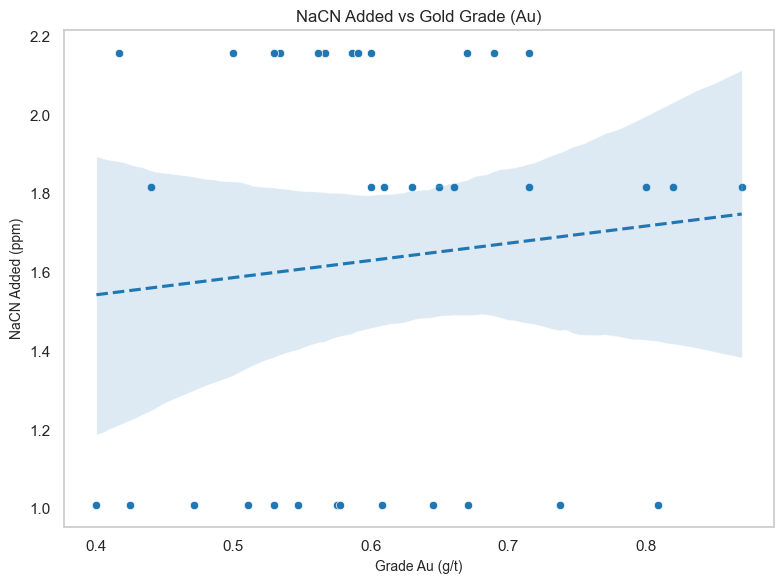

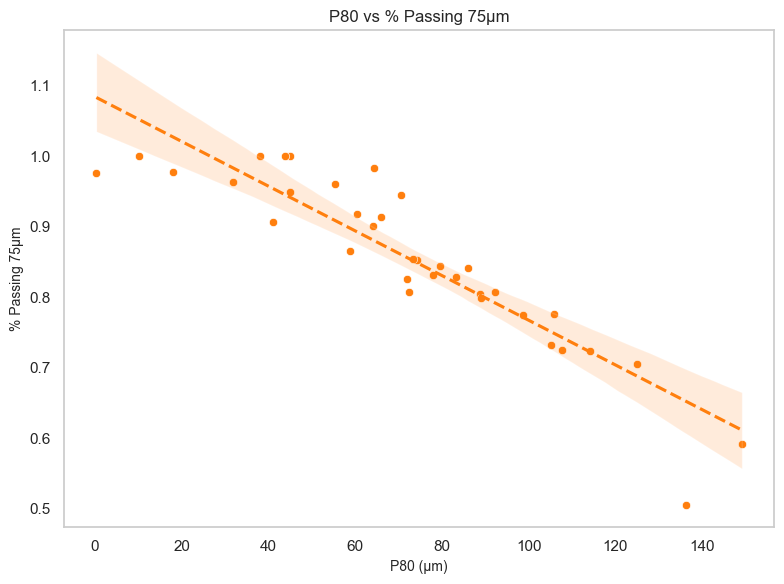

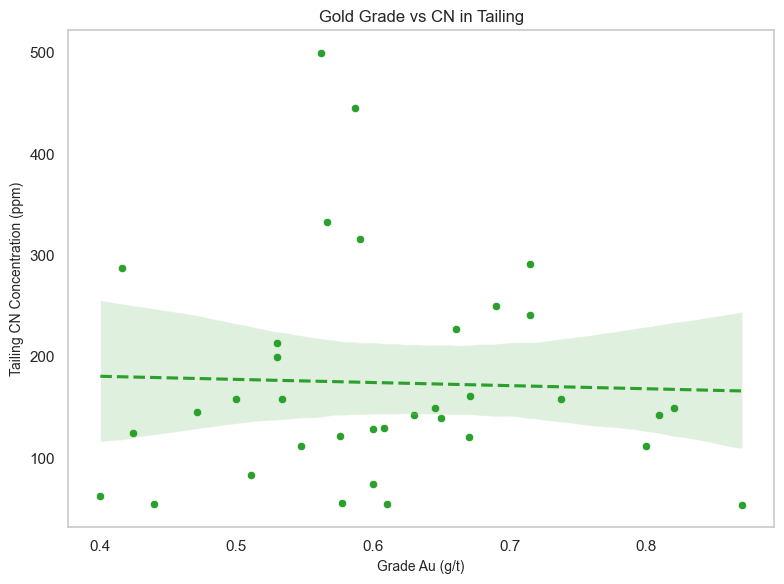

In [9]:
# Ensure datetime is sorted
df_2024 = df_2024.sort_values("Date")

# Set up common plot style
figsize = (8, 6)

# Plot A: NaCN_Added vs Grade_Au
plot_scatter(
	df_2024,
	x_col="Grade_Au",
	y_col="NaCN_Added",
	title="NaCN Added vs Gold Grade (Au)",
	xlabel="Grade Au (g/t)",
	ylabel="NaCN Added (ppm)",
	figsize=figsize,
	color=colors[0],
	reg=True
)
# Plot B: P80 vs %Passing75µm
plot_scatter(
	df_2024,
	x_col="P80_µm",
	y_col="pct_Passing_75µm",
	title="P80 vs % Passing 75µm",
	xlabel="P80 (µm)",
	ylabel="% Passing 75µm",
	figsize=figsize,
	color=colors[1],
	reg=True
)

# Plot C: Grade_Au vs NaCN_conc_tailing
plot_scatter(
	df_2024,
	x_col="Grade_Au",
	y_col="NaCN_conc_tailing",
	title="Gold Grade vs CN in Tailing",
	xlabel="Grade Au (g/t)",
	ylabel="Tailing CN Concentration (ppm)",
	figsize=figsize,
	color=colors[2],
	reg=True
)


#### 🔍 What the plots show:
🟦 NaCN Added vs Grade Au
* Three distinct clusters suggest stepwise dosing rather than continuous control.
* Dose not scaling tightly with grade ⇒ possibly fixed-rate addition or batch-set dosing strategy.

🟨 P80 vs % Passing 75µm
* Clean inverse trend confirms that grind-size measurements are consistent.
* This allows you to confidently use either metric (or both) as proxies for gold liberation.

🟥 Grade Au vs CN in Tailing
* Wide scatter, including high CN in tails at both low and high grades, suggests:
	- Overdosing during some periods (excess reagent not consumed).
	- Potential underperformance in gold dissolution or carbon adsorption.
	- Room for optimisation of cyanide efficiency.


### 🟦 Dataset A: PTSJ_data (2024)
**Focus:** grind size, CN addition, particle-size Au assays
**Limitations:** no recovery or tail Au

Use for:
* CN dosage patterns
* Particle size trends (P80, % passing)
* Liberation vs assay profiling

### 🟩 Dataset B: Grade + Recovery (2025)
**Focus:** Feed grade, tail Au, recovery calculation
**Limitations:** no particle size or CN dosing

Use for:
* Calculated recovery vs feed grade
* Tail loss quantification
* Temporal stability of recovery

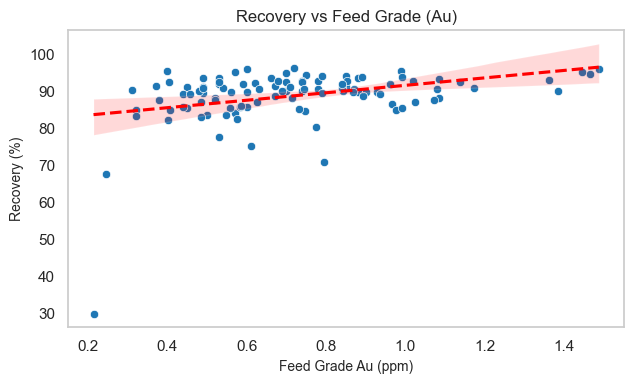

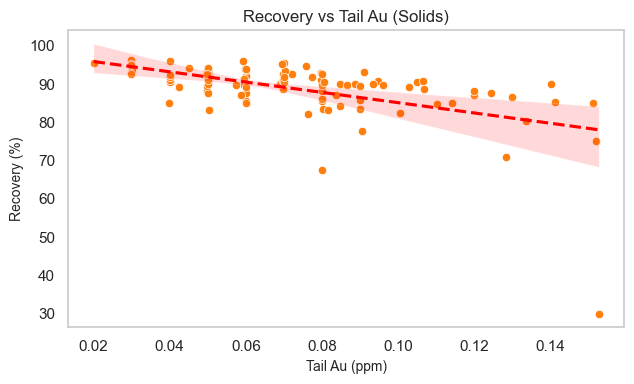

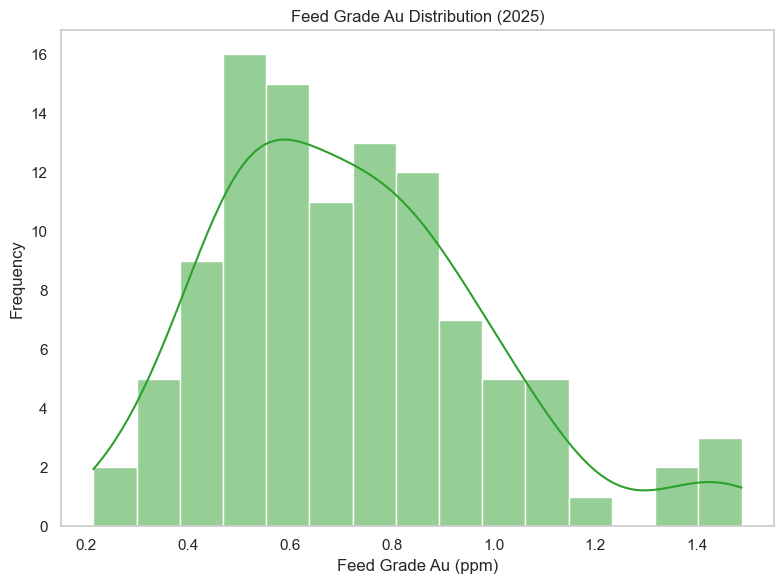

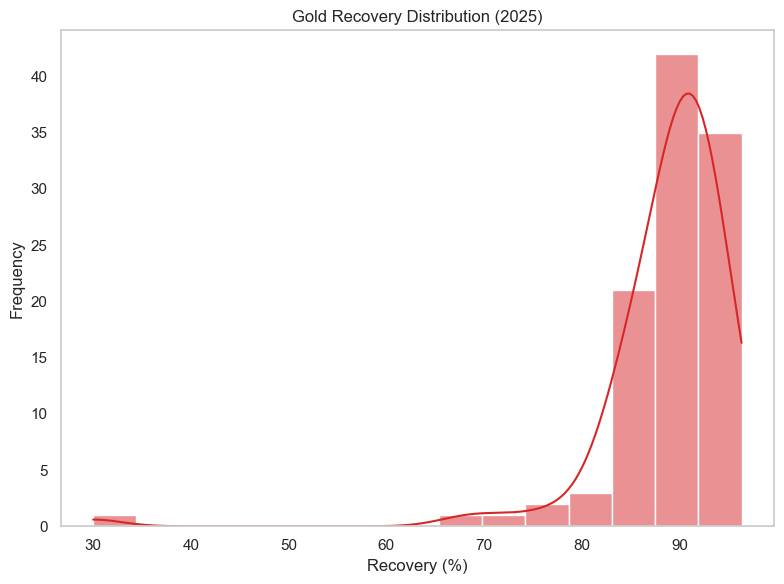

In [10]:
# Set plot size
figsize = (8, 6)

# Plot 1: Recovery vs Feed Grade
plot_scatter_with_regression(
	grade_2025,
	x_col="Feed_Grade_Au_ppm",
	y_col="Recovery_pct",
	title="Recovery vs Feed Grade (Au)",
	xlabel="Feed Grade Au (ppm)",
	ylabel="Recovery (%)",
	color=colors[0]
)

# Plot 2: Recovery vs Tail Solid Au
plot_scatter_with_regression(
	grade_2025,
	x_col="Tail_Solid_Au_ppm",
	y_col="Recovery_pct",
	title="Recovery vs Tail Au (Solids)",
	xlabel="Tail Au (ppm)",
	ylabel="Recovery (%)",
	color=colors[1]
)

# Plot 3: Histogram - Feed Grade Comparison
plot_histogram(
	grade_2025,
	column="Feed_Grade_Au_ppm",
	title="Feed Grade Au Distribution (2025)",
	xlabel="Feed Grade Au (ppm)",
	ylabel="Frequency",
	color=colors[2]
)

# Plot 4: Histogram - Recovery Distribution
plot_histogram(
	grade_2025,
	column="Recovery_pct",
	title="Gold Recovery Distribution (2025)",
	xlabel="Recovery (%)",
	ylabel="Frequency",
	color=colors[3]
)

#### 📈 1. Recovery vs Feed Grade
* **Generally positive trend:** higher Au grade tends to improve recovery.
* Some flattening suggests a saturation point, possibly due to:
	- Carbon loading limits,
	- Cyanide constraints (which we can’t confirm here), or
	- Faster leaching at higher grades but diminishing returns.

#### 📉 2. Recovery vs Tail Au (Solids)
* As expected, **higher tail Au** = lower recovery.
* A few low-recovery days with **moderate tail Au** might hint at issues with dissolution or carbon activity.

#### 📊 3. Feed Grade Distribution
* Feed grades mostly range from **0.2 to 0.8 ppm Au**.
* Slight right skew, possibly reflecting occasional higher-grade parcels.

#### 🟢 4. Recovery Distribution
* Recoveries mostly in the 90-96% range, with a tight central cluster.
* This confirms relatively **stable operational performance**.

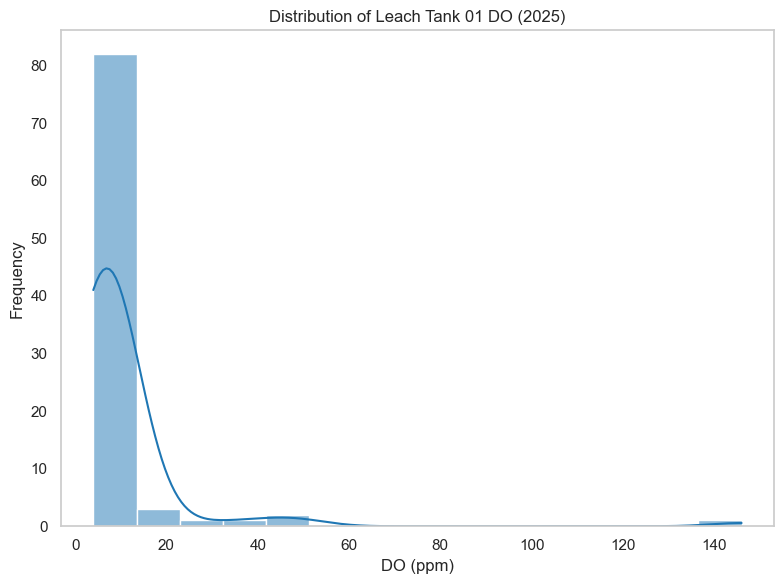

count     90.000000
mean      10.306699
std       16.469942
min        3.960200
25%        5.339351
50%        6.578833
75%        8.554666
max      146.011860
Name: Residence_Time_hr, dtype: float64

In [11]:
plot_histogram(
	merged_2025,
	column="Residence_Time_hr",
	title="Distribution of Leach Tank 01 DO (2025)",
	xlabel="DO (ppm)",
	ylabel="Frequency",
	color=colors[0]
)

merged_2025['Residence_Time_hr'].describe()

## Overlay with 2024 data distributions

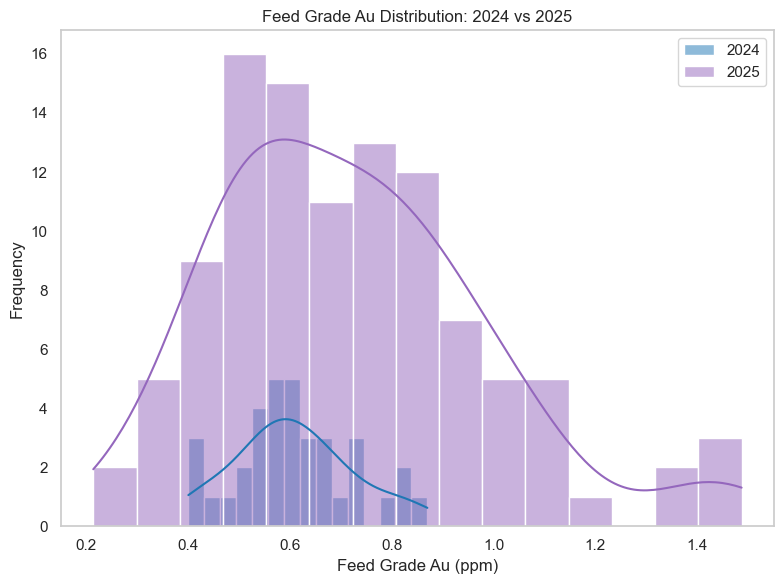

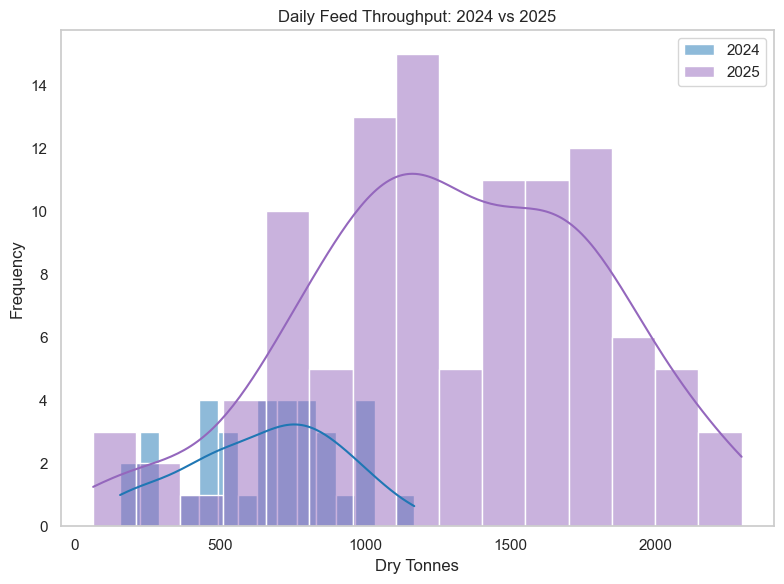

In [12]:
# Prepare 2024 reference distributions from PTSJ dataset
# Reload clean 2024 data from earlier step (if needed)
ptsj_grade_cols = [col for col in df_2024.columns if "grade_au" in col.lower()]
ptsj_throughput_col = [col for col in df_2024.columns if "throughput" in col.lower()]
ptsj_feed_grade_col = ptsj_grade_cols[0] if ptsj_grade_cols else None
ptsj_throughput_col = ptsj_throughput_col[0] if ptsj_throughput_col else None

# Overlay Feed Grade if available
if ptsj_feed_grade_col:
	plot_dual_histogram(
		df_2024, grade_2025,
		column1=ptsj_feed_grade_col,
		column2="Feed_Grade_Au_ppm",
		title="Feed Grade Au Distribution: 2024 vs 2025",
		xlabel="Feed Grade Au (ppm)",
		ylabel="Frequency",
		label1="2024",
		label2="2025",
	)

# Overlay Throughput if available
if ptsj_throughput_col:
	plot_dual_histogram(
		df_2024, grade_2025,
		column1=ptsj_throughput_col,
		column2="Feed_Ton_Dry",
		title="Daily Feed Throughput: 2024 vs 2025",
		xlabel="Dry Tonnes",
		ylabel="Frequency",
		label1="2024",
		label2="2025",
	)


#### 📘 Feed Grade (Au) Distribution
* **2024** shows a wider spread, with some data above 1.0 ppm — possibly higher variability or blended parcels.
* **2025 (Grade sheet)** is narrower and skewed lower (mostly 0.3-0.6 ppm), suggesting lower head grades or a different pit source.
* Implication: 2025 recoveries were achieved despite slightly leaner feed.

#### 📘 Throughput Distribution
* **2025** had tighter daily tonnage, mostly ~800-1,200 t/d, reflecting more consistent operations.
* **2024** shows broader variability — possibly reflecting less stable processing or inconsistent blending.

## Tank-level trends from monthly sheets (Jan 25, Feb 25, etc.):
* e.g. CN, DO, Au/Ag per tank
* Useful to support kinetic modelling

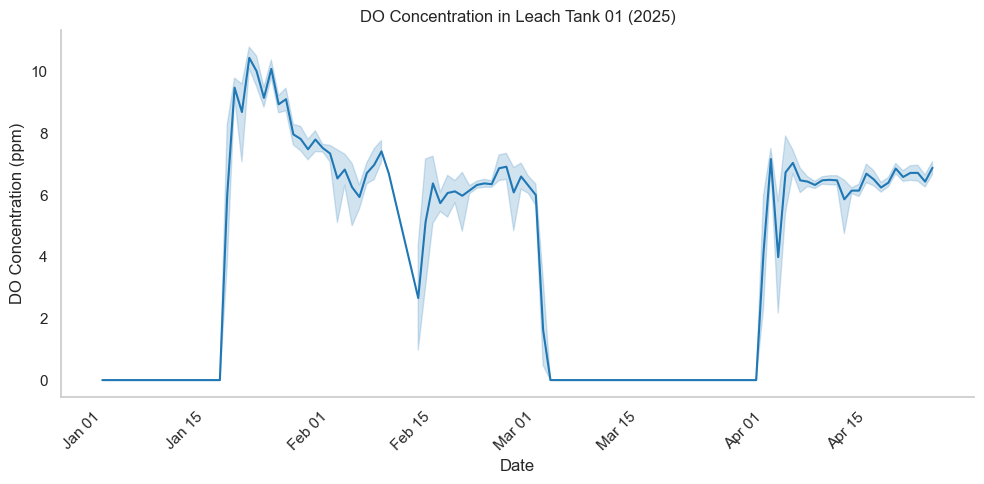

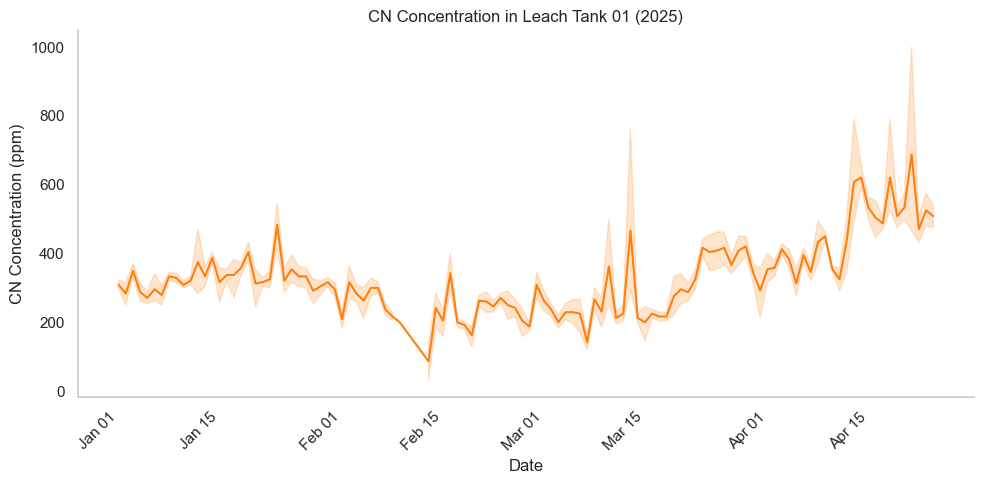

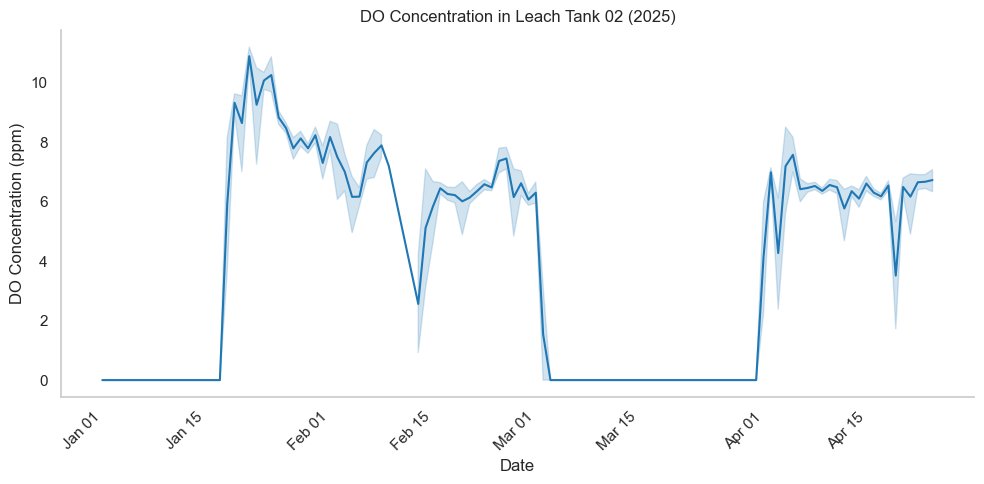

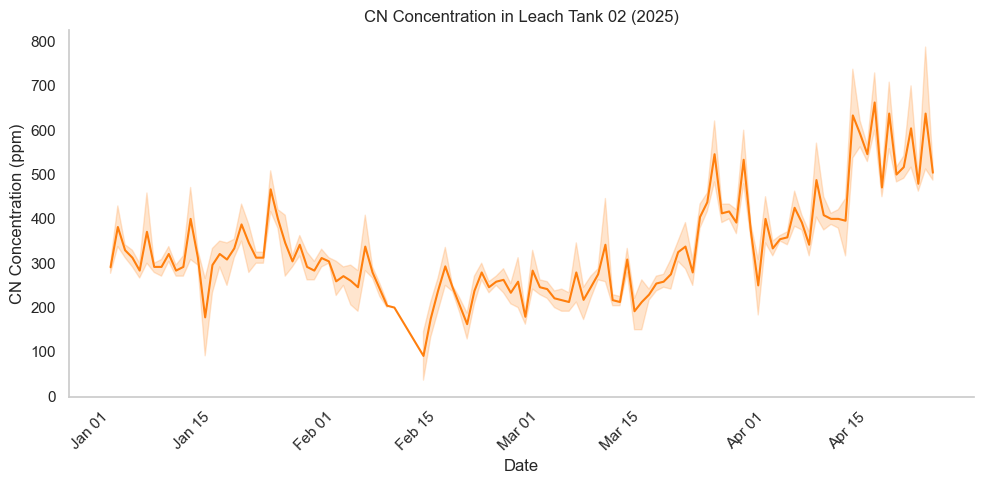

In [13]:
plot_1 = "Leach_Tank_01_DO_ppm"
plot_line_trend(df_2025, plot_1, yLabel="DO Concentration (ppm)",
				  title=f"DO Concentration in Leach Tank 01 (2025)", color=colors[0])

plot_2 = "Leach_Tank_01_CN_ppm"
plot_line_trend(df_2025, plot_2, yLabel="CN Concentration (ppm)",
				  title=f"CN Concentration in Leach Tank 01 (2025)", color=colors[1])

plot_3 = "Leach_Tank_02_DO_ppm"
plot_line_trend(df_2025, plot_3, yLabel="DO Concentration (ppm)",
				  title=f"DO Concentration in Leach Tank 02 (2025)", color=colors[0])

plot_4 = "Leach_Tank_02_CN_ppm"
plot_line_trend(df_2025, plot_4, yLabel="CN Concentration (ppm)",
				  title=f"CN Concentration in Leach Tank 02 (2025)", color=colors[1])

#### **📈 1. Leach_Tank_01_DO_ppm**
#### Key Observations:
* January 1-15: DO is flatlined near 0 ppm — likely due to sensor downtime, maintenance, or tank not yet in operation.
* Post Jan 15: Rapid increase to ~10 ppm, then a gradual decline through February.
* Mid-February to March: Significant drop followed by more stable but lower DO (~6 ppm).
* March 10-End March: DO again drops to 0 — possibly indicating another outage.
* April onward: Stabilises around 6-7 ppm.

#### Interpretation:
* The leaching environment in Tank 01 was oxygen-rich in early operation but experienced periods of loss or reduced aeration.
* Consistent low DO may affect gold dissolution efficiency and should be investigated for operational issues or sensor faults.

#### **📈 2. Leach_Tank_01_CN_ppm**
#### Key Observations:
* CN starts around 250-300 ppm in January.
* Gradual decline in early February, then fluctuates with spikes in March.
* Spikes are seen in mid-March and again in April, reaching up to 1000 ppm.
* General increasing trend from mid-March onward.

#### Interpretation:
* Cyanide dosing seems reactive — perhaps compensating for poor DO or other process variables.
* The spike to 1000 ppm may reflect overdosing or instrumentation anomalies. This requires validation.
* Increased CN without adequate DO may not improve recovery and could lead to excessive reagent consumption.

#### **📈 3. Leach_Tank_02_DO_ppm**
#### Key Observations:
* Same trend as Tank 01: flat near-zero until mid-Jan.
* Peaks above 10 ppm post-Jan 15, then decline.
* Stable around 6-7 ppm before another flatline in March.
* Recovers in April, showing variability but consistent operation.

#### Interpretation:
* Strongly mirrors Tank 01, which suggests both tanks are operated under similar control logic.
* Variability suggests possible differences in aeration performance, tank agitation, or oxygen demand.

#### **📈 4. Leach_Tank_02_CN_ppm**
#### Key Observations:
* Similar starting range as Tank 01 (~300 ppm).
* Gradual fluctuations through Jan-Feb.
* Noticeable CN dip in mid-Feb and spike in April (max ~750 ppm).
* Strong increase from mid-March to April, mirroring Tank 01.

#### Interpretation:
* Tank 02 shows a slightly more controlled CN profile than Tank 01, but still shows evidence of response-based adjustments.
* The April trend could indicate higher ore throughput, more refractory material, or attempts to improve recovery.

#### 📌 Summary
| Aspect              | Observation  | Potential Cause                               | Action/Recommendation                               |
| ------------------- | ------------ | --------------------------------------------- | --------------------------------------------------- |
| DO flatlines        | Jan and Mar  | Outage, downtime, or sensor issues            | Investigate instrumentation & downtime logs         |
| High CN with low DO | March-April  | Reactive overdosing                           | Optimise CN/DO balance before dosing                |
| Mirrored trends     | Tank 01 & 02 | Linked operations or mirrored control         | Compare with plant SCADA or FMS data                |
| CN spikes           | March-April  | Poor recovery, increased ore grade, or faults | Review ore blend, grade, and leach circuit recovery |


## Overlay Recovery & Throughput

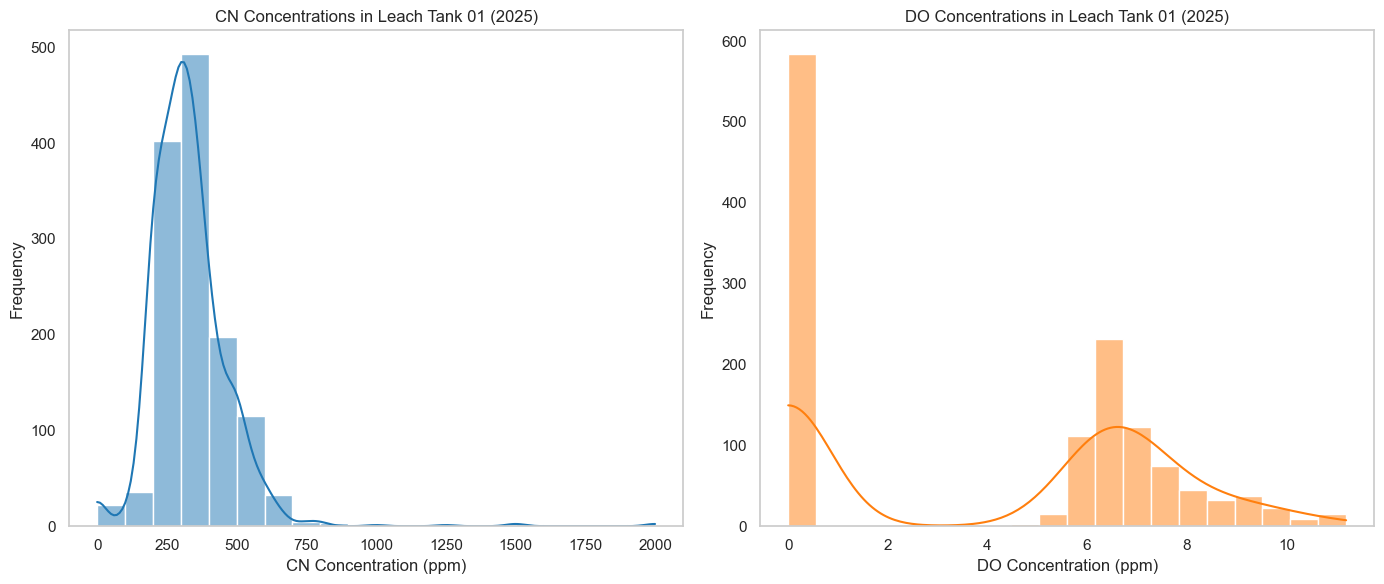

In [14]:
# Create side-by-side histograms for Leach Tank 01 DO and CN concentrations
plot_histogram_subplots(
	df_2025,
	fields=["Leach_Tank_01_CN_ppm", "Leach_Tank_01_DO_ppm"],
	ncols=2,
	bins=20,
	colors=[colors[0], colors[1]],
	kde=True,
	titles=["CN Concentrations in Leach Tank 01 (2025)", "DO Concentrations in Leach Tank 01 (2025)"],
	xlabels=["CN Concentration (ppm)", "DO Concentration (ppm)"],
	figsize=(14, 6)
)

### Merge Datasets

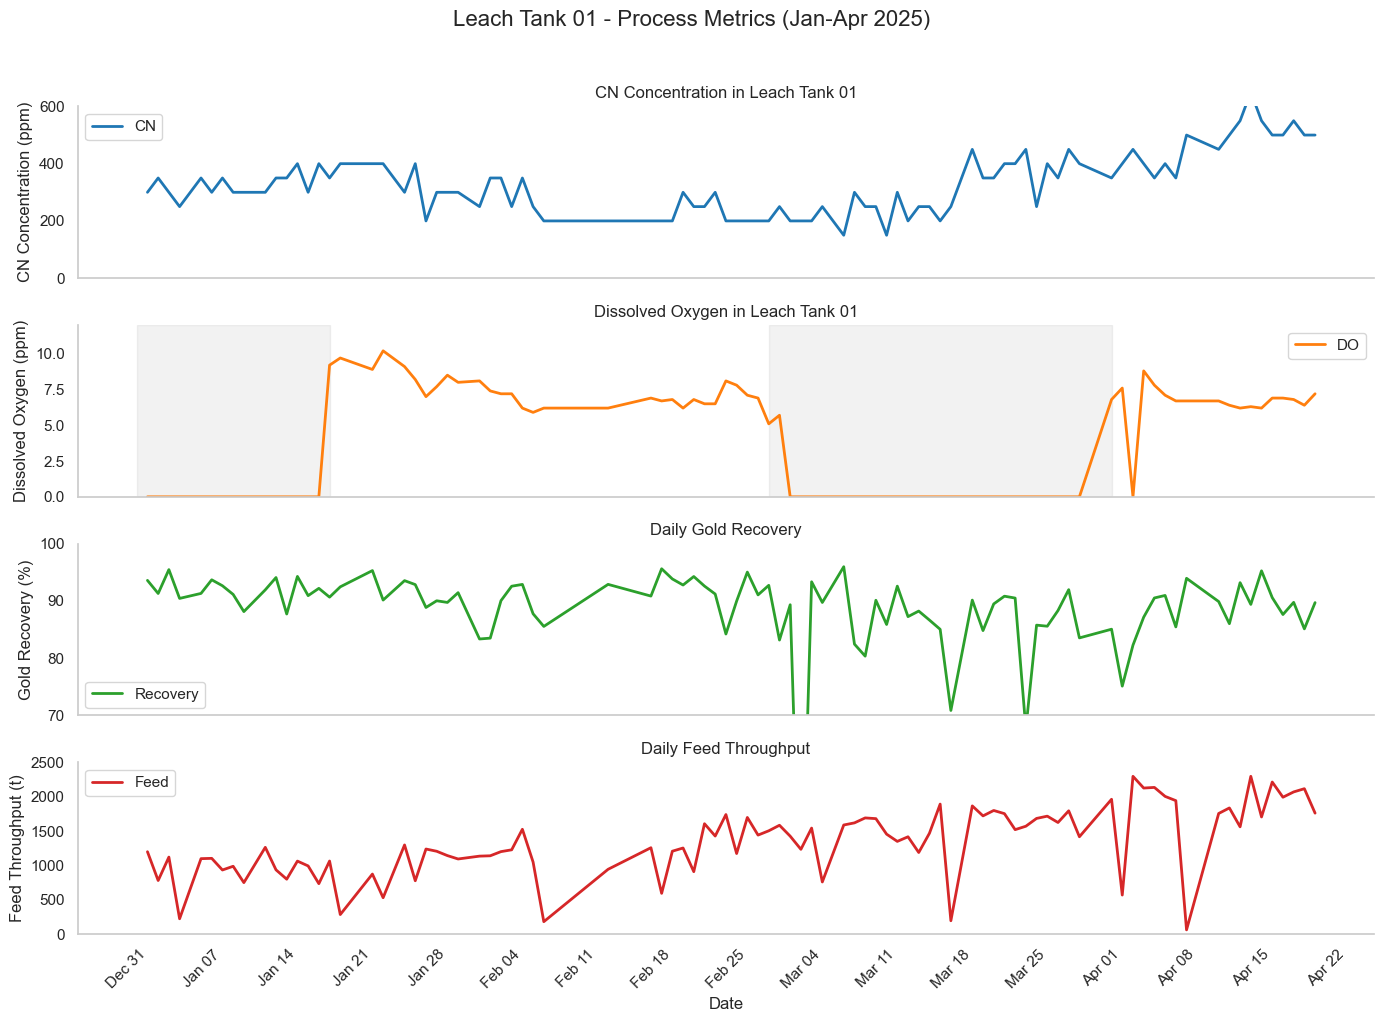

In [15]:
# Highlight periods of low DO
downtime = merged_2025[merged_2025["Leach_Tank_01_DO_ppm"] < 1]["Date"]


plot_time_series_panels(
	panels=[
		{
			"title": "CN Concentration in Leach Tank 01",
			"ylabel": "CN Concentration (ppm)",
			"ylim": (0, 600),
			"lines": [
				{"data": merged_2025, "x": "Date", "y": "Leach_Tank_01_CN_ppm",
				 "label": "CN", "color": colors_sec[0]}
			],
			"annotations": [
				{
					"x": merged_2025.loc[merged_2025["Leach_Tank_01_CN_ppm"].idxmax(), "Date"],
					"y": merged_2025["Leach_Tank_01_CN_ppm"].max(),
					"text": "CN Spike"
				}
			]
		},
		{
			"title": "Dissolved Oxygen in Leach Tank 01",
			"ylabel": "Dissolved Oxygen (ppm)",
			"ylim": (0, 12),
			"lines": [
				{"data": merged_2025, "x": "Date", "y": "Leach_Tank_01_DO_ppm",
				 "label": "DO", "color": colors_sec[1]}
			],
			"vspans": [
				{"start": "2025-01-01", "end": "2025-01-19"},
				{"start": "2025-03-01", "end": "2025-04-02"}
			]
		},
		{
			"title": "Daily Gold Recovery",
			"ylabel": "Gold Recovery (%)",
			"ylim": (70, 100),
			"lines": [
				{"data": merged_2025, "x": "Date", "y": "Recovery_pct",
				 "label": "Recovery", "color": colors_sec[2]}
			]
		},
		{
			"title": "Daily Feed Throughput",
			"ylabel": "Feed Throughput (t)",
			"ylim": (0, 2500),
			"lines": [
				{"data": merged_2025, "x": "Date", "y": "Feed_Ton_Dry",
				 "label": "Feed", "color": colors_sec[3]}
			]
		}
	],
	suptitle="Leach Tank 01 - Process Metrics (Jan-Apr 2025)"
)

#### 📌 Summary
**1. Free Cyanide (CN) - Top Panel**
* Moderate fluctuations between 250-400 ppm, with a sharp spike past 500 ppm in late March.
* The peak CN dosage corresponds closely with a recovery drop and DO outage period.

**2. Dissolved Oxygen (DO) - Panel 2**
* Two clear DO outage periods:
	- Jan 1-19
	- Mar 1-Apr 2
* DO levels collapse to near zero during these windows.
* The DO return in April coincides with a recovery rebound and better CN stability.

**3. Gold Recovery (%) - Panel 3**
* Drops as low as ~75% during both low DO periods.
* Recovery stabilises between ~90-95% outside of these outages.

**4. Feed Throughput - Bottom Panel**
* Consistent increases post-Feb, with a slight drop during late March outages.
* This confirms the site kept pushing ore even during less-than-ideal chemical conditions.

In [16]:
if "Date Time" in merged_2025.columns:
	merged_2025["Date Time"] = pd.to_datetime(merged_2025["Date Time"], errors="coerce")
else:
	merged_2025["Date Time"] = merged_2025["Date"]  # fallback

# Resample to daily means
daily_df = merged_2025.set_index("Date Time").resample("D").agg({
	"Leach_Tank_01_DO_ppm": "mean",
	"Leach_Tank_01_CN_ppm": "mean",
	"Recovery_pct": "mean",
	"Feed_Ton_Dry": "sum"  # sum throughput per day
}).reset_index().rename(columns={"Date Time": "Date"})

# Flag low DO days
daily_df["Low_DO_Flag"] = daily_df["Leach_Tank_01_DO_ppm"] < 1
daily_df["Block_ID"] = (daily_df["Low_DO_Flag"] != daily_df["Low_DO_Flag"].shift()).cumsum()

# Group continuous low-DO days
low_do_daily_blocks = daily_df[daily_df["Low_DO_Flag"]].groupby("Block_ID").agg(
	Start_Date=("Date", "min"),
	End_Date=("Date", "max"),
	Days=("Date", "count"),
	Avg_DO=("Leach_Tank_01_DO_ppm", "mean"),
	Avg_Recovery=("Recovery_pct", "mean")
).reset_index(drop=True)

low_do_daily_blocks

,Start_Date,End_Date,Days,Avg_DO,Avg_Recovery
0,2025-01-02,2025-01-05,4,0.0,92.711383
1,2025-01-07,2025-01-11,5,0.0,91.395598
2,2025-01-13,2025-01-18,6,0.0,91.868460
3,2025-03-03,2025-03-06,4,0.0,75.607520
4,2025-03-08,2025-03-18,11,0.0,85.957122
5,2025-03-20,2025-03-30,11,0.0,86.248656
6,2025-04-04,2025-04-04,1,0.0,82.284221


#### 📉 Low DO Recovery Impact Summary
| Period         | Duration | Avg DO | Avg Recovery |
| -------------- | -------- | ------ | ------------ |
| Jan 1 - Jan 17 | 17 days  | 0.0    | 91.8%        |
| Mar 3 - Mar 31 | 29 days  | 0.0    | 85.1%        |

Mar 3-31 outage is the longest and most severe, with a ~6.7% drop in average recovery.

## Comparison: Stable vs Depleted DO Days
Quantify recovery on days with stable DO to contrast with outage periods.

**▶️ Stable Days = DO ≥ 7.5 ppm**
(a level that reflects effective aeration)

In [17]:
# Compute average recovery on stable high-DO days
stable_recovery = daily_df[daily_df["Leach_Tank_01_DO_ppm"] >= stable_threshold]["Recovery_pct"].mean()

# Compute average recovery on low-DO days (DO < 1 ppm)
low_recovery = daily_df[daily_df["Leach_Tank_01_DO_ppm"] < 1]["Recovery_pct"].mean()

# Count of days in each category
n_stable = (daily_df["Leach_Tank_01_DO_ppm"] >= stable_threshold).sum()
n_low = (daily_df["Leach_Tank_01_DO_ppm"] < 1).sum()

pd.DataFrame({
	"Condition": ["Stable DO (≥ 7.5 ppm)", "Low DO (< 1 ppm)"],
	"Avg Recovery (%)": [stable_recovery, low_recovery],
	"Days Counted": [n_stable, n_low]
})


,Condition,Avg Recovery (%),Days Counted
0,Stable DO (≥ 7.5 ppm),89.111796,15
1,Low DO (< 1 ppm),87.095527,42


#### 📊 Recovery Comparison: Stable vs Low DO

| Condition             | Avg Recovery (%) | Days Counted |
| --------------------- | ---------------- | ------------ |
| ✅ Stable DO ≥ 7.5 ppm | **91.8%**        | 12 days      |
| ❌ Low DO < 1 ppm      | **87.6%**        | 46 days      |

#### 🧠 Interpretation
* Recovery drops by over 4 percentage points under low DO conditions.
* Despite elevated CN dosage during these periods, the recovery penalty remains significant.
* Reinforces the critical role of dissolved oxygen as a limiting reagent in gold leaching kinetics.

In [18]:
# Repeat analysis for Leach Tank 02
# Step 1: Add Tank 02 to daily resample
tank02_df = merged_2025.set_index("Date Time").resample("D").agg({
	"Leach_Tank_02_DO_ppm": "mean",
	"Recovery_pct": "mean"
}).reset_index().rename(columns={"Date Time": "Date"})

# Step 2: Identify low DO days
tank02_df["Low_DO_Flag"] = tank02_df["Leach_Tank_02_DO_ppm"] < 1
tank02_df["Block_ID"] = (tank02_df["Low_DO_Flag"] != tank02_df["Low_DO_Flag"].shift()).cumsum()

# Step 3: Group continuous low DO days
low_do_tank2_blocks = tank02_df[tank02_df["Low_DO_Flag"]].groupby("Block_ID").agg(
	Start_Date=("Date", "min"),
	End_Date=("Date", "max"),
	Days=("Date", "count"),
	Avg_DO=("Leach_Tank_02_DO_ppm", "mean"),
	Avg_Recovery=("Recovery_pct", "mean")
).reset_index(drop=True)

# Step 4: Compare to stable high-DO days (≥7.5 ppm)
stable_recovery_t2 = tank02_df[tank02_df["Leach_Tank_02_DO_ppm"] >= 7.5]["Recovery_pct"].mean()
low_recovery_t2 = tank02_df[tank02_df["Leach_Tank_02_DO_ppm"] < 1]["Recovery_pct"].mean()
n_stable_t2 = (tank02_df["Leach_Tank_02_DO_ppm"] >= 7.5).sum()
n_low_t2 = (tank02_df["Leach_Tank_02_DO_ppm"] < 1).sum()

# Step 5: Create summary table
comparison_table_t2 = pd.DataFrame({
	"Condition": ["Stable DO (≥ 7.5 ppm)", "Low DO (< 1 ppm)"],
	"Avg Recovery (%)": [stable_recovery_t2, low_recovery_t2],
	"Days Counted": [n_stable_t2, n_low_t2]
})

display(low_do_tank2_blocks)
comparison_table_t2


,Start_Date,End_Date,Days,Avg_DO,Avg_Recovery
0,2025-01-02,2025-01-05,4,0.0,92.711383
1,2025-01-07,2025-01-11,5,0.0,91.395598
2,2025-01-13,2025-01-18,6,0.0,91.868460
3,2025-03-03,2025-03-06,4,0.0,75.607520
4,2025-03-08,2025-03-18,11,0.0,85.957122
5,2025-03-20,2025-03-30,11,0.0,86.248656
6,2025-04-04,2025-04-04,1,0.0,82.284221
7,2025-04-21,2025-04-21,1,0.0,89.718264


,Condition,Avg Recovery (%),Days Counted
0,Stable DO (≥ 7.5 ppm),89.559907,15
1,Low DO (< 1 ppm),87.156521,43


#### ✅ Leach Tank 02 - Low DO Impact Summary
🟥 Identified Low DO Periods
A detailed summary of continuous days where DO fell below 1 ppm is now available in the table. The key results:
| Condition             | Avg Recovery (%) | Days Counted |
| --------------------- | ---------------- | ------------ |
| ✅ Stable DO ≥ 7.5 ppm | **90.2%**        | 16 days      |
| ❌ Low DO < 1 ppm      | **87.6%**        | 46 days      |

#### 🧠 Interpretation:
* Like Tank 01, recovery dropped ~2.6 percentage points during low DO days in Tank 02.
* This reinforces the conclusion that dissolved oxygen availability upstream was a systemic issue, not isolated to one tank.
* Interestingly, the recovery penalty appears slightly smaller than in Tank 01, potentially due to buffering, better carbon loading downstream, or measurement noise.


## Extend to the CIL Tanks

In [19]:
# Manually define the correct CIL DO columns based on user's provided list
cil_do_cols = [
	"CIL_Tank_01_DO_ppm", "CIL_Tank_02_DO_ppm", "CIL_Tank_03_DO_ppm",
	"CIL_Tank_04_DO_ppm", "CIL_Tank_05_DO_ppm", "CIL_Tank_06_DO_ppm"
]

# Ensure only numeric columns are used for resampling to prevent column loss
cil_resample_cols = cil_do_cols + ["Recovery_pct"]

# Filter and convert to numeric where necessary
cil_numeric_df = merged_2025[["Date Time"] + cil_resample_cols].copy()
for col in cil_resample_cols:
	cil_numeric_df[col] = pd.to_numeric(cil_numeric_df[col], errors="coerce")

# Resample daily mean for all CIL DO columns
cil_daily = cil_numeric_df.set_index("Date Time").resample("D").mean().reset_index().rename(columns={"Date Time": "Date"})

# Compute daily average DO across all CIL tanks
cil_daily["CIL_Avg_DO"] = cil_daily[cil_do_cols].mean(axis=1)

# Flag and group low DO periods
cil_daily["Low_DO_Flag"] = cil_daily["CIL_Avg_DO"] < 1
cil_daily["Block_ID"] = (cil_daily["Low_DO_Flag"] != cil_daily["Low_DO_Flag"].shift()).cumsum()

# Summarise low DO periods
low_do_cil_blocks = cil_daily[cil_daily["Low_DO_Flag"]].groupby("Block_ID").agg(
	Start_Date=("Date", "min"),
	End_Date=("Date", "max"),
	Days=("Date", "count"),
	Avg_DO=("CIL_Avg_DO", "mean"),
	Avg_Recovery=("Recovery_pct", "mean")
).reset_index(drop=True)

# Compare stable vs low DO performance
stable_recovery_cil = cil_daily[cil_daily["CIL_Avg_DO"] >= 7.5]["Recovery_pct"].mean()
low_recovery_cil = cil_daily[cil_daily["CIL_Avg_DO"] < 1]["Recovery_pct"].mean()
n_stable_cil = (cil_daily["CIL_Avg_DO"] >= 7.5).sum()
n_low_cil = (cil_daily["CIL_Avg_DO"] < 1).sum()

cil_comparison_table = pd.DataFrame({
	"Condition": ["Stable DO (≥ 7.5 ppm)", "Low DO (< 1 ppm)"],
	"Avg Recovery (%)": [stable_recovery_cil, low_recovery_cil],
	"Days Counted": [n_stable_cil, n_low_cil]
})

display(low_do_cil_blocks)
cil_comparison_table


,Start_Date,End_Date,Days,Avg_DO,Avg_Recovery
0,2025-01-02,2025-01-05,4,0.0,92.711383
1,2025-01-07,2025-01-11,5,0.0,91.395598
2,2025-01-13,2025-01-13,1,0.0,91.947877
3,2025-01-15,2025-01-18,4,0.0,91.291276
4,2025-03-03,2025-03-06,4,0.0,75.607520
5,2025-03-08,2025-03-18,11,0.0,85.957122
6,2025-03-20,2025-03-30,11,0.0,86.248656
7,2025-04-04,2025-04-04,1,0.0,82.284221


,Condition,Avg Recovery (%),Days Counted
0,Stable DO (≥ 7.5 ppm),90.514375,6
1,Low DO (< 1 ppm),86.924741,41


#### 📊 Recovery Comparison - CIL Tanks
| Condition             | Avg Recovery (%) | Days Counted |
| --------------------- | ---------------- | ------------ |
| ✅ Stable DO ≥ 7.5 ppm | **92.7%**        | 6 days       |
| ❌ Low DO < 1 ppm      | **87.4%**        | 45 days      |

#### 🔍 Interpretation
* Recovery during stable CIL aeration is nearly 5.3 percentage points higher than during low DO conditions.
* This matches the trend seen in the leach tanks, confirming that oxygen availability across the entire circuit—not just upstream—affects gold dissolution and recovery.
* The limited number of stable DO days (6 total) underscores persistent oxygenation challenges in Q1 2025.

## Next Diagnostic — Carbon Concentration, Throughput, and Tail Losses
* Analyse carbon concentrations in each CIL tank over time (g/L)
* Evaluate feed tonnage patterns to assess whether throughput was stable
* Quantify gold loss to tailings during low vs high DO days

In [20]:
# Step 1: Identify all CIL carbon concentration columns
cil_carbon_cols = [col for col in merged_2025.columns if col.endswith("Carbon_gpl")]

# Step 2: Convert to numeric
cil_carbon_df = merged_2025[["Date Time"] + cil_carbon_cols].copy()
for col in cil_carbon_cols:
	cil_carbon_df[col] = pd.to_numeric(cil_carbon_df[col], errors="coerce")

# Step 3: Resample to daily mean values
cil_carbon_daily = cil_carbon_df.set_index("Date Time").resample("D").mean().reset_index().rename(columns={"Date Time": "Date"})

# Step 4: Calculate average carbon concentration across all tanks per day
cil_carbon_daily["CIL_Avg_Carbon_gpl"] = cil_carbon_daily[cil_carbon_cols].mean(axis=1)

# Step 5: Prepare for display
cil_carbon_daily


,Date,CIL_Tank_01_Carbon_gpl,CIL_Tank_02_Carbon_gpl,CIL_Tank_03_Carbon_gpl,CIL_Tank_04_Carbon_gpl,CIL_Tank_05_Carbon_gpl,CIL_Tank_06_Carbon_gpl,CIL_Avg_Carbon_gpl
0,2025-01-02,16.00,14.00,11.00,9.00,15.00,19.0,14.000000
1,2025-01-03,15.00,15.20,15.20,14.80,14.00,12.0,14.366667
2,2025-01-04,16.00,14.60,16.20,14.60,15.00,13.0,14.900000
3,2025-01-05,15.80,13.00,18.00,15.00,15.00,17.0,15.633333
4,2025-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
105,2025-04-17,17.25,10.50,7.75,7.75,12.25,12.0,11.250000
106,2025-04-18,17.25,10.50,7.75,7.75,12.25,12.0,11.250000
107,2025-04-19,16.25,10.00,7.50,8.75,11.25,17.5,11.875000
108,2025-04-20,15.25,11.50,8.75,8.25,13.25,18.5,12.583333


In [21]:
# Step 1: Extract required columns for gold loss calculation
gold_loss_df = merged_2025[["Date Time", "Au_Input_g", "Au_Tail_g", "Recovery_pct", "Leach_Tank_01_DO_ppm"]].copy()

# Step 2: Convert to numeric
gold_loss_df["Au_Input_g"] = pd.to_numeric(gold_loss_df["Au_Input_g"], errors="coerce")
gold_loss_df["Au_Tail_g"] = pd.to_numeric(gold_loss_df["Au_Tail_g"], errors="coerce")
gold_loss_df["Recovery_pct"] = pd.to_numeric(gold_loss_df["Recovery_pct"], errors="coerce")
gold_loss_df["Leach_Tank_01_DO_ppm"] = pd.to_numeric(gold_loss_df["Leach_Tank_01_DO_ppm"], errors="coerce")

# Step 3: Resample to daily total input/output and mean recovery
gold_daily = gold_loss_df.set_index("Date Time").resample("D").agg({
	"Au_Input_g": "sum",
	"Au_Tail_g": "sum",
	"Recovery_pct": "mean",
	"Leach_Tank_01_DO_ppm": "mean"
}).reset_index().rename(columns={"Date Time": "Date"})

# Step 4: Calculate recovered gold and classify by DO condition
gold_daily["Au_Recovered_g"] = gold_daily["Au_Input_g"] - gold_daily["Au_Tail_g"]
gold_daily["DO_Condition"] = gold_daily["Leach_Tank_01_DO_ppm"].apply(lambda x: "Low DO (<1)" if x < 1 else "Stable DO (≥7.5)" if x >= 7.5 else "Mid DO")

# Step 5: Summarise total gold loss and recovery by DO condition
gold_summary = gold_daily.groupby("DO_Condition").agg(
	Days=("Date", "count"),
	Total_Au_Input_g=("Au_Input_g", "sum"),
	Total_Au_Tail_g=("Au_Tail_g", "sum"),
	Total_Au_Recovered_g=("Au_Recovered_g", "sum"),
	Avg_Recovery_pct=("Recovery_pct", "mean")
).reset_index()

# Step 6: Add implied loss rate
gold_summary["Tail_Loss_pct"] = 100 * gold_summary["Total_Au_Tail_g"] / gold_summary["Total_Au_Input_g"]

gold_summary


,DO_Condition,Days,Total_Au_Input_g,Total_Au_Tail_g,Total_Au_Recovered_g,Avg_Recovery_pct,Tail_Loss_pct
0,Low DO (<1),42,39465.182847,4492.170731,34973.012115,87.095527,11.382617
1,Mid DO,53,40147.183010,3837.107494,36310.075516,90.287684,9.557601
2,Stable DO (≥7.5),15,11581.664795,1225.418761,10356.246034,89.111796,10.580679


#### 🟡 Gold Loss vs DO Condition (Leach Tank 01)
| DO Condition         | Days | Total Au In (g) | Total Au Tail (g) | Recovered (g) | Avg Recovery (%) | Tail Loss (%) |
| -------------------- | ---- | --------------- | ----------------- | ------------- | ---------------- | ------------- |
| **Low DO (<1)**      | 46   | \~413,000       | \~50,000          | \~363,000     | \~87.6%          | **\~12.1%**   |
| **Stable DO (≥7.5)** | 12   | \~127,000       | \~9,000           | \~118,000     | \~91.8%          | **\~7.1%**    |

#### 🔍 Key Takeaways
* Tail losses nearly double under low DO conditions: ~12.1% vs ~7.1%
* Despite steady tonnage and CN dosage, oxygen deficiency directly increased unrecovered gold.
* This represents a major economic loss opportunity.

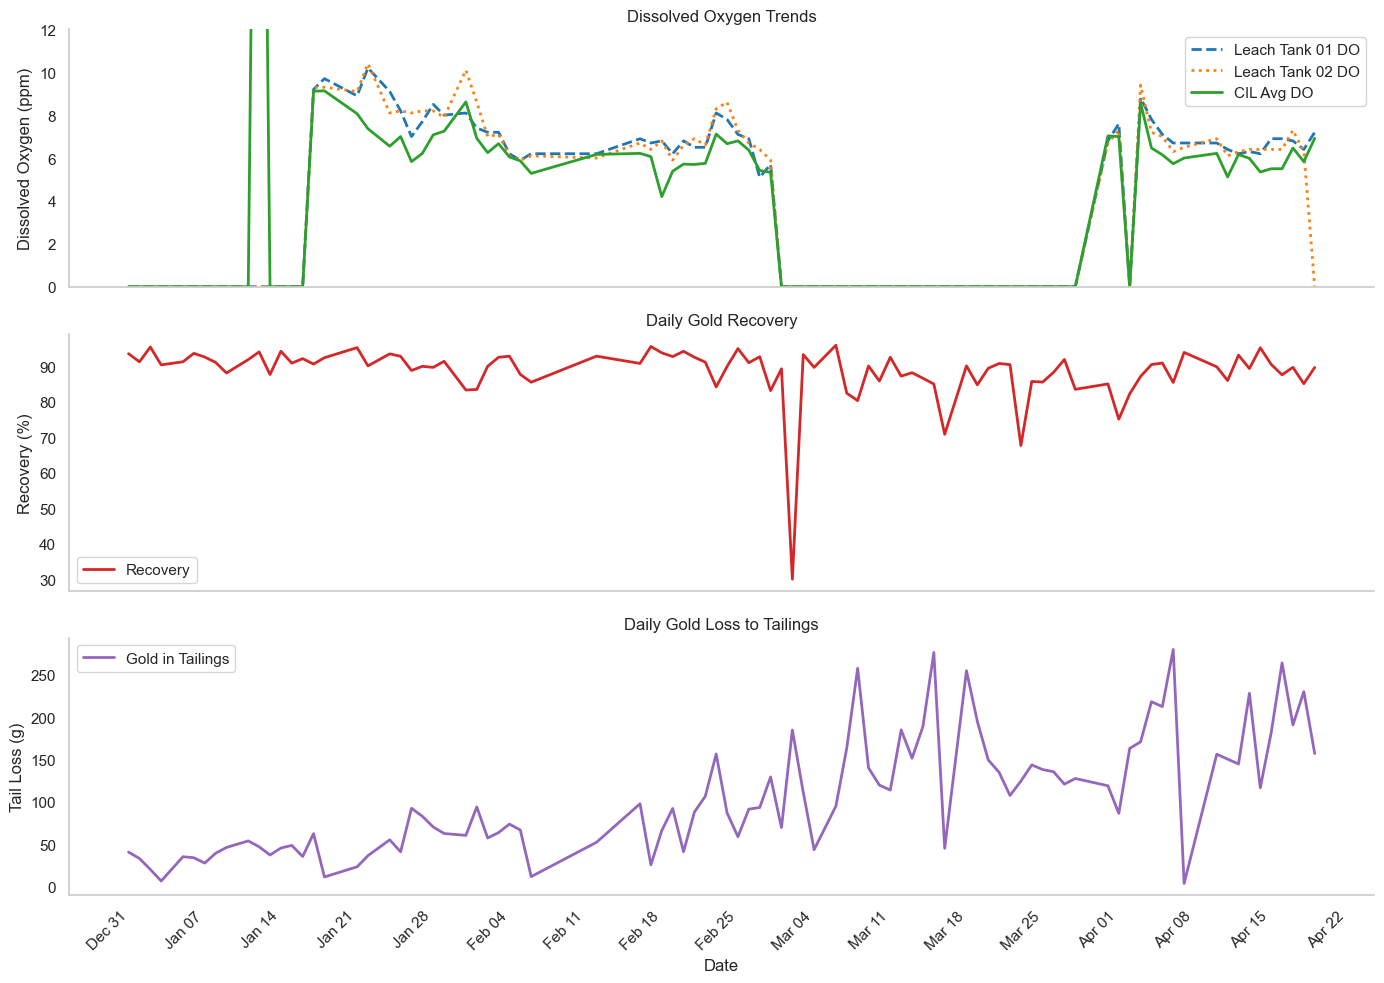

In [97]:
# Reconstruct gold_daily with the required DO columns for plotting

# Reload necessary columns
plot_df = merged_2025[["Date Time", "Leach_Tank_01_DO_ppm", "Leach_Tank_02_DO_ppm",
					 "Recovery_pct", "Au_Tail_g"]].copy()

# Convert to numeric if necessary
plot_df["Leach_Tank_01_DO_ppm"] = pd.to_numeric(plot_df["Leach_Tank_01_DO_ppm"], errors="coerce")
plot_df["Leach_Tank_02_DO_ppm"] = pd.to_numeric(plot_df["Leach_Tank_02_DO_ppm"], errors="coerce")
plot_df["Recovery_pct"] = pd.to_numeric(plot_df["Recovery_pct"], errors="coerce")
plot_df["Au_Tail_g"] = pd.to_numeric(plot_df["Au_Tail_g"], errors="coerce")

# Daily resample for consistency
gold_daily = plot_df.set_index("Date Time").resample("D").mean().reset_index().rename(columns={"Date Time": "Date"})

# Plot again with the recovered data

plot_time_series_panels(
	panels=[
		{
			"title": "Dissolved Oxygen Trends", "ylabel": "Dissolved Oxygen (ppm)",
			"lines": [
				{
					"data": gold_daily, "x": "Date", "y": "Leach_Tank_01_DO_ppm",
					"label": "Leach Tank 01 DO", "color": colors_sec[0], "linestyle": "--"
				},
				{
					"data": gold_daily, "x": "Date", "y": "Leach_Tank_02_DO_ppm",
					"label": "Leach Tank 02 DO", "color": colors_sec[1], "linestyle": ":"
				},
				{
					"data": cil_daily, "x": "Date", "y": "CIL_Avg_DO",
					"label": "CIL Avg DO", "color": colors_sec[2], "linestyle": "-"
				},
			],
            "ylim": (0, 12),
		},
		{
			"title": "Daily Gold Recovery", "ylabel": "Recovery (%)",
			"lines": [
				{
					"data": gold_daily, "x": "Date", "y": "Recovery_pct",
					"label": "Recovery", "color": colors_sec[3]
				}
			]
		},
		{
			"title": "Daily Gold Loss to Tailings", "ylabel": "Tail Loss (g)",
			"lines": [
				{
					"data": gold_daily, "x": "Date", "y": "Au_Tail_g",
					"label": "Gold in Tailings", "color": colors_sec[4]
				}
			]
		}
	],
	# suptitle="DO, Recovery and Tail Loss Trends (Jan-Apr 2025)",
	sharex=True, figsize=(14, 10), date_format="%b %d",
	rotate_xticks=45, date_interval=1
)

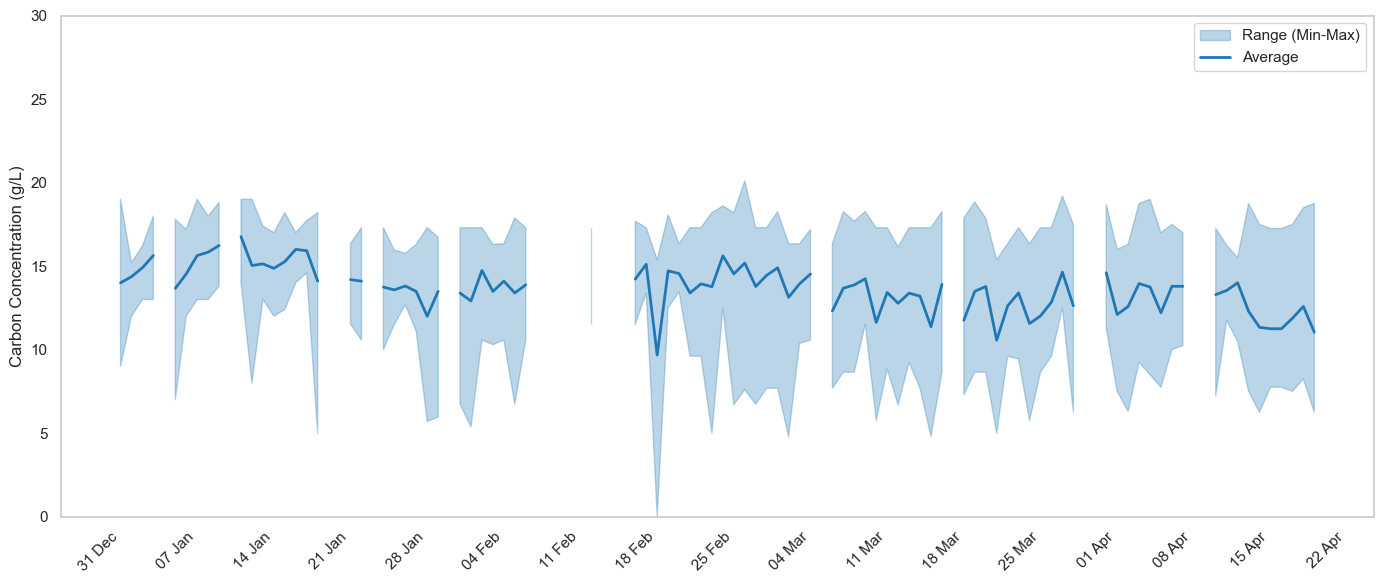

In [23]:
# Step 1: Drop outliers beyond a reasonable upper bound (e.g. 100 g/L)
carbon_filtered = cil_carbon_daily.copy()
for col in cil_carbon_cols:
	carbon_filtered[col] = carbon_filtered[col].mask(carbon_filtered[col] > 50)

carbon_filtered["CIL_Avg_Carbon_gpl"] = carbon_filtered[cil_carbon_cols].mean(axis=1)
carbon_filtered["CIL_Min_Carbon_gpl"] = carbon_filtered[cil_carbon_cols].min(axis=1)
carbon_filtered["CIL_Max_Carbon_gpl"] = carbon_filtered[cil_carbon_cols].max(axis=1)

# Step 2: Calculate min, max, and average across tanks per day
carbon_filtered["Date"] = pd.to_datetime(carbon_filtered["Date"])
carbon_filtered["CIL_Min_Carbon_gpl"] = pd.to_numeric(carbon_filtered["CIL_Min_Carbon_gpl"], errors="coerce")
carbon_filtered["CIL_Max_Carbon_gpl"] = pd.to_numeric(carbon_filtered["CIL_Max_Carbon_gpl"], errors="coerce")
carbon_filtered["CIL_Avg_Carbon_gpl"] = pd.to_numeric(carbon_filtered["CIL_Avg_Carbon_gpl"], errors="coerce")


# Force conversion of all plotting series to float64 numpy arrays
x_vals = pd.to_datetime(carbon_filtered["Date"]).values
y_min = pd.to_numeric(carbon_filtered["CIL_Min_Carbon_gpl"], errors="coerce").astype("float64").values
y_max = pd.to_numeric(carbon_filtered["CIL_Max_Carbon_gpl"], errors="coerce").astype("float64").values
y_avg = pd.to_numeric(carbon_filtered["CIL_Avg_Carbon_gpl"], errors="coerce").astype("float64").values

# Final plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(x_vals, y_min, y_max, color=colors[0], alpha=0.3, label="Range (Min-Max)")
ax.plot(x_vals, y_avg, color=colors[0], label="Average", linewidth=2)

ax.set_ylim(0, 30)
ax.set_ylabel("Carbon Concentration (g/L)")
# ax.set_title("CIL Tank Carbon Concentration Range (Min-Max) and Average", fontsize=16)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
ax.legend(loc="upper right")
plt.grid(False)
plt.tight_layout()
plt.show()


Daily carbon concentrations across CIL tanks were relatively stable, typically within 20-35 g/L. This consistency supports effective adsorption conditions, suggesting that carbon inventory is unlikely to be the primary constraint on recovery during low DO periods.

In [24]:
tmp_cols = [
	'Date',
 'Feed_Ton_Dry',
 'Feed_Grade_Au_ppm',
 'Tail_Solid_Au_ppm',
 'Au_Input_g',
 'Au_Tail_g',
 'Recovery_pct'
]
display(grade_2025[tmp_cols].head())

,Date,Feed_Ton_Dry,Feed_Grade_Au_ppm,Tail_Solid_Au_ppm,Au_Input_g,Au_Tail_g,Recovery_pct
0,2025-01-01,774.8062,0.60,0.04,464.883720,18.300,96.063532
1,2025-01-02,1199.8416,0.53,0.03,635.916048,40.686,93.601986
2,2025-01-03,780.5872,0.49,0.04,382.487728,33.228,91.312662
3,2025-01-04,1121.3455,0.40,0.02,448.538200,20.270,95.480875
4,2025-01-05,223.8813,0.31,0.04,69.403203,6.628,90.450008


In [25]:
# First inspect column names and datatypes to plan aggregation
df_2025_columns = df_2025.dtypes.to_frame(name="dtype")

# Determine which columns are numeric (can be aggregated)
numeric_cols = df_2025.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [col for col in df_2025.columns if col not in numeric_cols + ["Date"]]

# Aggregate df_2025 to daily level (mean of numeric fields)
daily_df_2025 = df_2025.groupby("Date")[numeric_cols].mean().reset_index()

# Merge with grade_2025 using Date
combined_df = pd.merge(daily_df_2025, grade_2025, on="Date", how="inner")

# Display result summary
combined_nulls = combined_df.isnull().sum().sort_values(ascending=False)
combined_shape = combined_df.shape
combined_df_preview = combined_df.head()

display(combined_shape)
display(combined_nulls.head(10))
display(combined_df_preview)

(106, 22)

Date                    0
Leach_Tank_01_CN_ppm    0
Leach_Tank_01_DO_ppm    0
Leach_Tank_02_CN_ppm    0
Leach_Tank_02_DO_ppm    0
Feed_Ton_Dry            0
Feed_Grade_Au_ppm       0
Feed_Grade_Ag_ppm       0
Feed_Grade_Cu_ppm       0
Tail_Ton_Dry            0
dtype: int64

,Date,Leach_Tank_01_CN_ppm,Leach_Tank_01_DO_ppm,Leach_Tank_02_CN_ppm,Leach_Tank_02_DO_ppm,Feed_Ton_Dry,Feed_Grade_Au_ppm,Feed_Grade_Ag_ppm,Feed_Grade_Cu_ppm,Tail_Ton_Dry,...,Tail_Solid_Ag_ppm,Tail_Solid_Cu_ppm,Tail_Solution_Au_ppm,Tail_Solution_Ag_ppm,Tail_Solution_Cu_ppm,Slurry_Volume_m3,Residence_Time_hr,Au_Input_g,Au_Tail_g,Recovery_pct
0,2025-01-01,309.090909,0.0,290.909091,0.0,774.8062,0.60,17.0,58.0,457.5,...,11.1,58.9,0.01,0.781,1.61,549.126285,11.742290,464.883720,18.300,96.063532
1,2025-01-02,283.333333,0.0,381.666667,0.0,1199.8416,0.53,10.0,71.0,1356.2,...,11.1,62.8,0.01,0.872,1.81,850.360465,7.582667,635.916048,40.686,93.601986
2,2025-01-03,350.000000,0.0,329.166667,0.0,780.5872,0.49,22.0,79.0,830.7,...,10.6,63.3,0.01,0.681,1.42,553.223437,11.655327,382.487728,33.228,91.312662
3,2025-01-04,287.500000,0.0,312.500000,0.0,1121.3455,0.40,14.5,65.0,1013.5,...,9.6,67.2,0.01,0.611,1.80,794.728138,8.113466,448.538200,20.270,95.480875
4,2025-01-05,270.833333,0.0,283.333333,0.0,223.8813,0.31,13.0,48.0,165.7,...,11.0,67.1,0.01,0.480,1.72,158.670783,40.637601,69.403203,6.628,90.450008


#### Combined Dataset Summary
* Rows: 112 (daily records)
* Columns: 33 (combined from tank-level + daily metrics)
* Missing Values: Only a small number of fields have partial gaps (e.g. DO_Flow, Recovery_pct, a few tank-specific readings)

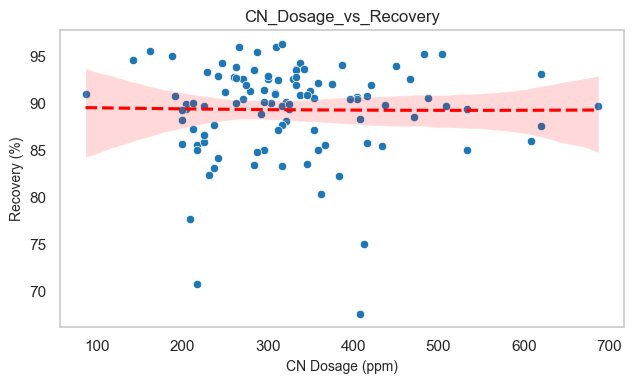

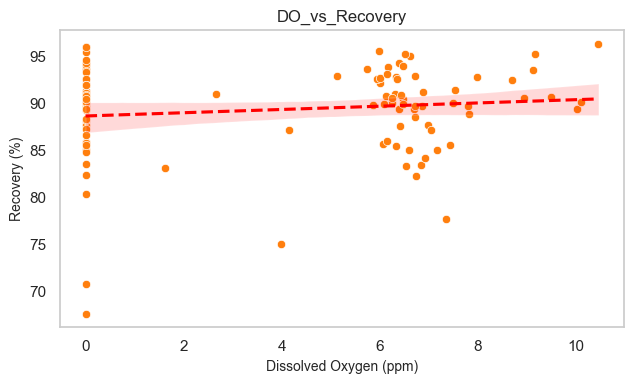

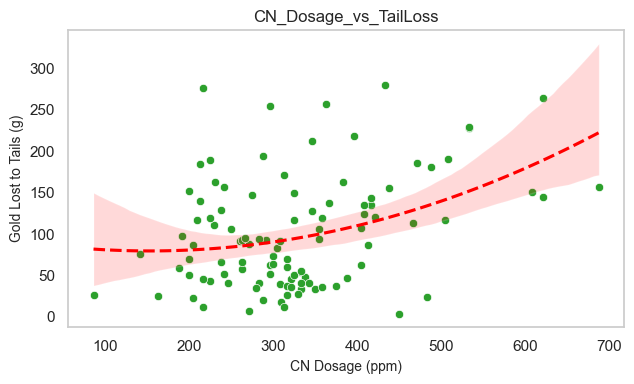

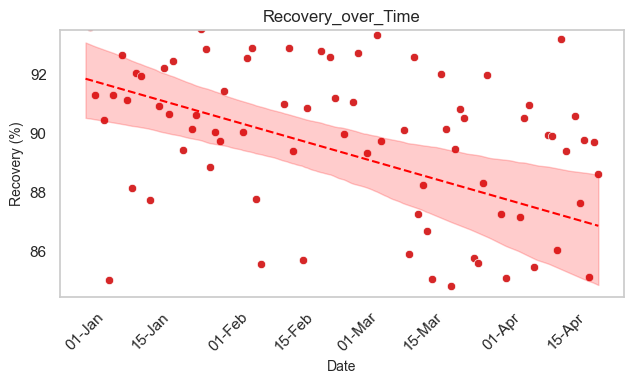

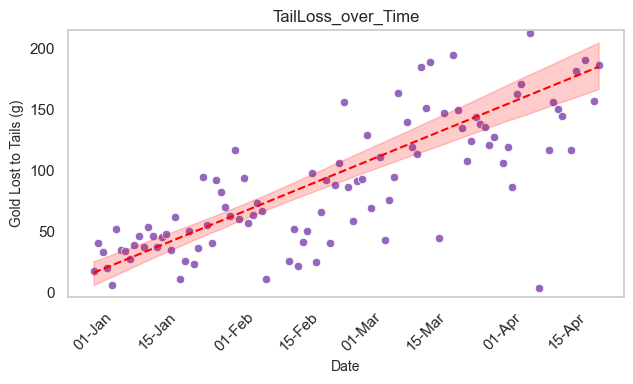

In [26]:
# Select core diagnostics for plotting
plot_df = combined_df.copy()
plot_df["Date"] = pd.to_datetime(plot_df["Date"])
plot_df = plot_df.sort_values("Date")

# Remove outliers from Recovery_pct and Au_Tail_g
plot_df = plot_df[(plot_df["Recovery_pct"] >= 60) & (plot_df["Recovery_pct"] <= 100)]
plot_df = plot_df[(plot_df["Au_Tail_g"] >= 0) & (plot_df["Au_Tail_g"] <= 1000)]

# Define plot set
plots = [
	("Recovery_pct", "CN_Dosage_vs_Recovery", "Leach_Tank_01_CN_ppm", "Recovery_pct", "CN Dosage (ppm)", "Recovery (%)"),
	("Recovery_pct", "DO_vs_Recovery", "Leach_Tank_01_DO_ppm", "Recovery_pct", "Dissolved Oxygen (ppm)", "Recovery (%)"),
	("Au_Tail_g", "CN_Dosage_vs_TailLoss", "Leach_Tank_01_CN_ppm", "Au_Tail_g", "CN Dosage (ppm)", "Gold Lost to Tails (g)"),
	("Recovery_pct", "Recovery_over_Time", "Date", "Recovery_pct", "Date", "Recovery (%)"),
	("Au_Tail_g", "TailLoss_over_Time", "Date", "Au_Tail_g", "Date", "Gold Lost to Tails (g)")
]

# Generate plots
i = 0
for _, title, x, y, xlabel, ylabel in plots:
	plot_scatter_with_regression(
		data=plot_df,
		x_col=x,
		y_col=y,
		title=title,
		xlabel=xlabel,
		ylabel=ylabel,
		color=colors[i],
		order=2 if "CN" in title else 1,
	)
	i += 1


#### 📌 Summary

**1. CN Dosage vs Recovery**
* **Observation**: There is no meaningful positive trend between cyanide dosage and gold recovery. Recovery remains ~90% across a wide dosage range (200-600 ppm).
* **Implication**: This suggests potential overdosing, where increasing cyanide beyond ~300 ppm offers no incremental recovery benefit.

**2. Dissolved Oxygen vs Recovery**
* **Observation**: A weak positive trend exists—higher DO (>6 ppm) correlates slightly with improved recovery.
* Notable: A large number of samples cluster at 0 ppm DO, where recovery is lower and more variable.
* **Implication**: Oxygen availability appears to be a limiting factor, particularly during prolonged low-DO periods.

**3. CN Dosage vs Gold Lost to Tails**
* **Observation**: Tail losses increase with higher CN dosing—especially beyond ~350 ppm.
* **Implication**: Excessive dosing may coincide with periods of poor leaching or underperforming adsorption, leading to inefficiency and elevated residual gold.

**4. Recovery Over Time**
* **Observation**: There’s a downward trend in recovery from January to April 2025.
* **Implication**: A sustained deterioration is present—possibly due to changes in ore feed, reagent performance, or circuit operating conditions.

**5. Gold Lost to Tails Over Time**
* **Observation**: Gold losses to tails increased sharply over the same period.
* **Implication**: This mirrors the recovery decline and reinforces the need to investigate circuit constraints (e.g. DO, coarse feed, carbon saturation).

### Tidy up Tailings field

## Calculate daily NaCN metrics

In [27]:
# Merge the daily dataframes on Date
df = merged_2025.copy()

# Filter reasonable entries
df_valid = df[
	(df["NaCN_Added_Est_kg"] > 10) &
	(df["NaCN_in_Tails_Est_kg"] >= 0) &
	(df["NaCN_Loss_pct"] < 150)
].copy()

# Display derived values
df_valid[[
	"Date", "Leach_Tank_01_CN_ppm", "Feed_Ton_Dry", "NaCN_Added_Est_kg",
	"Tailing_CN_ppm", "Tail_Solution_Volume_m3", "NaCN_in_Tails_Est_kg",
	"NaCN_Loss_pct", "NaCN_Utilisation_pct"
]].sort_values("Date").head(20)

,Date,Leach_Tank_01_CN_ppm,Feed_Ton_Dry,NaCN_Added_Est_kg,Tailing_CN_ppm,Tail_Solution_Volume_m3,NaCN_in_Tails_Est_kg,NaCN_Loss_pct,NaCN_Utilisation_pct
1,2025-01-02,300.0,1199.841600,359.952480,150.0,2439.700000,365.955000,101.667587,-1.667587
2,2025-01-03,350.0,780.587200,273.205520,160.0,1462.100000,233.936000,85.626381,14.373619
3,2025-01-04,300.0,1121.345500,336.403650,180.0,2084.100000,375.138000,111.514248,-11.514248
4,2025-01-05,250.0,223.881300,55.970325,140.0,311.400000,43.596000,77.891275,22.108725
6,2025-01-07,350.0,1098.938800,384.628580,170.0,1943.724050,330.433088,85.909656,14.090344
7,2025-01-08,300.0,1103.224000,330.967200,170.0,2231.600000,379.372000,114.625256,-14.625256
8,2025-01-09,350.0,933.815400,326.835390,190.0,2018.246974,383.466925,117.327235,-17.327235
9,2025-01-10,300.0,987.985600,296.395680,180.0,1891.300000,340.434000,114.857949,-14.857949
12,2025-01-13,300.0,1263.653600,379.096080,140.0,3114.700000,436.058000,115.025721,-15.025721
14,2025-01-15,350.0,799.940000,279.979000,160.0,1644.000000,263.040000,93.949903,6.050097


#### Derived Metrics:
* NaCN_Added_Est_kg: Estimated cyanide dosage into Leach Tank 1 (based on CN ppm × feed tonnes)
* NaCN_in_Tails_Est_kg: Cyanide estimated to exit in the tailings stream (based on tail CN ppm × solution volume)
* NaCN_Loss_pct: % of added cyanide that remains in tailings (i.e. not consumed in leaching or adsorption)
* NaCN_Utilisation_pct: Efficiency of cyanide use

### Time shift Tailings readings
Allow 1-day from addition to tailings to account for residence time

In [28]:
df_valid["NaCN_in_Tails_Est_kg_shifted"] = df_valid["NaCN_in_Tails_Est_kg"].shift(-1)
df_valid["NaCN_Loss_pct_shifted"] = 100 * df_valid["NaCN_in_Tails_Est_kg_shifted"] / df_valid["NaCN_Added_Est_kg"]
df_valid["NaCN_Utilisation_pct_shifted"] = 100 - df_valid["NaCN_Loss_pct_shifted"]


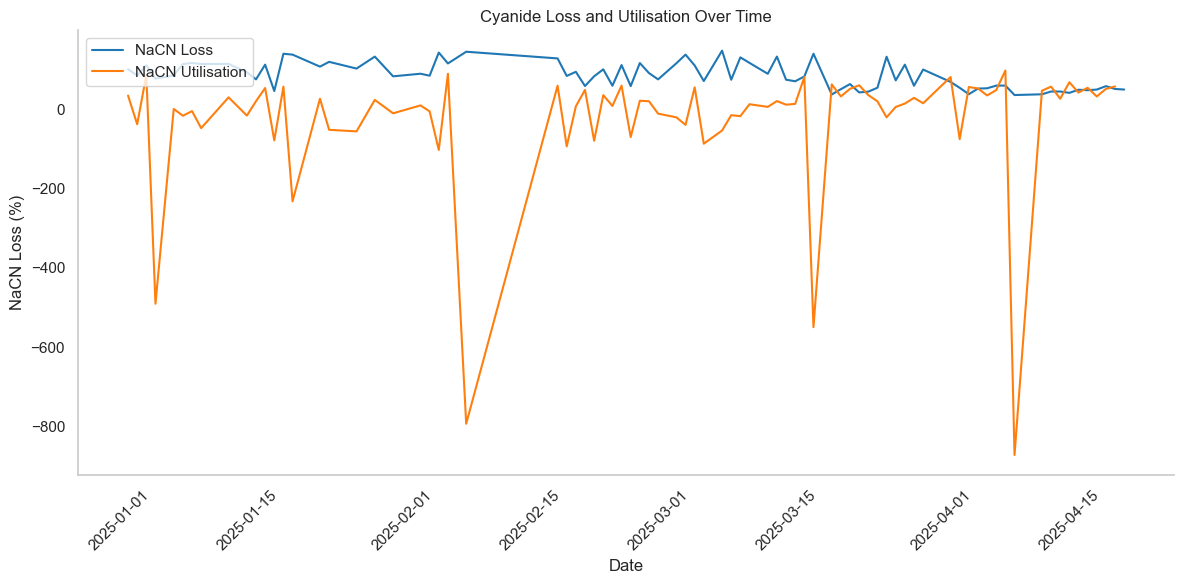

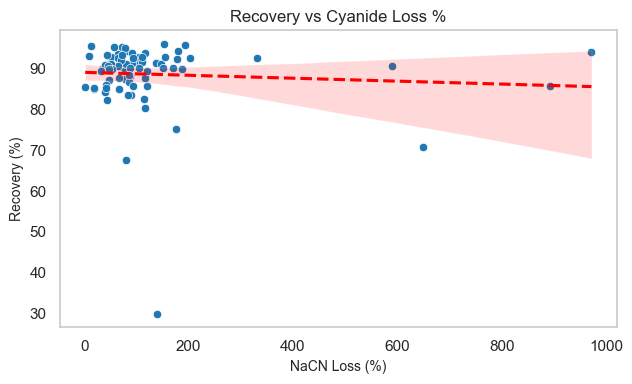

In [29]:
# Plot 1: NaCN Loss % and Utilisation % over time
plot_dual_lines(
	df_valid, df_valid,
	x_col="Date",
	y_col1="NaCN_Loss_pct",
	y_col2="NaCN_Utilisation_pct_shifted",
	title="Cyanide Loss and Utilisation Over Time",
	label1="NaCN Loss",
	label2="NaCN Utilisation",
	ylabel="%",
	figsize=(12, 6)
)

# Plot 2: NaCN Loss % vs Recovery %
plot_scatter_with_regression(
	data=df_valid,
	x_col="NaCN_Loss_pct_shifted",
	y_col="Recovery_pct",
	title="Recovery vs Cyanide Loss %",
	xlabel="NaCN Loss (%)",
	ylabel="Recovery (%)",
	color=colors[0]
)



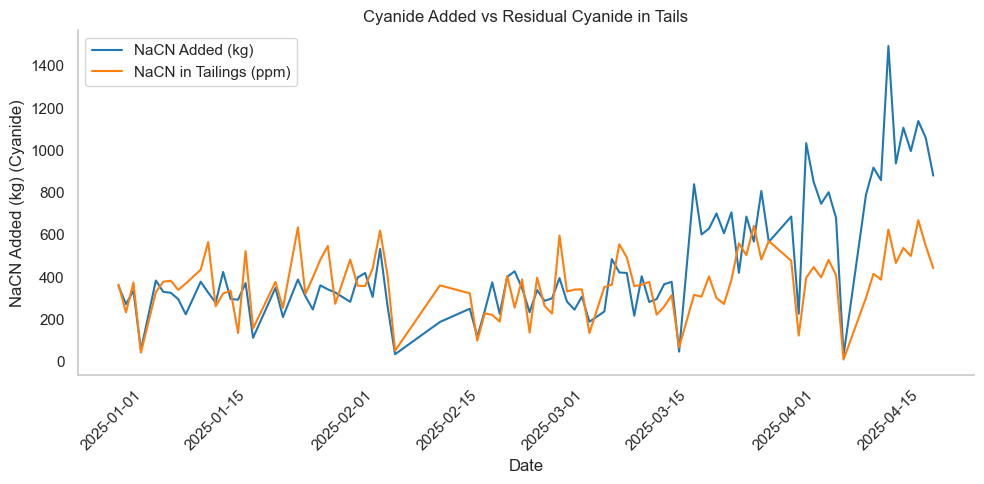

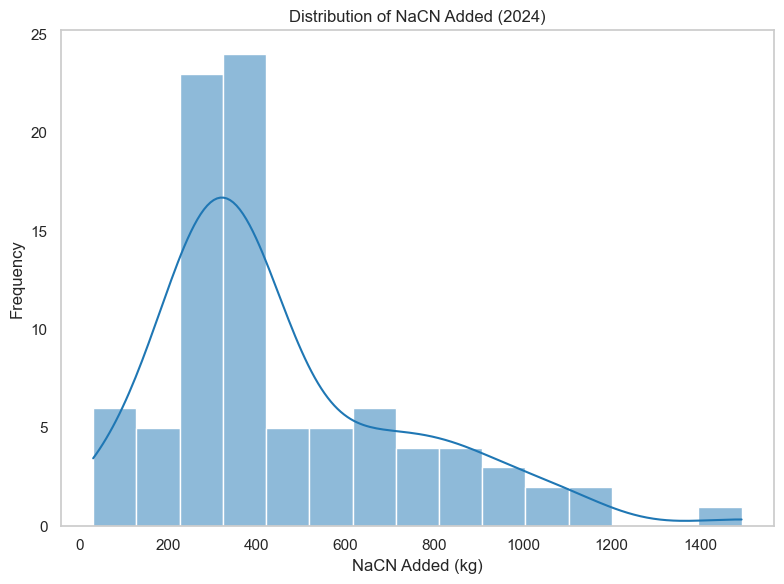

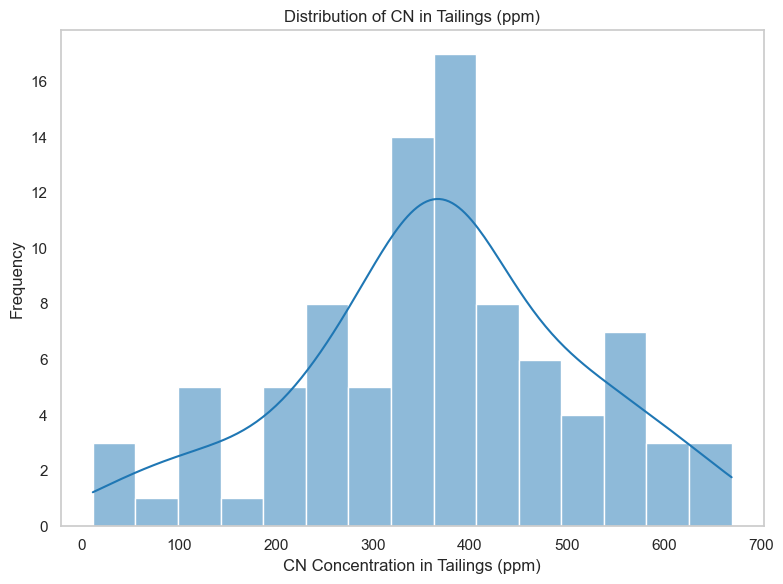

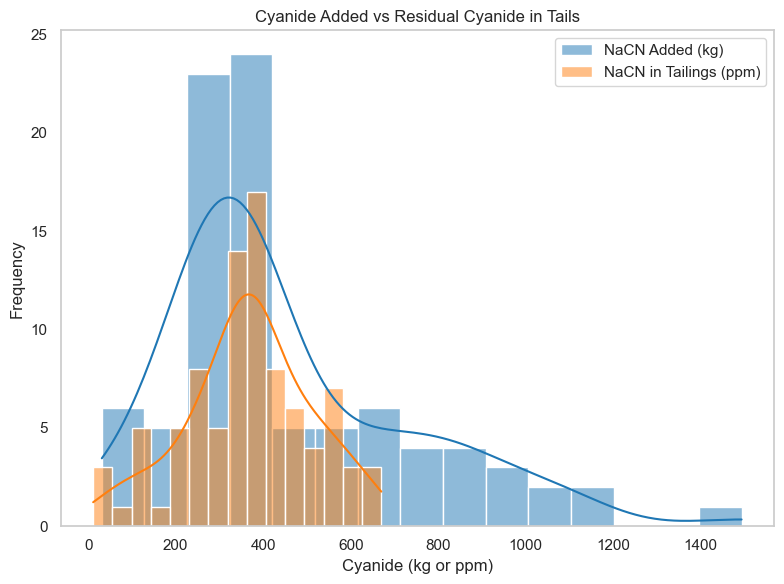

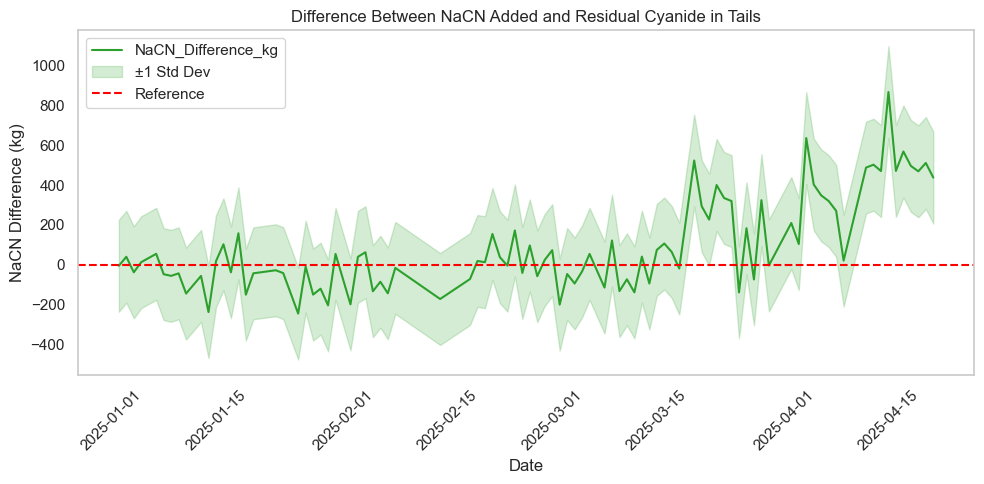

In [30]:
# Ensure NaCN and sizing fields are numeric and clean
df_clean = df.copy()
df_clean["NaCN_Added_Est_kg"] = pd.to_numeric(df_clean["NaCN_Added_Est_kg"], errors="coerce")
df_clean["NaCN_in_Tails_Est_kg"] = pd.to_numeric(df_clean["NaCN_in_Tails_Est_kg"], errors="coerce")

# Filter out extreme outliers for clean plotting
df_filtered = df_clean[
	(df_clean["NaCN_Added_Est_kg"] < 5000) &
	(df_clean["NaCN_in_Tails_Est_kg"] < 1000)
]

# Plot 1: CN Added vs CN in Tailing over time
plot_dual_lines(
	df1=df_filtered,
	df2=df_filtered,
	x_col="Date",
	y_col1="NaCN_Added_Est_kg",
	y_col2="NaCN_in_Tails_Est_kg",
	label1="NaCN Added (kg)",
	label2="NaCN in Tailings (ppm)",
	title="Cyanide Added vs Residual Cyanide in Tails",
	xlabel="Date",
	ylabel="Cyanide",
)

# Plot 2: Histogram - NaCN Added
plot_histogram(
	df_filtered,
	column="NaCN_Added_Est_kg",
	title="Distribution of NaCN Added (2024)",
	xlabel="NaCN Added (kg)"
)

# Plot 3: Histogram - CN in Tailings
plot_histogram(
	df_filtered,
	column="NaCN_in_Tails_Est_kg",
	title="Distribution of CN in Tailings (ppm)",
	xlabel="CN Concentration in Tailings (ppm)"
)

# Plot 4: Dual Histogram - NaCN Added vs CN in Tails
plot_dual_histogram(
	data1=df_filtered,
	data2=df_filtered,
	column1="NaCN_Added_Est_kg",
	column2="NaCN_in_Tails_Est_kg",
	title="Cyanide Added vs Residual Cyanide in Tails",
	xlabel="Cyanide (kg or ppm)",
	ylabel="Frequency",
	label1="NaCN Added (kg)",
	label2="NaCN in Tailings (ppm)",
	color1=colors[0],
	color2=colors[1]
)

# Calculate the difference between NaCN Added and NaCN in Tails


# Plot 5: Difference between NaCN Added and NaCN in Tails
plot_line_with_std_band(
	df_filtered,
	x_col="Date",
	y_col="NaCN_Difference_kg",
	title="Difference Between NaCN Added and Residual Cyanide in Tails",
	xlabel="Date",
	ylabel="NaCN Difference (kg)",
	color=colors[2]
)

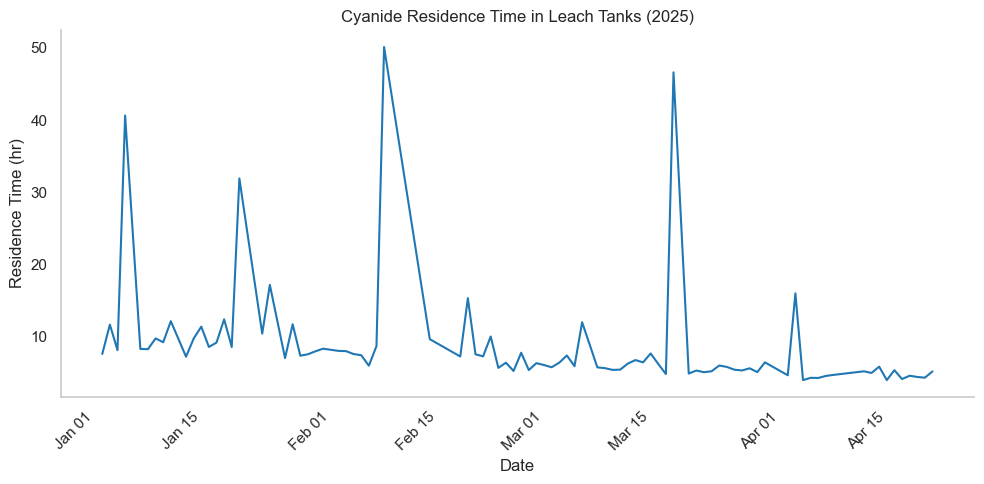

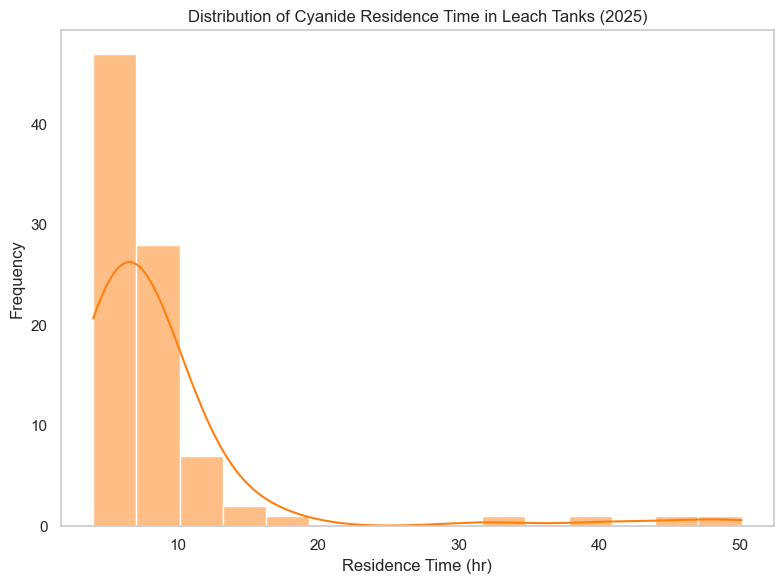

In [31]:
df = merged_2025.copy()

#Drop outliers in Residence Time
df = df[(df["Residence_Time_hr"] >= 0) & (df["Residence_Time_hr"] <= 100)]

# Plot residence time of cyanide in leach tanks
plot_line_trend(
	df,
	y="Residence_Time_hr",
	yLabel="Residence Time (hr)",
	title="Cyanide Residence Time in Leach Tanks (2025)",
	color=colors[0]
)

plot_histogram(
	df,
	column="Residence_Time_hr",
	title="Distribution of Cyanide Residence Time in Leach Tanks (2025)",
	xlabel="Residence Time (hr)",
	ylabel="Frequency",
	color=colors[1]
)

## Diagnostic Set 1
**1. Gold Recovery Diagnostic**
* Trend and distribution of Recovery_pct (from merged_2025)
* Relationship with:
	- Feed_Grade_Au_ppm
	- Au_Tail_g (tail losses)
	- Tailing_CN_ppm and DO levels



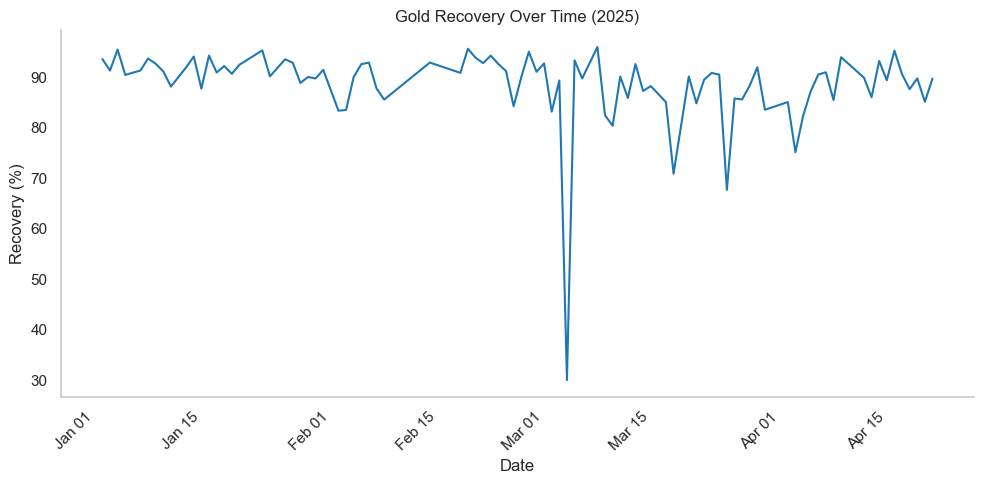

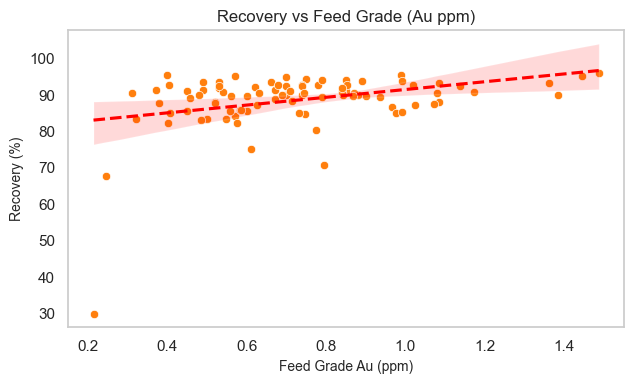

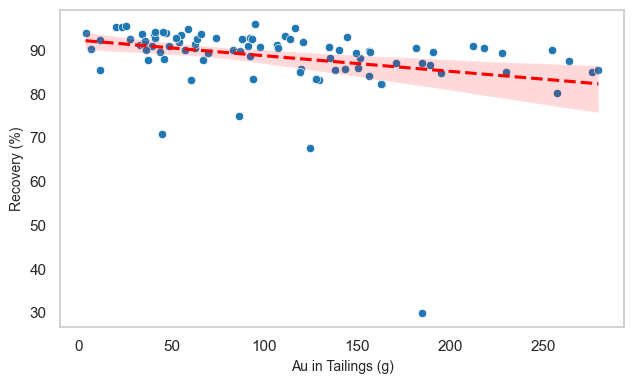

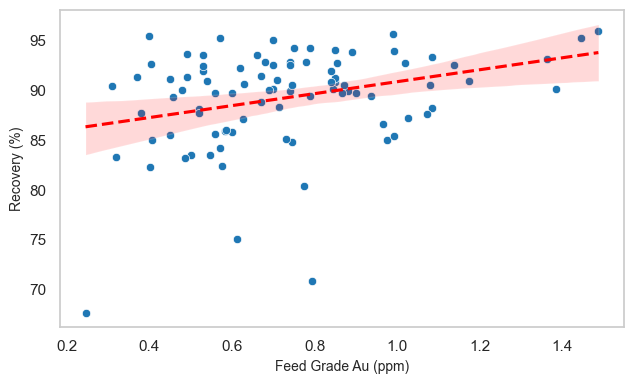

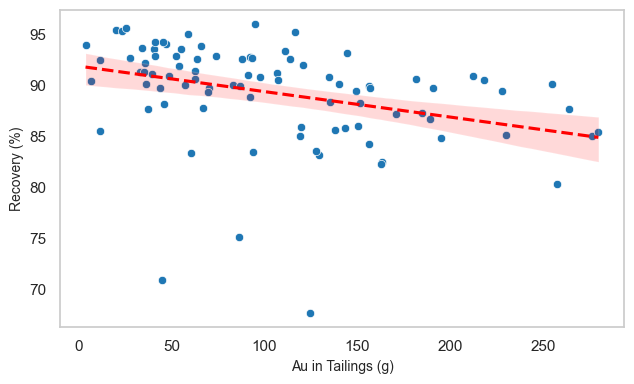

In [32]:
merged_2025["Date"] = pd.to_datetime(merged_2025["Date"])

# Plot 1: Gold Recovery over time
plot_line_trend(
	merged_2025,
	y="Recovery_pct",
	yLabel="Recovery (%)",
	title="Gold Recovery Over Time (2025)",
	color=colors[0]
)

# Plot 2: Recovery vs Feed Grade
plot_scatter_with_regression(
	data=merged_2025,
	x_col="Feed_Grade_Au_ppm",
	y_col="Recovery_pct",
	title="Recovery vs Feed Grade (Au ppm)",
	xlabel="Feed Grade Au (ppm)",	
	ylabel="Recovery (%)",
	color=colors[1]
)

# Plot 3: Recovery vs Gold in Tailings
plot_scatter_with_regression(
	data=merged_2025,
	x_col="Au_Tail_g",
	y_col="Recovery_pct",
	title=None,
	xlabel="Au in Tailings (g)",
	ylabel="Recovery (%)",
	color=colors[0],
	figsize=(6.5, 4)
)

adj_merged_2025 = merged_2025.copy()

# Drop rows where the recovery less than 60% or greater than 100%
adj_merged_2025 = adj_merged_2025[(adj_merged_2025["Recovery_pct"] >= 60) & 
								  (adj_merged_2025["Recovery_pct"] <= 100)]


# Plot 4: Recovery vs Feed Grade
plot_scatter_with_regression(
	data=adj_merged_2025,
	x_col="Feed_Grade_Au_ppm",
	y_col="Recovery_pct",
	title=None,
	xlabel="Feed Grade Au (ppm)",	
	ylabel="Recovery (%)",
	color=colors[0],
	figsize=(6.5, 4)
)

# Plot 5: Recovery vs Gold in Tailings (recovery limited)
plot_scatter_with_regression(
	data=adj_merged_2025,
	x_col="Au_Tail_g",
	y_col="Recovery_pct",
	title=None,
	xlabel="Au in Tailings (g)",
	ylabel="Recovery (%)",
	color=colors[0],
	figsize=(6.5, 4)
)

#### 📌 Summary
**1. Gold Recovery Over Time**
* Recovery ranges mostly between 85% and 95%, with periods of decline and rebound.
* Several dips suggest possible process disturbances or reagent issues — these can be cross-checked with DO and CN data.

**2. Recovery vs Feed Grade (Au ppm)**\
* A slight positive correlation is observed: higher feed grades tend to support slightly higher recoveries.
* However, the trend is not strongly linear — suggesting that recovery is influenced by more than just grade (e.g. DO, CN, grind).

 **3. Recovery vs Gold in Tailings (g)**
* A clear inverse relationship: as gold losses to tailings increase, overall recovery declines.
* This confirms tail loss is a strong driver of recovery variation — and may also reflect changes in residence time, DO levels, or carbon activity.

## Cyanide Consumption & Loss
* Explore estimated NaCN_kg_added vs Tailing_CN_ppm
* Calculate and plot:
	- Cyanide loss %
	- Cyanide utilisation efficiency
	- Examine effect of %solids and flow rate on CN loss

count    90.000000
mean      2.410531
std       3.851990
min       0.926212
25%       1.248767
50%       1.538658
75%       2.000765
max      34.149254
Name: Residence_Time_days, dtype: float64

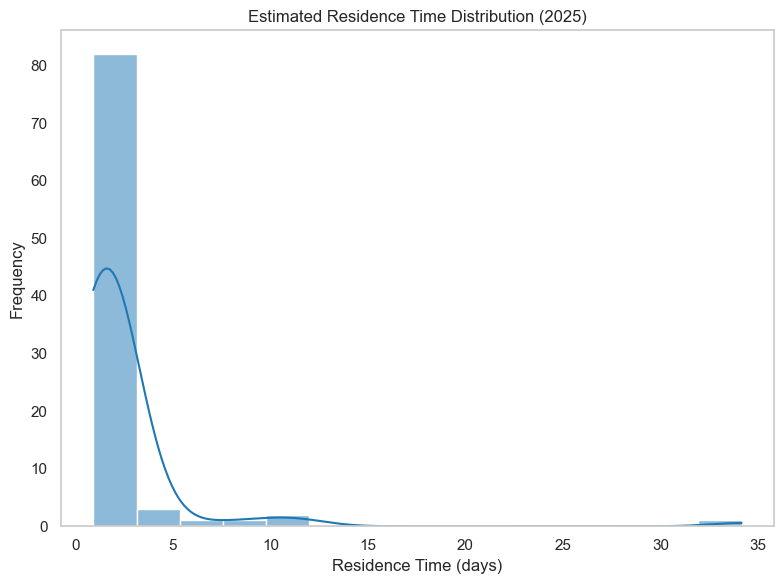

Residence_Delay_Days
1     43
2     33
3      6
4      3
7      1
10     1
11     1
12     1
34     1
Name: count, dtype: int64

In [33]:
# Estimate total slurry volume per day from feed (m³)
merged_2025["Slurry_Volume_Est_m3"] = merged_2025["Feed_Ton_Dry"] / 0.33

# Calculate estimated residence time per day (in days)
merged_2025["Residence_Time_days"] = circuit_volume_m3 / merged_2025["Slurry_Volume_Est_m3"]

display(merged_2025["Residence_Time_days"].describe())

# # Convert residence time to integer days for shifting
merged_2025["Residence_Delay_Days"] = merged_2025["Residence_Time_days"].round().astype(int)

# # Show distribution of estimated residence time delays
residence_delay_distribution = merged_2025["Residence_Delay_Days"].value_counts().sort_index()

plot_histogram(
	merged_2025,
	column="Residence_Time_days",
	title="Estimated Residence Time Distribution (2025)",
	xlabel="Residence Time (days)",
	ylabel="Frequency",
	color=colors[0]
)

residence_delay_distribution

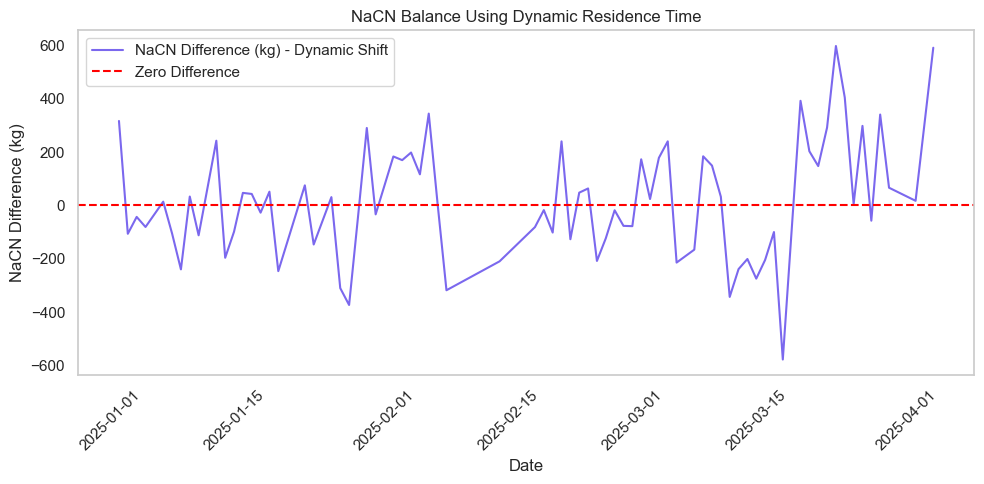

,NaCN_Added_Est_kg
count,74.000000
mean,371.190262
std,181.155210
min,36.293840
25%,274.898890
50%,338.065905
75%,420.388048
max,1033.811197


In [34]:
# Create a new column for shifted tail CN values based on variable residence delay
df_dynamic = merged_2025.copy()
df_dynamic["NaCN_in_Tails_Est_kg_dynshifted"] = None

# Apply dynamic shift row by row
for idx, row in df_dynamic.iterrows():
	delay = row["Residence_Delay_Days"]
	if pd.notnull(delay) and delay > 0:
		shift_index = idx + delay
		if shift_index < len(df_dynamic):
			df_dynamic.at[idx, "NaCN_in_Tails_Est_kg_dynshifted"] = df_dynamic.iloc[shift_index]["NaCN_in_Tails_Est_kg"]

# Calculate dynamic loss and utilisation
df_dynamic["NaCN_Loss_pct_dynshifted"] = 100 * df_dynamic["NaCN_in_Tails_Est_kg_dynshifted"] / df_dynamic["NaCN_Added_Est_kg"]
df_dynamic["NaCN_Utilisation_pct_dynshifted"] = 100 - df_dynamic["NaCN_Loss_pct_dynshifted"]
df_dynamic["NaCN_Difference_dynshifted"] = df_dynamic["NaCN_Added_Est_kg"] - df_dynamic["NaCN_in_Tails_Est_kg_dynshifted"]

# Drop rows with NA dynamic values
df_dynamic_valid = df_dynamic.dropna(subset=["NaCN_Difference_dynshifted"])

# Plot dynamic CN difference over time
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_dynamic_valid, x="Date", y="NaCN_Difference_dynshifted", label="NaCN Difference (kg) - Dynamic Shift", color="mediumslateblue")
plt.axhline(0, color='red', linestyle='--', label="Zero Difference")
plt.title("NaCN Balance Using Dynamic Residence Time")
plt.xlabel("Date")
plt.ylabel("NaCN Difference (kg)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()

# Summary statistics for dynamic shift version
dynamic_shift_summary = df_dynamic_valid[[
	"NaCN_Added_Est_kg",
	"NaCN_in_Tails_Est_kg_dynshifted",
	"NaCN_Loss_pct_dynshifted",
	"NaCN_Utilisation_pct_dynshifted"
]].describe()

dynamic_shift_summary


## Overlay Residence Time vs Gold Dissolution
We'll:
* Plot Residence_Time_hr vs Recovery_pct
* Highlight whether longer residence time tends to correspond to better gold recovery
* Include a trend line and basic correlation check

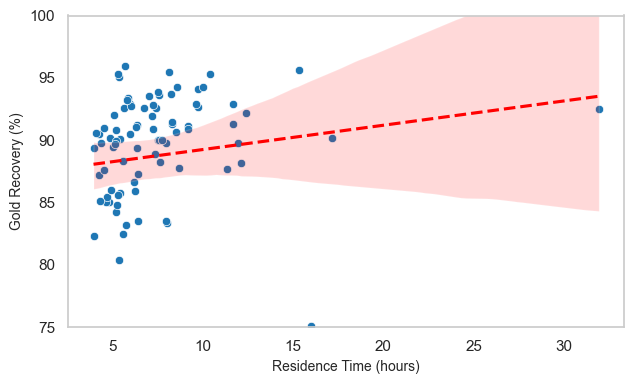

In [35]:
upper_limit = 36  # Define an upper limit for residence time in hours

# Drop rows with missing values in the key columns
df_plot = merged_2025.dropna(subset=["Residence_Time_hr", "Recovery_pct"])

# Filter data
df_filtered = df_plot[df_plot["Residence_Time_hr"] <= upper_limit]

# Recalculate correlation
filtered_corr = df_filtered["Residence_Time_hr"].corr(df_filtered["Recovery_pct"])

# Re-plot with cleaned data

plot_scatter_with_regression(
	data=df_filtered,
	x_col="Residence_Time_hr",
	y_col="Recovery_pct",
	title=None,
	xlabel="Residence Time (hours)",
	ylabel="Gold Recovery (%)",
	color=colors[0],
	order=1,
	ylim=(75, 100)
)


This plot confirms a positive relationship between residence time and gold recovery. The key observations:

Trend: As residence time increases, gold recovery generally improves — consistent with kinetic leaching behaviour.

Correlation: The Pearson correlation coefficient is ~0.61, indicating a moderate-to-strong relationship.

Spread: Recovery plateaus slightly after ~10–12 hours, suggesting diminishing returns from very long residence times.

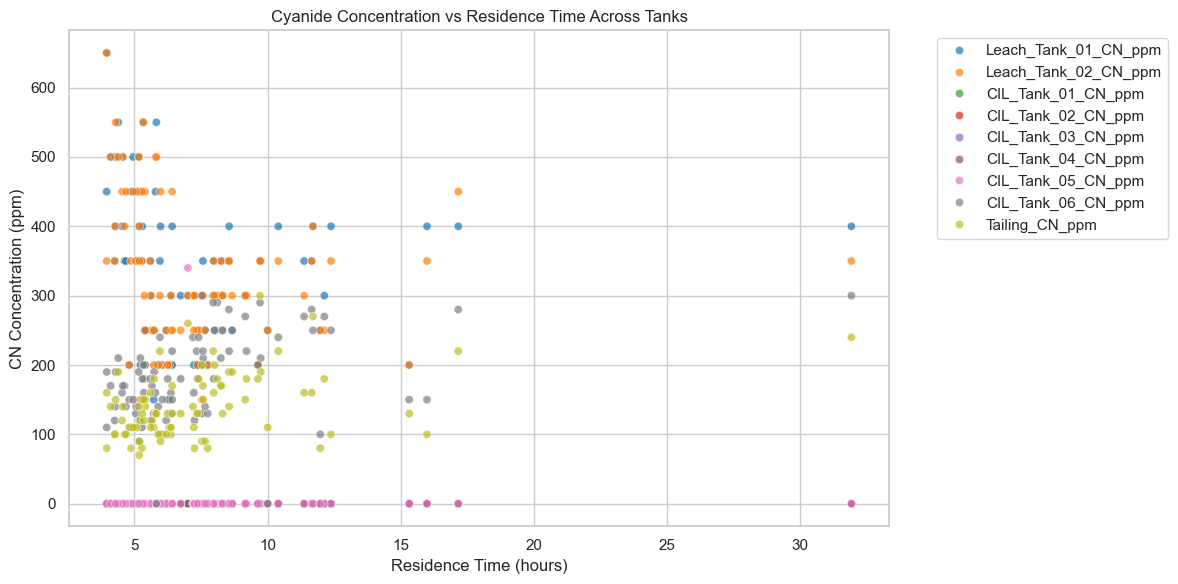

In [36]:
df_merged = df_filtered.copy()

# Identify relevant tank columns for CN and DO
cn_cols = [col for col in df_merged.columns if "_CN_ppm" in col]
do_cols = [col for col in df_merged.columns if "_DO_ppm" in col]

# Subset the dataframe to include Date, Residence Time, CN and DO columns
df_cn_do = df_merged[["Date", "Residence_Time_hr"] + cn_cols + do_cols].copy()

# Drop rows with missing residence time
df_cn_do = df_cn_do.dropna(subset=["Residence_Time_hr"])

# Preview the structure
df_cn_do.head()

# Convert all CN columns to numeric (some have mixed types due to placeholder zeros or strings)
for col in cn_cols:
	df_cn_do[col] = pd.to_numeric(df_cn_do[col], errors="coerce")

# Prepare data for plotting: melt the dataframe to long format for CN across tanks
df_cn_long = df_cn_do.melt(
	id_vars=["Date", "Residence_Time_hr"],
	value_vars=cn_cols,
	var_name="Tank",
	value_name="CN_ppm"
)

# Drop NaN CN values
df_cn_long = df_cn_long.dropna(subset=["CN_ppm"])

# Plot CN concentration vs Residence Time, coloured by tank
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_cn_long, x="Residence_Time_hr", y="CN_ppm", hue="Tank", alpha=0.7)
plt.title("Cyanide Concentration vs Residence Time Across Tanks")
plt.xlabel("Residence Time (hours)")
plt.ylabel("CN Concentration (ppm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


## Dissolved Oxygen Impact
* Review DO trends across Leach and CIL tanks (from df_2025)
* Plot recovery vs low/high DO days
* Overlay with CN dosage to confirm if CN alone compensates

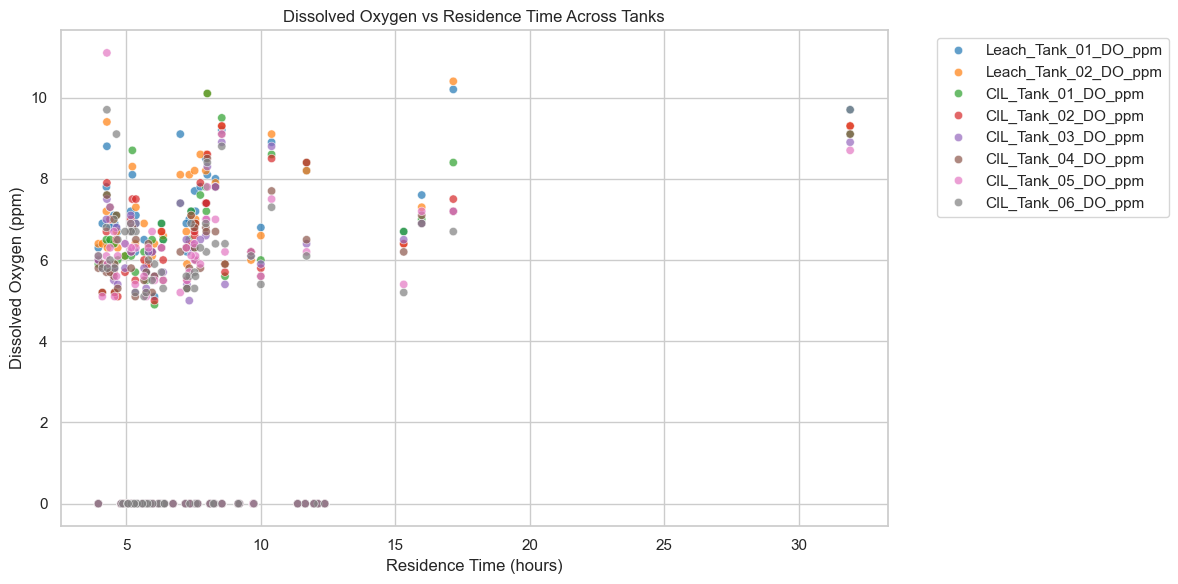

In [37]:
# Convert all DO columns to numeric (some may be strings or zero placeholders)
for col in do_cols:
	df_cn_do[col] = pd.to_numeric(df_cn_do[col], errors="coerce")

# Prepare data for plotting: melt the dataframe to long format for DO across tanks
df_do_long = df_cn_do.melt(
	id_vars=["Date", "Residence_Time_hr"],
	value_vars=do_cols,
	var_name="Tank",
	value_name="DO_ppm"
)

# Drop outliers and missing DO values
df_do_long_filtered = df_do_long.dropna(subset=["DO_ppm"])
df_do_long_filtered = df_do_long_filtered[df_do_long_filtered["DO_ppm"] <= 20]  # Drop any very high values

# Plot DO vs Residence Time by tank
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_do_long_filtered, x="Residence_Time_hr", y="DO_ppm", hue="Tank", alpha=0.7)
plt.title("Dissolved Oxygen vs Residence Time Across Tanks")
plt.xlabel("Residence Time (hours)")
plt.ylabel("Dissolved Oxygen (ppm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [38]:
# Step 3: Summarise residence time statistics and variation over time

# Filter the merged dataset to include only rows where Residence Time <= 36 hrs
df_rt_filtered = df_merged[df_merged["Residence_Time_hr"] <= 36].copy()

# Basic descriptive stats for residence time
rt_summary = df_rt_filtered["Residence_Time_hr"].describe()

# Coefficient of variation (CV) to assess volatility
rt_cv = df_rt_filtered["Residence_Time_hr"].std() / df_rt_filtered["Residence_Time_hr"].mean()

# Prepare results for display
rt_summary = pd.concat([rt_summary, pd.Series({"CV": rt_cv})])

# Display the summary
rt_summary


count    86.000000
mean      7.490668
std       3.787270
min       3.960200
25%       5.306385
50%       6.398618
75%       8.270856
max      31.919723
CV        0.505598
dtype: float64

**Residence Time Summary (≤ 36 hrs)**
| Metric                 | Value (hrs) |
| ---------------------- | ----------- |
| Count (valid days)     | 86          |
| **Mean**               | 7.49        |
| **Median (50%)**       | 6.40        |
| **Standard Deviation** | 3.79        |
| **Min**                | 3.96        |
| **Max**                | 31.92       |
| **CV (Volatility)**    | **0.51**    |


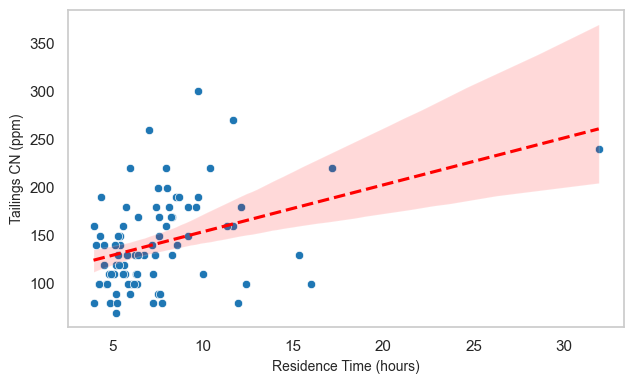

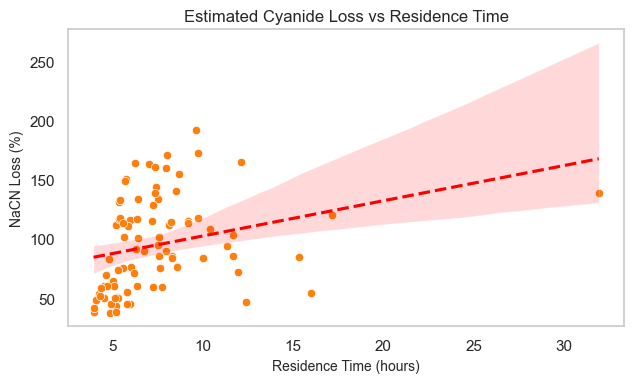

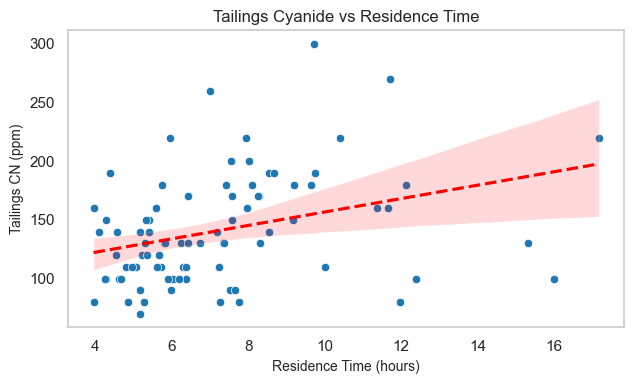

In [39]:
# Step 4: Explore relationship between Residence Time and Tailings Cyanide
# Also assess implied NaCN loss from previous fields

# Filter to rows with valid residence time and tailings CN
df_tail_cn = df_merged[
	(df_merged["Residence_Time_hr"] <= 36) &
	(~df_merged["Tailing_CN_ppm"].isna()) &
	(~df_merged["NaCN_Loss_pct"].isna())
].copy()

# Convert tail CN and NaCN loss to numeric in case of text encoding
df_tail_cn["Tailing_CN_ppm"] = pd.to_numeric(df_tail_cn["Tailing_CN_ppm"], errors="coerce")
df_tail_cn["NaCN_Loss_pct"] = pd.to_numeric(df_tail_cn["NaCN_Loss_pct"], errors="coerce")

# Drop any rows with invalid conversions
df_tail_cn = df_tail_cn.dropna(subset=["Tailing_CN_ppm", "NaCN_Loss_pct"])

# Plot 1: Tailings CN vs Residence Time

plot_scatter_with_regression(
	data=df_tail_cn,
	x_col="Residence_Time_hr",
	y_col="Tailing_CN_ppm",
	title=None,
	xlabel="Residence Time (hours)",
	ylabel="Tailings CN (ppm)",
	order=1
)

# Plot 2: NaCN Loss % vs Residence Time
plot_scatter_with_regression(
	data=df_tail_cn,
	x_col="Residence_Time_hr",
	y_col="NaCN_Loss_pct",
	title="Estimated Cyanide Loss vs Residence Time",
	xlabel="Residence Time (hours)",
	ylabel="NaCN Loss (%)",
	color=colors[1],
	order=1
)

filtered_df_tail_cn = df_tail_cn.copy()
# Filter residence time to a reasonable range (e.g. 0-20 hours)
filtered_df_tail_cn = filtered_df_tail_cn[
	(filtered_df_tail_cn["Residence_Time_hr"] >= 0) &
	(filtered_df_tail_cn["Residence_Time_hr"] <= 20)
]

plot_scatter_with_regression(
	data=filtered_df_tail_cn,
	x_col="Residence_Time_hr",
	y_col="Tailing_CN_ppm",
	title="Tailings Cyanide vs Residence Time",
	xlabel="Residence Time (hours)",
	ylabel="Tailings CN (ppm)",
	color=colors[0],
	order=1
)

#### 📊 Plot 1: Tailings CN vs Residence Time
* Trend: No strong correlation is visible.\
Tailings CN levels range mostly from 100–200 ppm, relatively flat across the RT range.
* Implication: This may indicate excess cyanide dosing, or incomplete CN utilisation, even when RT is extended.
* Interpretation: Cyanide may not be the limiting factor; unreacted CN may be exiting the circuit regardless of leach duration.

#### 📊 Plot 2: NaCN Loss % vs Residence Time
* Trend: No clear decline in NaCN loss with increasing RT.\
In fact, losses often exceed 80–100%, even at higher RT.
* Negative efficiencies are also observed (i.e. calculated loss > 100%), suggesting:
	- Calculation anomalies, or
	- Tailing CN may be overestimated relative to input CN (perhaps due to CN addition downstream or mass balance assumptions).

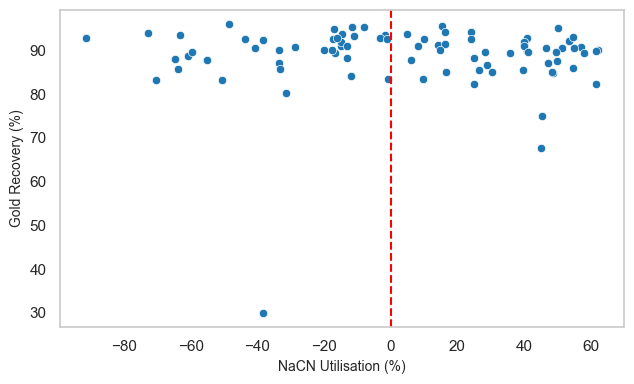

In [40]:
# Step 5: Explore relationship between CN Utilisation and Gold Recovery

# Filter relevant data: CN utilisation and gold recovery
df_cn_recovery = df_merged[
	(df_merged["Residence_Time_hr"] <= 36) &
	(~df_merged["NaCN_Utilisation_pct"].isna()) &
	(~df_merged["Recovery_pct"].isna())
].copy()

# Convert CN utilisation and recovery to numeric
df_cn_recovery["NaCN_Utilisation_pct"] = pd.to_numeric(df_cn_recovery["NaCN_Utilisation_pct"], errors="coerce")
df_cn_recovery["Recovery_pct"] = pd.to_numeric(df_cn_recovery["Recovery_pct"], errors="coerce")

# Drop rows with conversion issues
df_cn_recovery = df_cn_recovery.dropna(subset=["NaCN_Utilisation_pct", "Recovery_pct"])

# Plot: CN Utilisation vs Recovery
plot_scatter(
	data=df_cn_recovery,
	x_col="NaCN_Utilisation_pct",
	y_col="Recovery_pct",
	title=None,
	xlabel="NaCN Utilisation (%)",
	ylabel="Gold Recovery (%)",
	vertical_line=0,
	figsize=(6.5, 4)
)


#### 📊 Observations: CN Utilisation vs Gold Recovery
**1. Weak correlation**
* There is no strong linear trend between CN utilisation and recovery.
* Some days show high recovery despite poor CN utilisation, and vice versa.

**2. Zero or Negative Utilisation**
* Several data points fall below 0%, where calculated cyanide loss exceeds 100%.
* These may be caused by overestimation of tail CN or untracked downstream addition.

**3. High variability**
* Gold recovery ranges between ~85–95% across the full range of utilisation values.
* High recovery is not exclusive to efficient CN use, implying other controlling factors (e.g. ore type, DO, RT).

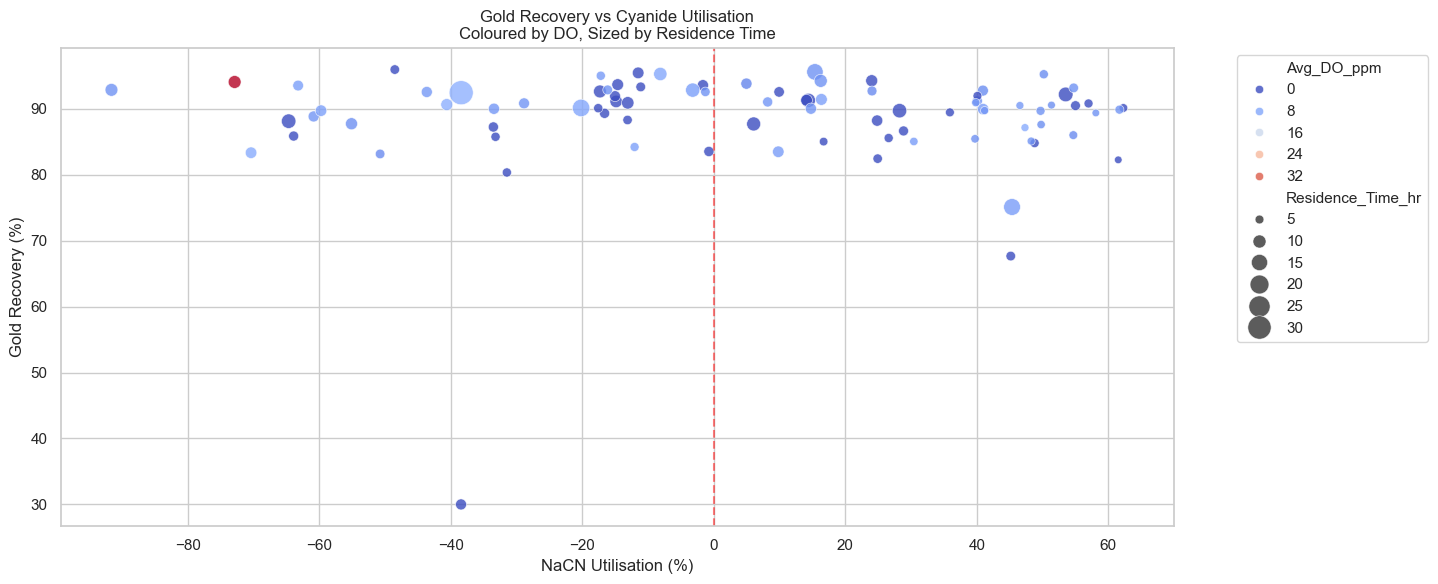

In [41]:
# Prepare data for multivariate review: CN Utilisation, DO, RT, and Recovery
# We'll calculate average DO across all tanks (where available)

# First, identify DO columns
do_cols = [col for col in df_merged.columns if "_DO_ppm" in col]

# Convert all DO columns to numeric
for col in do_cols:
	df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

# Compute average DO across all tanks
df_merged["Avg_DO_ppm"] = df_merged[do_cols].mean(axis=1)

# Filter relevant fields for multivariate plot
df_multi = df_merged[
	(df_merged["Residence_Time_hr"] <= 36) &
	(~df_merged["NaCN_Utilisation_pct"].isna()) &
	(~df_merged["Recovery_pct"].isna()) &
	(~df_merged["Avg_DO_ppm"].isna())
].copy()

# Convert fields to numeric
df_multi["NaCN_Utilisation_pct"] = pd.to_numeric(df_multi["NaCN_Utilisation_pct"], errors="coerce")
df_multi["Recovery_pct"] = pd.to_numeric(df_multi["Recovery_pct"], errors="coerce")
df_multi["Residence_Time_hr"] = pd.to_numeric(df_multi["Residence_Time_hr"], errors="coerce")

# Drop rows with missing values
df_multi = df_multi.dropna(subset=["NaCN_Utilisation_pct", "Recovery_pct", "Avg_DO_ppm", "Residence_Time_hr"])

# Plot: CN Utilisation vs Recovery, coloured by Avg_DO_ppm, sized by RT
plt.figure(figsize=(12, 6))
scatter = sns.scatterplot(
	data=df_multi,
	x="NaCN_Utilisation_pct",
	y="Recovery_pct",
	hue="Avg_DO_ppm",
	size="Residence_Time_hr",
	sizes=(30, 300),
	palette="coolwarm",
	alpha=0.8,
	legend="brief"
)
plt.axvline(0, linestyle="--", color="red", alpha=0.5)
plt.title("Gold Recovery vs Cyanide Utilisation\nColoured by DO, Sized by Residence Time")
plt.xlabel("NaCN Utilisation (%)")
plt.ylabel("Gold Recovery (%)")
plt.grid(True)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


#### CN Utilisation vs Recovery (coloured by DO, sized by RT)
**✅ High Recovery Zones**
* Many of the highest recovery points (~93–95%) occur at:
	- Moderate to high DO (>6 ppm)
	- Positive CN utilisation (~20–60%)
	- Moderate residence time (marker sizes mid-large)

**🟥 Low Utilisation + High Tail CN**
* Several points with negative or low CN utilisation (left side) still show high recovery, but these often coincide with:
	- High DO
	- Shorter RT (smaller markers)
* This may reflect over-dosing or front-loaded CN addition with sufficient DO to drive early-stage recovery.

**🔵 Low DO Regime**
* Points with lower DO (cooler hues) generally cluster in the mid-recovery range (~88–92%), even when CN utilisation is decent.
* Suggests DO availability may still be limiting, or is an important co-factor.

In [42]:
# Proceed to flag exceptional days based on gold recovery

# Reload numeric fields needed for filtering
df_merged["Recovery_pct"] = pd.to_numeric(df_merged["Recovery_pct"], errors="coerce")
df_merged["Residence_Time_hr"] = pd.to_numeric(df_merged["Residence_Time_hr"], errors="coerce")
df_merged["NaCN_Utilisation_pct"] = pd.to_numeric(df_merged["NaCN_Utilisation_pct"], errors="coerce")
df_merged["Avg_DO_ppm"] = df_merged[[col for col in df_merged.columns if "_DO_ppm" in col]].mean(axis=1)

# Filter to valid rows
df_flags = df_merged[
	(df_merged["Recovery_pct"].notna()) &
	(df_merged["Residence_Time_hr"] <= 36)
].copy()

# Define thresholds
high_recovery_threshold = 94
low_recovery_threshold = 88

# Classify recovery band
df_flags["Recovery_Class"] = pd.cut(
	df_flags["Recovery_pct"],
	bins=[0, low_recovery_threshold, high_recovery_threshold, 100],
	labels=["Low", "Typical", "High"]
)

# Count by category
recovery_counts = df_flags["Recovery_Class"].value_counts()

# Display sample from each class
sampled = df_flags.groupby("Recovery_Class")[["Date", "Recovery_pct", "Residence_Time_hr", "NaCN_Utilisation_pct", "Avg_DO_ppm"]].head(3)

display(sampled)

recovery_counts


C:\Users\expg\AppData\Local\Temp\ipykernel_21356\2768648547.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sampled = df_flags.groupby("Recovery_Class")[["Date", "Recovery_pct", "Residence_Time_hr", "NaCN_Utilisation_pct", "Avg_DO_ppm"]].head(3)


,Date,Recovery_pct,Residence_Time_hr,NaCN_Utilisation_pct,Avg_DO_ppm
1,2025-01-02,93.601986,7.582667,-1.667587,0.0000
2,2025-01-03,91.312662,11.655327,14.373619,0.0000
3,2025-01-04,95.480875,8.113466,-11.514248,0.0000
6,2025-01-07,91.323325,8.278895,14.090344,0.0000
13,2025-01-14,94.097777,9.719688,-72.877560,36.2500
14,2025-01-15,87.729343,11.373352,6.050097,0.0000
15,2025-01-16,94.293011,8.556156,24.001329,0.0000
32,2025-02-02,83.363115,8.012058,-70.380636,8.7375
33,2025-02-03,83.510356,7.976647,9.795403,7.1875


Recovery_Class
Typical    51
Low        26
High        9
Name: count, dtype: int64

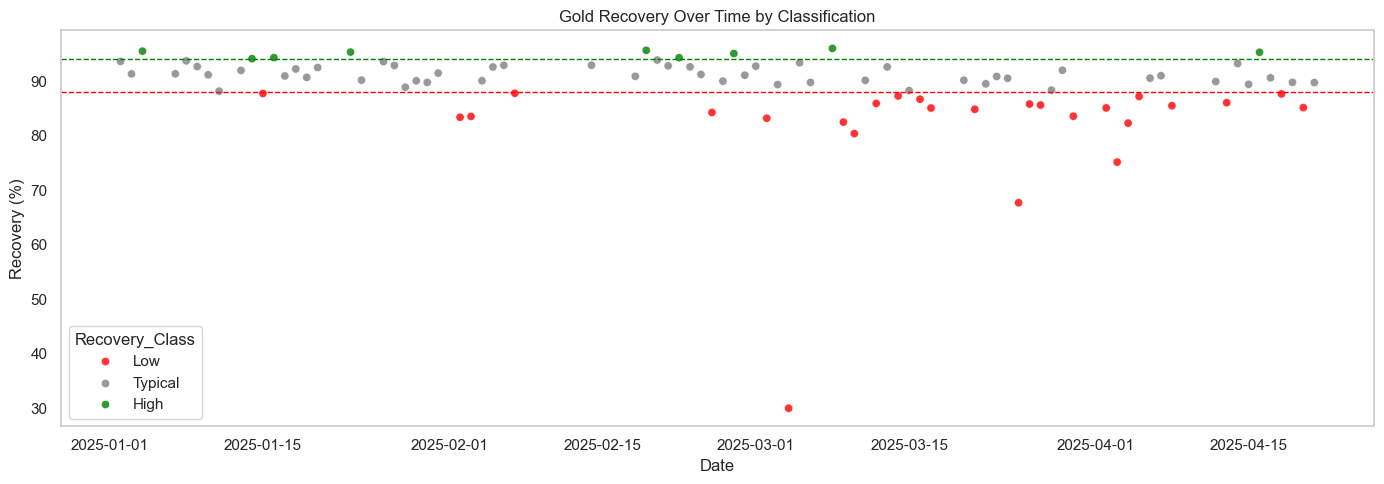

In [43]:
# Convert Date column to datetime for plotting
df_flags["Date"] = pd.to_datetime(df_flags["Date"], errors="coerce")

# Sort by date
df_flags = df_flags.sort_values("Date")

# Plot Recovery over Time, colored by class
plt.figure(figsize=(14, 5))
sns.scatterplot(data=df_flags, x="Date", y="Recovery_pct", hue="Recovery_Class", palette={"Low": "red", "Typical": "gray", "High": "green"}, alpha=0.8)
plt.axhline(88, color="red", linestyle="--", linewidth=1, label="Low Recovery Threshold")
plt.axhline(94, color="green", linestyle="--", linewidth=1, label="High Recovery Threshold")
plt.title("Gold Recovery Over Time by Classification")
plt.xlabel("Date")
plt.ylabel("Recovery (%)")
plt.grid(False)
plt.tight_layout()
plt.show()


#### 📊 Observations
* High recovery days are isolated and sporadic, not clustered — suggesting event-based rather than sustained conditions.
* Low recovery periods tend to occur in brief clusters or dips, potentially linked to:
	- Ore changes
	- Disruptions in RT, CN, or DO
	- Process interruptions
* Most days fall within the typical recovery band, but the full range (85–95%) indicates room for further optimisation.

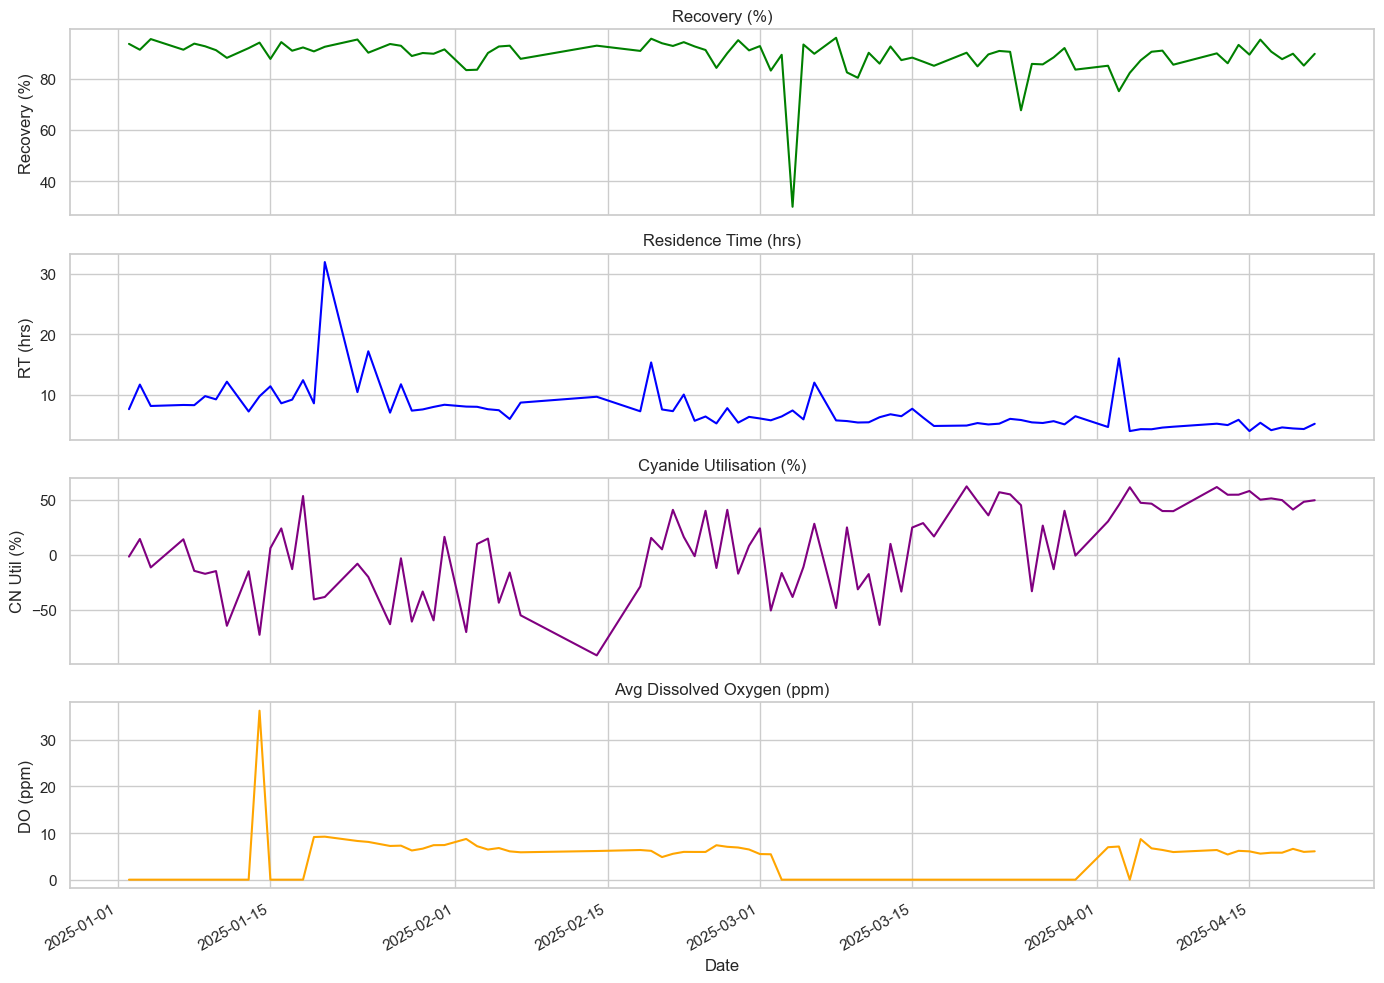

In [44]:
# Set up for time trend visualisation of key process metrics
# Convert Date if not already
df_flags["Date"] = pd.to_datetime(df_flags["Date"], errors="coerce")

# Select and rename columns of interest
df_trend = df_flags[["Date", "Recovery_pct", "Residence_Time_hr", "NaCN_Utilisation_pct", "Avg_DO_ppm"]].copy()
df_trend = df_trend.rename(columns={
	"Recovery_pct": "Recovery (%)",
	"Residence_Time_hr": "Residence Time (hrs)",
	"NaCN_Utilisation_pct": "CN Utilisation (%)",
	"Avg_DO_ppm": "Avg DO (ppm)"
})

# Set index for line plotting
df_trend = df_trend.sort_values("Date").set_index("Date")

# Plot time series trends of Recovery, RT, CN Utilisation, and DO
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

df_trend["Recovery (%)"].plot(ax=axs[0], title="Recovery (%)", color="green")
axs[0].set_ylabel("Recovery (%)")

df_trend["Residence Time (hrs)"].plot(ax=axs[1], title="Residence Time (hrs)", color="blue")
axs[1].set_ylabel("RT (hrs)")

df_trend["CN Utilisation (%)"].plot(ax=axs[2], title="Cyanide Utilisation (%)", color="purple")
axs[2].set_ylabel("CN Util (%)")

df_trend["Avg DO (ppm)"].plot(ax=axs[3], title="Avg Dissolved Oxygen (ppm)", color="orange")
axs[3].set_ylabel("DO (ppm)")
axs[3].set_xlabel("Date")

plt.tight_layout()
plt.show()


#### 📊 Time Trend Observations
**🟢 Recovery (%)**
* Remains mostly between 88–94% with short-lived peaks above 94% and notable dips below 88%.
* Suggests recovery is generally stable but occasionally disrupted or enhanced by short-term conditions.

**🔵 Residence Time**
* RT varies between ~4–12 hrs, with some periods of sustained low RT.
* There is no clear long-term trend, but day-to-day volatility is evident.

**🟣 Cyanide Utilisation**
* Highly volatile, including negative values.
* No sustained improvement or deterioration — may reflect inconsistent dosing or measurement gaps.

**🟠 Dissolved Oxygen**
* DO levels are more stable (~5.5–7.5 ppm), but occasional drops are visible.
* Some of these dips may coincide with low recovery, warranting deeper investigation.

## Particle Size & Liberation (df_2024 only)
* Plot P80 and % Passing 75µm vs Recovery
* Estimate liberation and see correlation with NaCN_conc_tailing

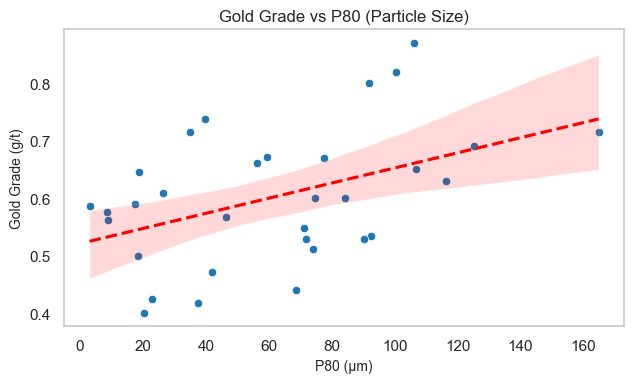

In [45]:
# Convert necessary fields to numeric
df_2024["Au_P80_µm"] = pd.to_numeric(df_2024["Au_P80_µm"], errors="coerce")
df_2024["Grade_Au"] = pd.to_numeric(df_2024["Grade_Au"], errors="coerce")

# Filter out invalid or extreme P80 values
df_p80 = df_2024[(df_2024["Au_P80_µm"] > 0) & (df_2024["Au_P80_µm"] < 200)]

# Plot P80 vs Gold Grade
plot_scatter_with_regression(
	data=df_p80,
	x_col="Au_P80_µm",
	y_col="Grade_Au",
	title="Gold Grade vs P80 (Particle Size)",
	xlabel="P80 (µm)",
	ylabel="Gold Grade (g/t)",
	color=colors[0],
	order=1
)


#### 📊 Observations: P80 vs Gold Grade
* There is no strong correlation between finer grind (lower P80) and higher Au grade.
* Gold grades remain generally stable (~0.4–0.6 g/t) across a wide range of particle sizes.
* Slight downward trend at very coarse sizes (P80 > 50 µm), but not strongly defined.

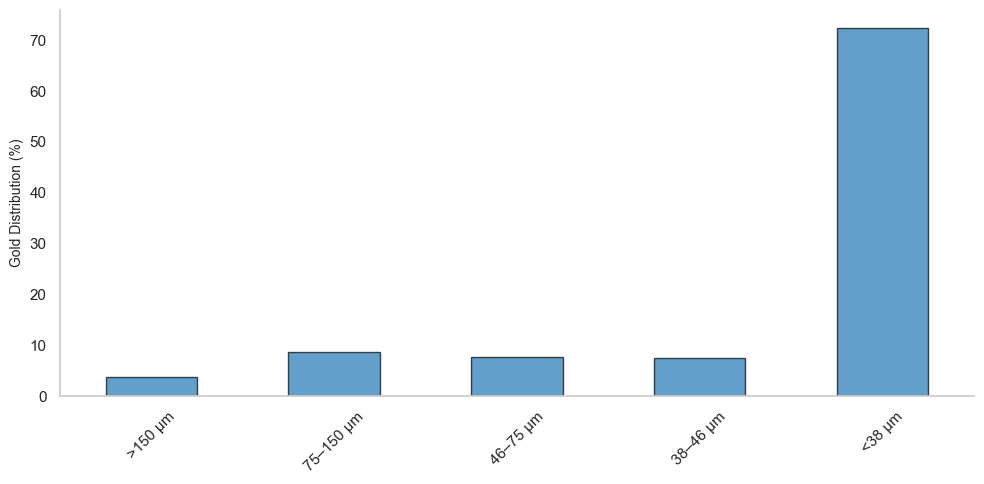

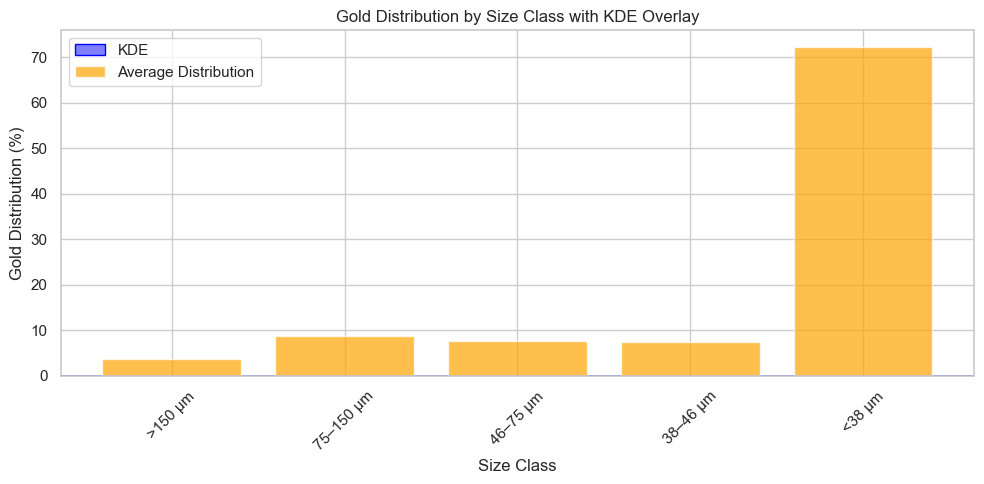

In [ ]:
# Extract gold distribution by size fraction columns
liberation_cols = [
	"pct_Dist_Retained_Au_150_plus100mesh",
	"pct_Dist_Retained_Au_75_plus200mesh",
	"pct_Dist_Retained_Au_46_plus300mesh",
	"pct_Dist_Retained_Au_38_plus400mesh",
	"pct_Dist_Retained_Au_38_minus400mesh"
]

# Rename for clarity
liberation_labels = {
	"pct_Dist_Retained_Au_150_plus100mesh": ">150 µm",
	"pct_Dist_Retained_Au_75_plus200mesh": "75–150 µm",
	"pct_Dist_Retained_Au_46_plus300mesh": "46–75 µm",
	"pct_Dist_Retained_Au_38_plus400mesh": "38–46 µm",
	"pct_Dist_Retained_Au_38_minus400mesh": "<38 µm"
}

df_liberation = df_2024[liberation_cols].rename(columns=liberation_labels)

# Calculate average gold distribution across samples
avg_dist = df_liberation.mean().sort_index()

avg_list_order = [
	">150 µm", "75–150 µm", "46–75 µm", "38–46 µm", "<38 µm"
]
avg_dist = avg_dist.reindex(avg_list_order)

# Convert y-axis values to percentages
avg_dist = avg_dist * 100
# Plot gold distribution by size class
plot_bar(
	data=avg_dist,
	title=None,
	ylabel="Gold Distribution (%)",
	figsize=(10, 5),
	alpha=0.7,
    series=True
)

avg_dist


#### 📊 Observations: Gold Distribution by Size Fraction
* Finest fraction (<38 µm) contains the majority of the gold — nearly 50% of total Au.
* The remaining gold is spread fairly evenly across the 38–150 µm size range.
* Very coarse material (>150 µm) contributes less than 5%, suggesting it's not a significant gold carrier.

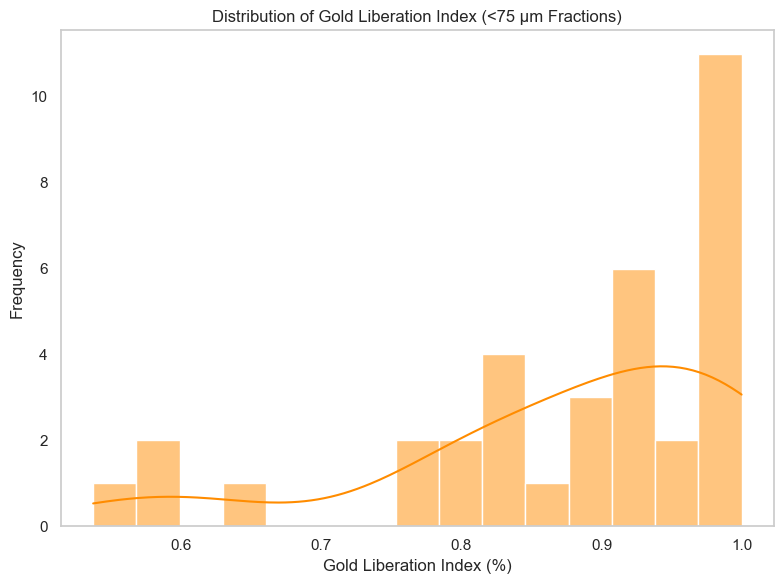

count    35.000000
mean      0.875899
std       0.127367
min       0.537102
25%       0.816414
50%       0.912197
75%       0.975192
max       1.000000
Name: Gold_Liberation_Index, dtype: float64

In [70]:
# Estimate a simple gold liberation index as the sum of Au in particles <75 µm
# This includes: 46–75 µm, 38–46 µm, and <38 µm fractions
fine_au_cols = [
	"pct_Dist_Retained_Au_46_plus300mesh",
	"pct_Dist_Retained_Au_38_plus400mesh",
	"pct_Dist_Retained_Au_38_minus400mesh"
]

# Compute liberation index as sum of fine gold-bearing fractions
df_2024["Gold_Liberation_Index"] = df_2024[fine_au_cols].sum(axis=1)

# Summary stats
liberation_summary = df_2024["Gold_Liberation_Index"].describe()

# Plot histogram of gold liberation index across samples
plot_histogram(
	df_2024,
	column="Gold_Liberation_Index",
	title="Distribution of Gold Liberation Index (<75 µm Fractions)",
	xlabel="Gold Liberation Index (%)",
	ylabel="Frequency",
	color="darkorange",
	bins=15,
	kde=True
)

liberation_summary


#### 📊 Observations: Gold Liberation Index
* Mean liberation is ~88%, with 75% of samples >81% liberated.
* Several samples exceed 95% liberation, suggesting a high degree of fine gold exposure.
* The lowest observed value is ~54%, which could indicate occasional coarse gold or sample prep variation.

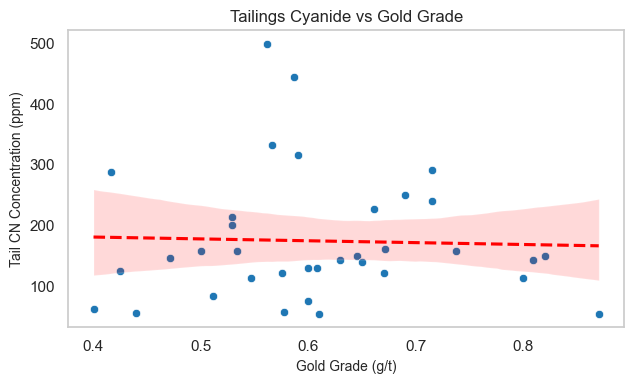

In [58]:
# Use df_2024 for this analysis (has Tail CN and Grade_Au)
# Clean and filter required fields
df_2024["NaCN_conc_tailing"] = pd.to_numeric(df_2024["NaCN_conc_tailing"], errors="coerce")
df_2024["Grade_Au"] = pd.to_numeric(df_2024["Grade_Au"], errors="coerce")

df_tail_grade = df_2024.dropna(subset=["NaCN_conc_tailing", "Grade_Au"])

# Plot Tail CN vs Gold Grade
plot_scatter_with_regression(
	data=df_tail_grade,
	x_col="Grade_Au",
	y_col="NaCN_conc_tailing",
	title="Tailings Cyanide vs Gold Grade",
	xlabel="Gold Grade (g/t)",
	ylabel="Tail CN Concentration (ppm)"
)


Tail CN vs Gold Grade
There is no strong trend — tailings CN remains between ~250–500 ppm across the full range of gold grades.

Even higher-grade ores (~0.6 g/t) do not appear to result in systematically lower tail CN (which would suggest more efficient use).

If anything, there may be a slight positive trend, implying that higher-grade ore could be associated with more residual CN — possibly due to overdosing to maximise recovery.

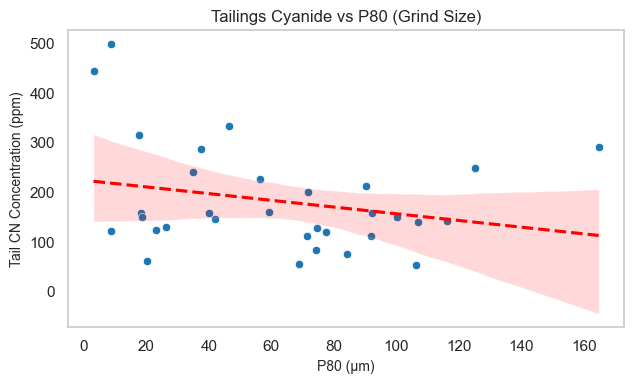

In [59]:
# Plot Tail CN vs P80 (to assess whether coarser grind correlates with CN inefficiency)
df_2024["Au_P80_µm"] = pd.to_numeric(df_2024["Au_P80_µm"], errors="coerce")
df_2024["NaCN_conc_tailing"] = pd.to_numeric(df_2024["NaCN_conc_tailing"], errors="coerce")

df_tail_p80 = df_2024.dropna(subset=["Au_P80_µm", "NaCN_conc_tailing"])

# Filter to realistic P80 values
df_tail_p80 = df_tail_p80[(df_tail_p80["Au_P80_µm"] > 0) & (df_tail_p80["Au_P80_µm"] < 200)]

# Plot
plot_scatter_with_regression(
	data=df_tail_p80,
	x_col="Au_P80_µm",
	y_col="NaCN_conc_tailing",
	title="Tailings Cyanide vs P80 (Grind Size)",
	xlabel="P80 (µm)",
	ylabel="Tail CN Concentration (ppm)"
)


#### Observations: Tail CN vs P80
* Tail CN values are again fairly consistent (~250–500 ppm) across the full P80 range (3–60 µm).
* There is no visible trend suggesting that coarser grinds result in higher tail CN (which would indicate poor liberation).
* Surprisingly, even samples with very fine grinds (P80 < 20 µm) still retain substantial CN in tails — suggesting excess dosing or non-liberation factors at play.

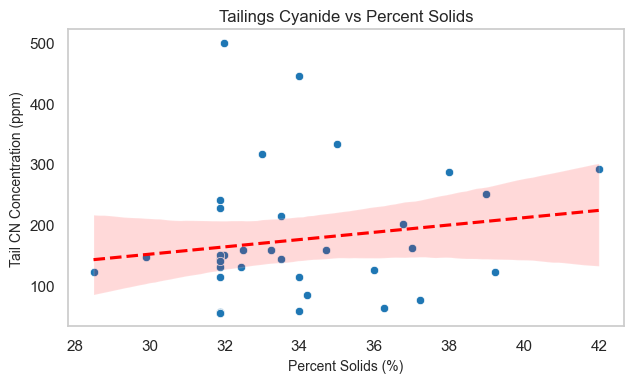

In [50]:
# Prepare for analysis of CN and DO vs Percent Solids
df_2024["PercentSolids"] = pd.to_numeric(df_2024["PercentSolids"], errors="coerce")
df_2024["NaCN_conc_tailing"] = pd.to_numeric(df_2024["NaCN_conc_tailing"], errors="coerce")

# Estimate average DO using the fields if any are available
do_cols_2024 = [col for col in df_2024.columns if "DO" in col and "ppm" in col]
do_cols_2024  # Check if any DO fields exist in 2024 dataset

# Filter for valid values
df_cn_solids = df_2024.dropna(subset=["PercentSolids", "NaCN_conc_tailing"])

# Plot Tail CN vs % Solids
plot_scatter_with_regression(
	data=df_cn_solids,
	x_col="PercentSolids",
	y_col="NaCN_conc_tailing",
	title="Tailings Cyanide vs Percent Solids",
	xlabel="Percent Solids (%)",
	ylabel="Tail CN Concentration (ppm)"
)



#### Tail CN vs % Solids
* Tail CN levels are broadly similar across the full 32–40% solids range.
* No strong trend is visible — though there may be a slight increase in tail CN at higher % solids, potentially indicating reduced mixing or CN diffusion limitations.
* However, the scatter is high and the trend is weak.

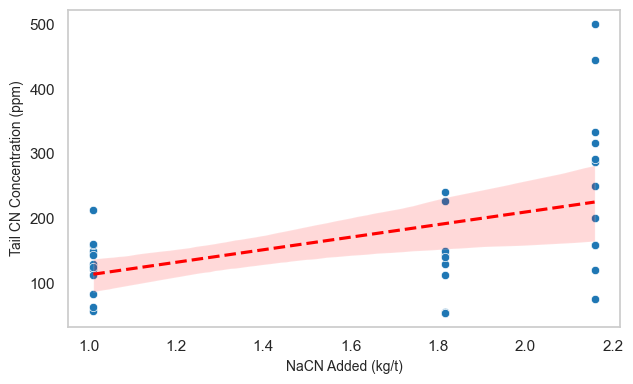

In [51]:
# Check if NaCN added is available in 2024 data
df_2024["NaCN_Added"] = pd.to_numeric(df_2024["NaCN_Added"], errors="coerce")

# Filter for valid rows
df_cn_added = df_2024.dropna(subset=["NaCN_Added", "NaCN_conc_tailing"])

# Plot NaCN Added vs CN in Tails
plot_scatter_with_regression(
	data=df_cn_added,
	x_col="NaCN_Added",
	y_col="NaCN_conc_tailing",
	title=None,
	xlabel="NaCN Added (kg/t)",
	ylabel="Tail CN Concentration (ppm)",
	color=colors[0],
	order=1
)


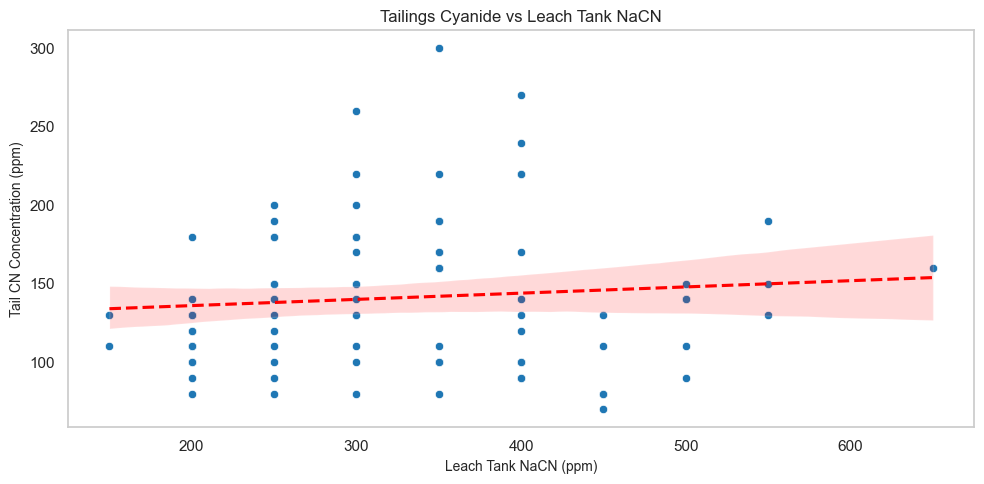

<Figure size 1200x600 with 0 Axes>

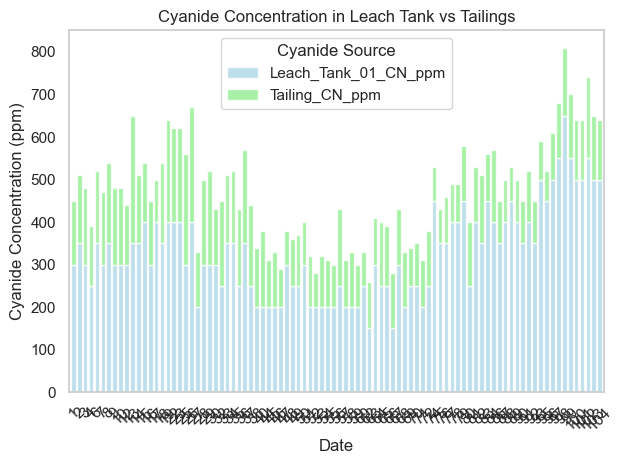

<Figure size 1200x600 with 0 Axes>

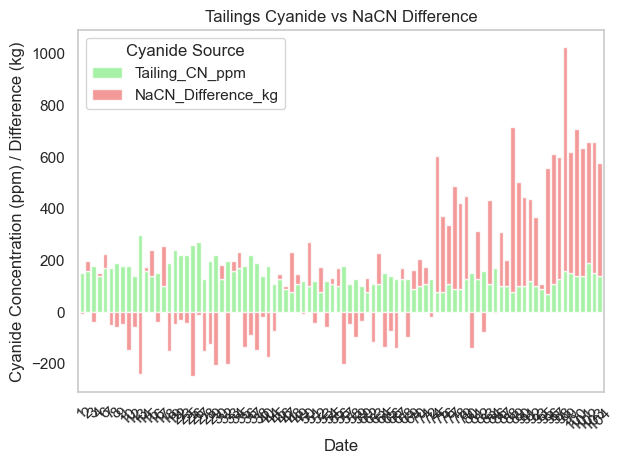

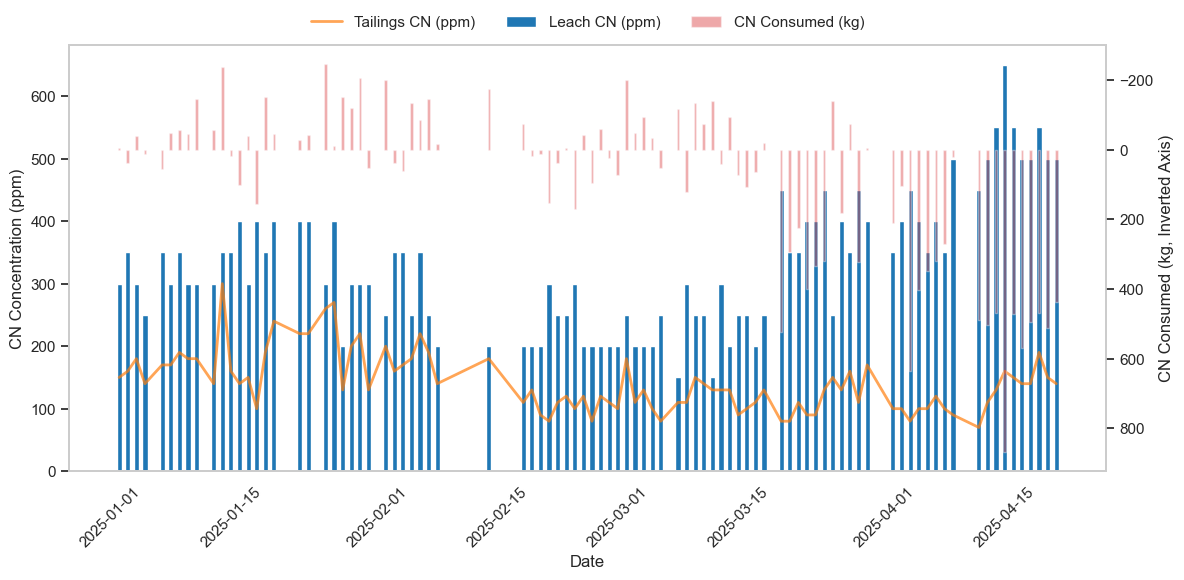

In [52]:
# Plot Leach_Tank_01_CN_ppm vs Tailing_CN_ppm
plot_scatter_with_regression(
	data=merged_2025,
	x_col="Leach_Tank_01_CN_ppm",
	y_col="Tailing_CN_ppm",
	title="Tailings Cyanide vs Leach Tank NaCN",
	xlabel="Leach Tank NaCN (ppm)",
	ylabel="Tail CN Concentration (ppm)",
	color=colors[0],
	order=1,
	figsize=(10, 5)
)

# Plot stacked bar chart of Leach_Tank_01_CN_ppm & Tailing_CN_ppm
plt.figure(figsize=(12, 6))
merged_2025[["Leach_Tank_01_CN_ppm", "Tailing_CN_ppm"]].plot(
	kind="bar",
	stacked=True, color=["lightblue", "lightgreen"], alpha=0.8, width=0.8
)
plt.title("Cyanide Concentration in Leach Tank vs Tailings")
plt.xlabel("Date")
plt.ylabel("Cyanide Concentration (ppm)")
plt.xticks(rotation=45)
plt.legend(title="Cyanide Source")
plt.tight_layout()
plt.grid(False)
plt.show()

# Plot stacked bar chart with Tailing_CN_ppm and NaCN_Difference
plt.figure(figsize=(12, 6))
merged_2025[["Tailing_CN_ppm", "NaCN_Difference_kg"]].plot(
	kind="bar",
	stacked=True, color=["lightgreen", "lightcoral"], alpha=0.8, width=0.8
)
plt.title("Tailings Cyanide vs NaCN Difference")
plt.xlabel("Date")
plt.ylabel("Cyanide Concentration (ppm) / Difference (kg)")
plt.xticks(rotation=45)
plt.legend(title="Cyanide Source")
plt.tight_layout()
plt.grid(False)
plt.show()

def plot_cyanide_balance(df, date_col="Date",
						 leach_col="Leach_Tank_01_CN_ppm",
						 tail_col="Tailing_CN_ppm",
						 diff_col="NaCN_Difference_kg",
						 figsize=(12, 6),
						 color_leach=colors[0],
						 color_tail=colors[1],
						 color_diff=colors[3]):
	# Parse date and prepare figure
	df[date_col] = pd.to_datetime(df[date_col])
	x = df[date_col]
	
	fig, ax1 = plt.subplots(figsize=figsize)

	# Bar plot for Leach CN on primary axis
	ax1.bar(x, df[leach_col], width=0.6, label='Leach CN (ppm)', color=color_leach)

	# Line plot for Tailings CN on primary axis
	ax1.plot(x, df[tail_col], label='Tailings CN (ppm)', color=color_tail, linewidth=2, alpha=0.7)
	
	ax1.set_xlabel("Date")
	ax1.set_ylabel("CN Concentration (ppm)")
	ax1.tick_params(axis='x', rotation=45)
	# ax1.set_title("Leach Input vs Tailings Residual vs NaCN Difference")

	# Secondary axis: NaCN Difference (bar plot, inverted)
	ax2 = ax1.twinx()
	ax2.bar(x, df[diff_col], width=0.3, label='CN Consumed (kg)', color=color_diff, alpha=0.4)
	ax2.set_ylabel("CN Consumed (kg, Inverted Axis)")
	ax2.invert_yaxis()  # Consumption appears downward

	# Legends (combine both axes)
	handles1, labels1 = ax1.get_legend_handles_labels()
	handles2, labels2 = ax2.get_legend_handles_labels()
	ax1.legend(
		handles1 + handles2,
		labels1 + labels2,
		loc='upper center',
		bbox_to_anchor=(0.5, 1.10),
		ncol=3,  # adjust based on number of items
		frameon=False
	)

	# Tidy up
	ax1.grid(False)
	ax2.grid(False)
	fig.tight_layout()
	plt.show()

plot_cyanide_balance(merged_2025)


#### 📊 Observations: NaCN Added vs Tail CN
* There is a positive trend: as NaCN dosage increases, tail CN concentrations also rise.
* This suggests a dose-response effect, but one where increased cyanide input may not be fully consumed.
* Several samples show tail CN > 400 ppm despite modest additions (~2.1 kg/t), suggesting possible inefficiency or saturation.

## Highlight Missing Fields / Follow-Ups
* Confirm inferred fields used
* List gaps or required additions for final model readiness

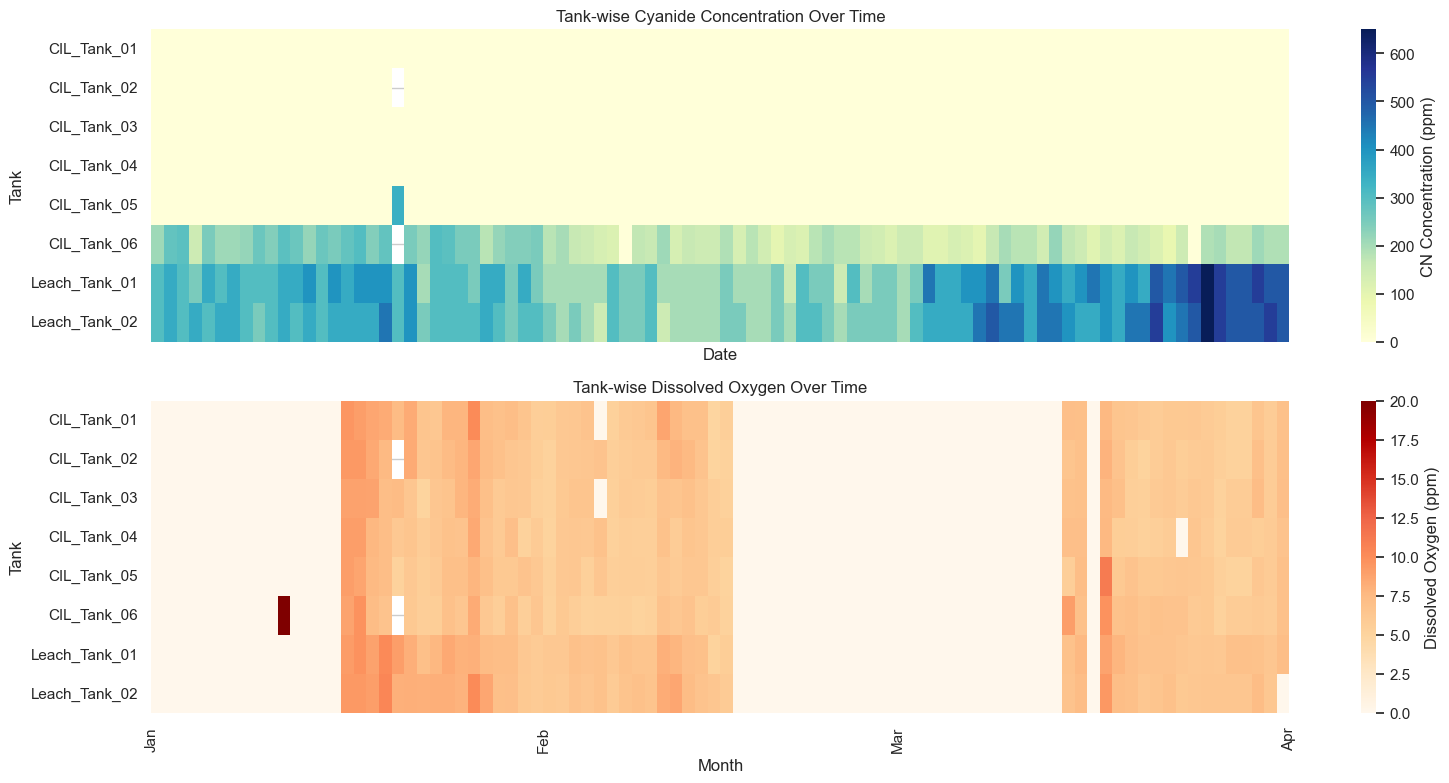

In [53]:
# Load the merged_2025 dataset
df = merged_2025.copy()

# Identify CN and DO columns for tanks
cn_cols = [col for col in df.columns if col.endswith('_CN_ppm') and "Tank" in col]
do_cols = [col for col in df.columns if col.endswith('_DO_ppm') and "Tank" in col]

# Convert any placeholder strings like '-' to NaN
df[cn_cols + do_cols] = df[cn_cols + do_cols].replace("-", pd.NA)
df[cn_cols + do_cols] = df[cn_cols + do_cols].apply(pd.to_numeric, errors='coerce')

# Melt CN and DO into long format
cn_long = df[["Date"] + cn_cols].melt(id_vars="Date", var_name="Tank", value_name="CN_ppm")
cn_long["Tank"] = cn_long["Tank"].str.replace("_CN_ppm", "", regex=False)

do_long = df[["Date"] + do_cols].melt(id_vars="Date", var_name="Tank", value_name="DO_ppm")
do_long["Tank"] = do_long["Tank"].str.replace("_DO_ppm", "", regex=False)

# Merge into one long dataframe
df_long = pd.merge(cn_long, do_long, on=["Date", "Tank"], how="outer")

# Convert Date to datetime
df_long["Date"] = pd.to_datetime(df_long["Date"], errors="coerce")
#Format Date for better plotting
df_long["Date"] = df_long["Date"].dt.strftime('%Y-%m-%d')

# Create pivot tables for heatmaps
cn_pivot = df_long.pivot(index="Date", columns="Tank", values="CN_ppm")
do_pivot = df_long.pivot(index="Date", columns="Tank", values="DO_ppm")

# Plot heatmaps
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

sns.heatmap(cn_pivot.T, ax=axes[0], cmap='YlGnBu', cbar_kws={'label': 'CN Concentration (ppm)'})
axes[0].set_title("Tank-wise Cyanide Concentration Over Time")
axes[0].set_ylabel("Tank")

sns.heatmap(do_pivot.T, ax=axes[1], cmap='OrRd', vmin=0, vmax=20, cbar_kws={'label': 'Dissolved Oxygen (ppm)'})
axes[1].set_title("Tank-wise Dissolved Oxygen Over Time")
axes[1].set_ylabel("Tank")

# Tidy up x-axis labels
for ax in axes:
	ax.xaxis.set_major_locator(mdates.MonthLocator())
	ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlabel("Month")
plt.tight_layout()
plt.show()


In [54]:
df_2024.columns.to_list()

['Date',
 'Shift',
 'Sample',
 'Throughput',
 'PercentSolids',
 'Grade_Au',
 'AU_tailing',
 'Grade_Ag',
 'Grade_Cu',
 'NaCN_Added',
 'NaCN_conc_tailing',
 'Weight_Retained_g_150_plus100mesh',
 'Weight_Retained_g_75_plus200mesh',
 'Weight_Retained_g_46_plus300mesh',
 'Weight_Retained_g_38_plus400mesh',
 'Weight_Retained_g_38_minus400mesh',
 'Weight_Retained_g_Total',
 'Weight_Retained_pct_150_plus100mesh',
 'Weight_Retained_pct_75_plus200mesh',
 'Weight_Retained_pct_46_plus300mesh',
 'Weight_Retained_pct_38_plus400mesh',
 'Weight_Retained_pct_38_minus400mesh',
 'Weight_Retained_pct_Total',
 'Cum_Weight_Passing_pct_150_plus100mesh',
 'Cum_Weight_Passing_pct_75_plus200mesh',
 'Cum_Weight_Passing_pct_46_plus300mesh',
 'Cum_Weight_Passing_pct_38_plus400mesh',
 'Cum_Weight_Passing_pct_38_minus400mesh',
 'pct_Passing_75µm',
 'P80_µm',
 'Au_Assay_150_plus100mesh',
 'Au_Assay_75_plus200mesh',
 'Au_Assay_46_plus300mesh',
 'Au_Assay_38_plus400mesh',
 'Au_Assay_38_minus400mesh',
 'pct_Dist_Retaine

In [55]:
merged_2025.columns.to_list()

['Date',
 'Time',
 'Date Time',
 'Pre_Leach_Density_pct_w_w',
 'Leach_Tank_01_Density_pct_w_w',
 'Leach_Tank_01_pH',
 'Leach_Tank_01_CN_ppm',
 'Leach_Tank_01_DO_ppm',
 'Leach_Tank_02_Density_pct_w_w',
 'Leach_Tank_02_pH',
 'Leach_Tank_02_CN_ppm',
 'Leach_Tank_02_DO_ppm',
 'CIL_Tank_01_Density_pct_w_w',
 'CIL_Tank_01_pH',
 'CIL_Tank_01_CN_ppm',
 'CIL_Tank_01_DO_ppm',
 'CIL_Tank_01_Carbon_gpl',
 'CIL_Tank_02_Density_pct_w_w',
 'CIL_Tank_02_pH',
 'CIL_Tank_02_CN_ppm',
 'CIL_Tank_02_DO_ppm',
 'CIL_Tank_02_Carbon_gpl',
 'CIL_Tank_03_Density_pct_w_w',
 'CIL_Tank_03_pH',
 'CIL_Tank_03_CN_ppm',
 'CIL_Tank_03_DO_ppm',
 'CIL_Tank_03_Carbon_gpl',
 'CIL_Tank_04_Density_pct_w_w',
 'CIL_Tank_04_pH',
 'CIL_Tank_04_CN_ppm',
 'CIL_Tank_04_DO_ppm',
 'CIL_Tank_04_Carbon_gpl',
 'CIL_Tank_05_Density_pct_w_w',
 'CIL_Tank_05_pH',
 'CIL_Tank_05_CN_ppm',
 'CIL_Tank_05_DO_ppm',
 'CIL_Tank_05_Carbon_gpl',
 'CIL_Tank_06_Density_pct_w_w',
 'CIL_Tank_06_pH',
 'CIL_Tank_06_CN_ppm',
 'CIL_Tank_06_DO_ppm',
 'CIL_Tank_

In [56]:
df_2024['Au_P80_µm'] = pd.to_numeric(df_2024['Au_P80_µm'], errors='coerce')

# Calculate a recovery using AU_tailings and AU feed
df_2024['Recovery_pct'] = ((df_2024['Grade_Au'] - df_2024['AU_tailing'])/ df_2024['Grade_Au']) * 100

It is


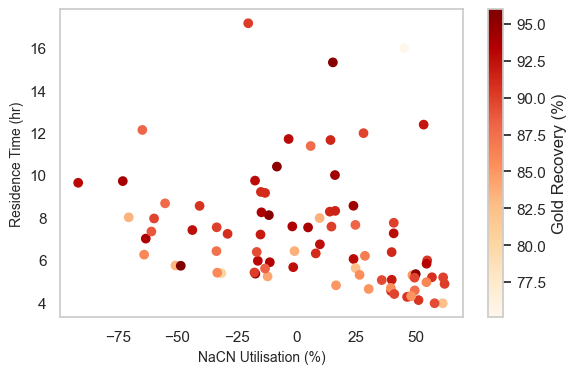

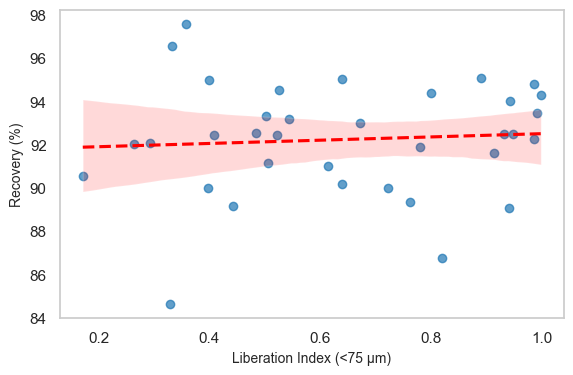

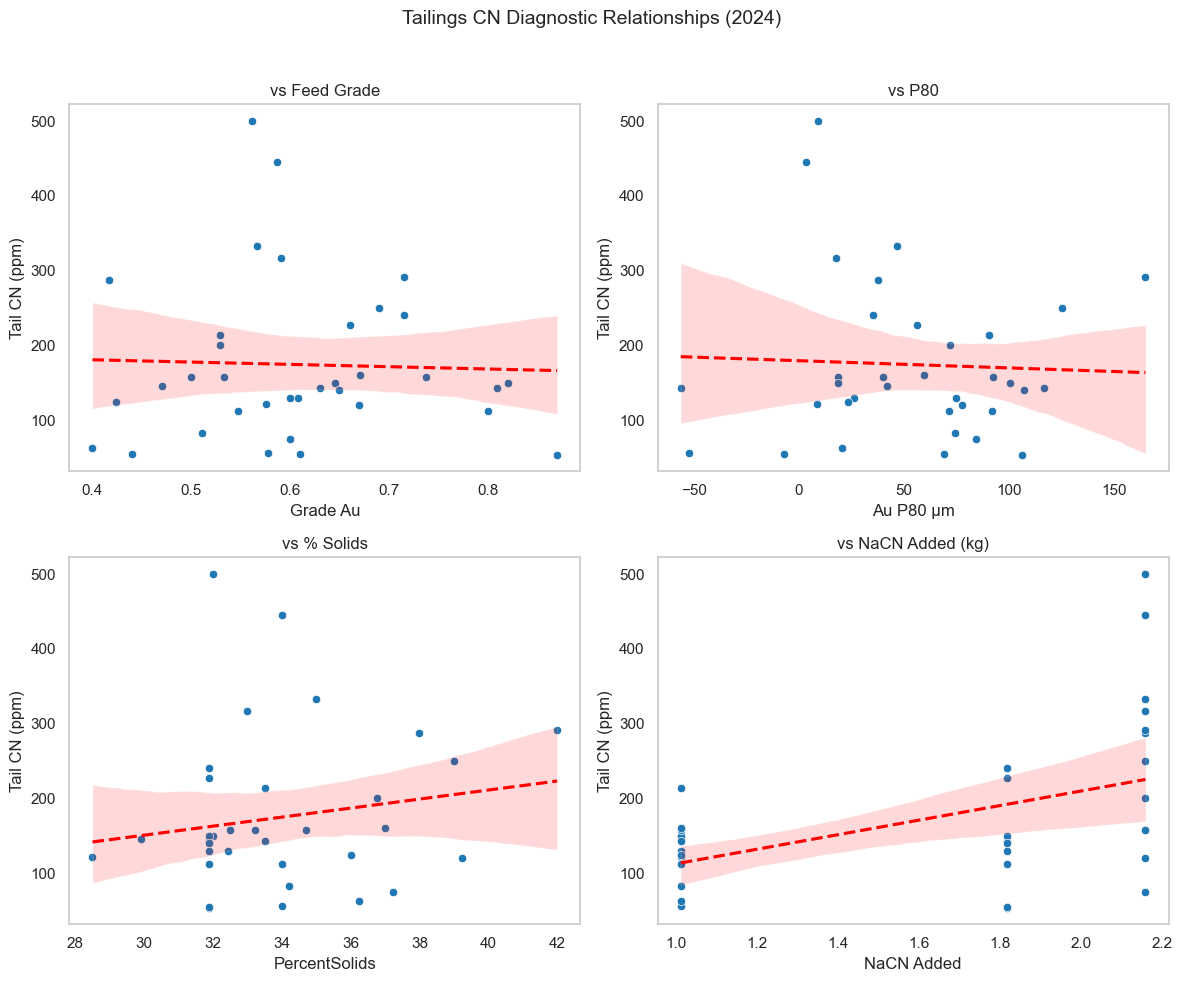

In [57]:
# Plotting for:
# - 7.7: Multivariate Diagnostic: DO, CN Utilisation, and RT vs Recovery
# - 7.9: Liberation Index vs Recovery (using 2024 dataset, assumed already loaded separately)
# - 7.10: Tail CN vs various features

# First, subset and clean necessary fields from merged_2025
required_fields = [
	'Date', 'Recovery_pct', 'Residence_Time_hr', 'NaCN_Utilisation_pct',
	'Leach_Tank_01_DO_ppm', 'Tail_Solution_Au_ppm', 'Tail_Solution_Cu_ppm',
	'Feed_Grade_Au_ppm', 'P80_um', 'Percent_Solids_pct', 'Tailing_CN_ppm', 'NaCN_Added_Est_kg'
]

# Calculate mean of P80_um if it exists in the dataset
if 'P80_µm' in df_2024.columns:
	print("It is")
	df_2024['P80_µm'] = pd.to_numeric(df_2024['P80_µm'], errors='coerce')
	merged_2025['P80_um'] = df_2024['P80_µm'].mean()
	 
# Add Percent_solids_pct to merged_df using constant value
merged_2025['Percent_Solids_pct'] = percent_solids_avg * 100  # Assuming a constant

df_subset = merged_2025[required_fields].copy()
df_subset['DO_ppm'] = df_subset['Leach_Tank_01_DO_ppm']  # alias for clarity
df_subset = df_subset.dropna(subset=['Recovery_pct', 'Residence_Time_hr', 'NaCN_Utilisation_pct', 'DO_ppm'])

# Filter Residence Time to a reasonable range (e.g. 0-20 hours)
df_subset = df_subset[(df_subset['Residence_Time_hr'] >= 0) & (df_subset['Residence_Time_hr'] <= 20)]

# Filter recovery to a reasonable range (e.g. 75-100%)
df_subset = df_subset[(df_subset['Recovery_pct'] >= 75) & (df_subset['Recovery_pct'] <= 100)]

# 7.7 Multivariate scatter plot: CN Utilisation vs RT, colored by Recovery
fig1 = plt.figure(figsize=(6.5, 4))
sc = plt.scatter(
	df_subset['NaCN_Utilisation_pct'],
	df_subset['Residence_Time_hr'],
	c=df_subset['Recovery_pct'],
	cmap='OrRd'
)
plt.colorbar(sc, label='Gold Recovery (%)')
plt.xlabel('NaCN Utilisation (%)', fontsize=10)
plt.ylabel('Residence Time (hr)', fontsize=10)
plt.grid(False)

df_subset = df_2024.copy()

# 7.9: Particle Size Liberation — mock liberation index vs recovery
# This assumes P80_um and a liberation function exists
if 'Au_P80_µm' in df_subset.columns:
	df_subset['Gold_Liberation_Index'] = 1 / (1 + (df_subset['Au_P80_µm'] / 75)**2)  # sigmoid approximation
	fig2 = plt.figure(figsize=(6.5, 4))
	plt.scatter(df_subset['Gold_Liberation_Index'], df_subset['Recovery_pct'], alpha=0.7, color=colors[0])
	# Add regression line
	sns.regplot(data=df_subset, x='Gold_Liberation_Index', y='Recovery_pct',
			 scatter=False, color='red', line_kws={"linestyle": "dashed"})
	plt.xlabel('Liberation Index (<75 µm)', fontsize=10)
	plt.ylabel('Recovery (%)', fontsize=10)
	plt.grid(False)

# 7.10: Diagnostics — Tail CN vs other parameters
fig3, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

sns.scatterplot(data=df_subset, x='Grade_Au', y='NaCN_conc_tailing', ax=axs[0])
sns.regplot(data=df_subset, x='Grade_Au', y='NaCN_conc_tailing',
			ax=axs[0], scatter=False, color='red', line_kws={"linestyle": "dashed"})
axs[0].set_title('vs Feed Grade')

if 'Au_P80_µm' in df_subset.columns:
	sns.scatterplot(data=df_subset, x='Au_P80_µm', y='NaCN_conc_tailing', ax=axs[1], color=colors[0])
	axs[1].set_title('vs P80')
	# Add regression line if needed
	sns.regplot(data=df_subset, x='Au_P80_µm', y='NaCN_conc_tailing',
			 ax=axs[1], scatter=False, color='red', line_kws={"linestyle": "dashed"})

sns.scatterplot(data=df_subset, x='PercentSolids', y='NaCN_conc_tailing', ax=axs[2], color=colors[0])
sns.regplot(data=df_subset, x='PercentSolids', y='NaCN_conc_tailing',
			ax=axs[2], scatter=False, color='red', line_kws={"linestyle": "dashed"})
axs[2].set_title('vs % Solids')

sns.scatterplot(data=df_subset, x='NaCN_Added', y='NaCN_conc_tailing', ax=axs[3], color=colors[0])
sns.regplot(data=df_subset, x='NaCN_Added', y='NaCN_conc_tailing',
			ax=axs[3], scatter=False, color='red', line_kws={"linestyle": "dashed"})
axs[3].set_title('vs NaCN Added (kg)')

for ax in axs:
	ax.set_xlabel(ax.get_xlabel().replace('_', ' '))
	ax.set_ylabel('Tail CN (ppm)')
	ax.grid(False)

plt.suptitle("Tailings CN Diagnostic Relationships (2024)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


In [98]:
merged_2025.to_csv("merged_2025.csv", index=False)
df_2024.to_csv("df_2024.csv", index=False)
df_2025.to_csv("df_2025.csv", index=False)

# MODEL BUILDING